# Subgenre annotations (pre-1800)

Sonnet's `subgenre` annotation task (892 pre-1800 texts) tags each with:

- **is_fiction**: bool — does this text count as fiction at all? (caught 139 non-fiction, 15.6%)
- **non_fiction_type**: type tag for the non-fiction texts
- **subgenres**: list of subgenre tags (38 distinct), e.g. `amatory_fiction`, `sentimental`, `domestic_fiction`, `gothic`, `picaresque`, etc.

Companion to `16-plot-genre.ipynb`. Two main analyses:
1. Surface the non-fiction set so we can decide later whether to filter from §15's social-network analysis.
2. Track the rise-of-the-novel transition in subgenre terms (`amatory → sentimental → domestic`).

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotnine as p9
from collections import Counter
from lltk.annotate import iter_task_results

plt.rcParams['figure.dpi'] = 110

DROPBOX_FIGS = os.path.expanduser('~/Dropbox/Prof/Books/AbsLitHist/book/figures')

df_net = pd.read_csv('../data/social_networks/social_network_analysis.csv')

rows = []
for _id, d in iter_task_results('subgenre'):
    rows.append({
        'source': _id,
        'is_fiction': d.get('is_fiction'),
        'non_fiction_type': d.get('non_fiction_type'),
        'subgenres': d.get('subgenres') or [],
    })
sg = pd.DataFrame(rows)

df = sg.merge(df_net[['source', 'year', 'author', 'title', 'form',
                      'n_chars', 'realistic_pct', 'classical_pct', 'type_pct',
                      'comp_density', 'comp_clustering', 'char_desc_conc']],
              on='source', how='left')
print(f'subgenre rows: {len(sg):,}')
print(f'  with year:      {df["year"].notna().sum():,}')
print(f'  is_fiction True/False: {df["is_fiction"].sum()} / {(df["is_fiction"]==False).sum()}')
df.head(3)

/Users/rj416/github/abslithists/abstraction/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


subgenre rows: 1,432
  with year:      1,391
  is_fiction True/False: 1291 / 141


,source,is_fiction,non_fiction_type,subgenres,year,author,title,form,n_chars,realistic_pct,classical_pct,type_pct,comp_density,comp_clustering,char_desc_conc
0,_chadwyck/Early_English_Prose_Fiction/ee01010.01,True,None,"[amatory_fiction, scandalous_memoir, secret_hi...",1699.0,Anon.,The Adventures of Covent&hyphen;Garden (1699),romance,6.0,0.0,33.3,16.7,0.2667,0.2778,-0.467551
1,_chadwyck/Early_English_Prose_Fiction/ee01010.02,True,None,"[frame_tale, amatory_fiction, domestic_fiction...",1696.0,Anon.,Alcander and Philocrates (1696),romance,32.0,3.1,15.6,46.9,0.0474,0.2109,-0.524978
2,_chadwyck/Early_English_Prose_Fiction/ee01010.03,True,None,"[pseudo_memoir, scandalous_memoir, historical_...",1663.0,Anon.,The Case of Madam Mary Carlton (1663),?,26.0,73.1,0.0,11.5,0.0369,0.0201,-0.195659


## 1. The non-fiction filter

What did Sonnet flag as non-fiction? Distribution by type, year, and corpus.

In [2]:
nonfic = df[df['is_fiction'] == False].copy()
print(f'{len(nonfic):,} non-fiction texts ({len(nonfic)/len(df)*100:.1f}% of subgenre-tagged)')
print()
print('=== non_fiction_type distribution ===')
print(nonfic['non_fiction_type'].value_counts(dropna=False).to_string())
print()

nonfic['decade'] = (nonfic['year'] // 10 * 10).astype('Int64')
print('=== non-fiction by decade (counts) ===')
print(nonfic.groupby('decade').size().to_string())
print()

# Sample some non-fiction titles
print('=== 25 non-fiction examples (titles) ===')
samp = nonfic[['year', 'author', 'title', 'non_fiction_type']].sort_values('year').head(25)
print(samp.to_string(index=False))

141 non-fiction texts (9.8% of subgenre-tagged)

=== non_fiction_type distribution ===
non_fiction_type
treatise      29
poetry        28
essay         22
history       19
biography     10
reference      9
letters        7
legal          6
sermon         5
drama          2
None           2
almanac        1
periodical     1

=== non-fiction by decade (counts) ===
decade
1480     1
1490     1
1500     1
1530     3
1560     2
1570     5
1580     7
1590     9
1600    19
1610     6
1620     6
1630     7
1640     4
1650     1
1660     1
1670     3
1680     6
1690     4
1700     3
1710     1
1720     2
1740     1
1750     2
1760     2
1780     1
1790     4
1930     1
1960     1

=== 25 non-fiction examples (titles) ===
  year                author                                              title non_fiction_type
1484.0        La Tour Landry [Here begynneth the booke which the knyght of the          treatise
1496.0               Joannes           [The lyfe of the thre kynges of Coleyne]     

### Plot: non-fiction share over time

Saved to /Users/rj416/Dropbox/Prof/Books/AbsLitHist/book/figures/subgenre_nonfiction_share_25y.png


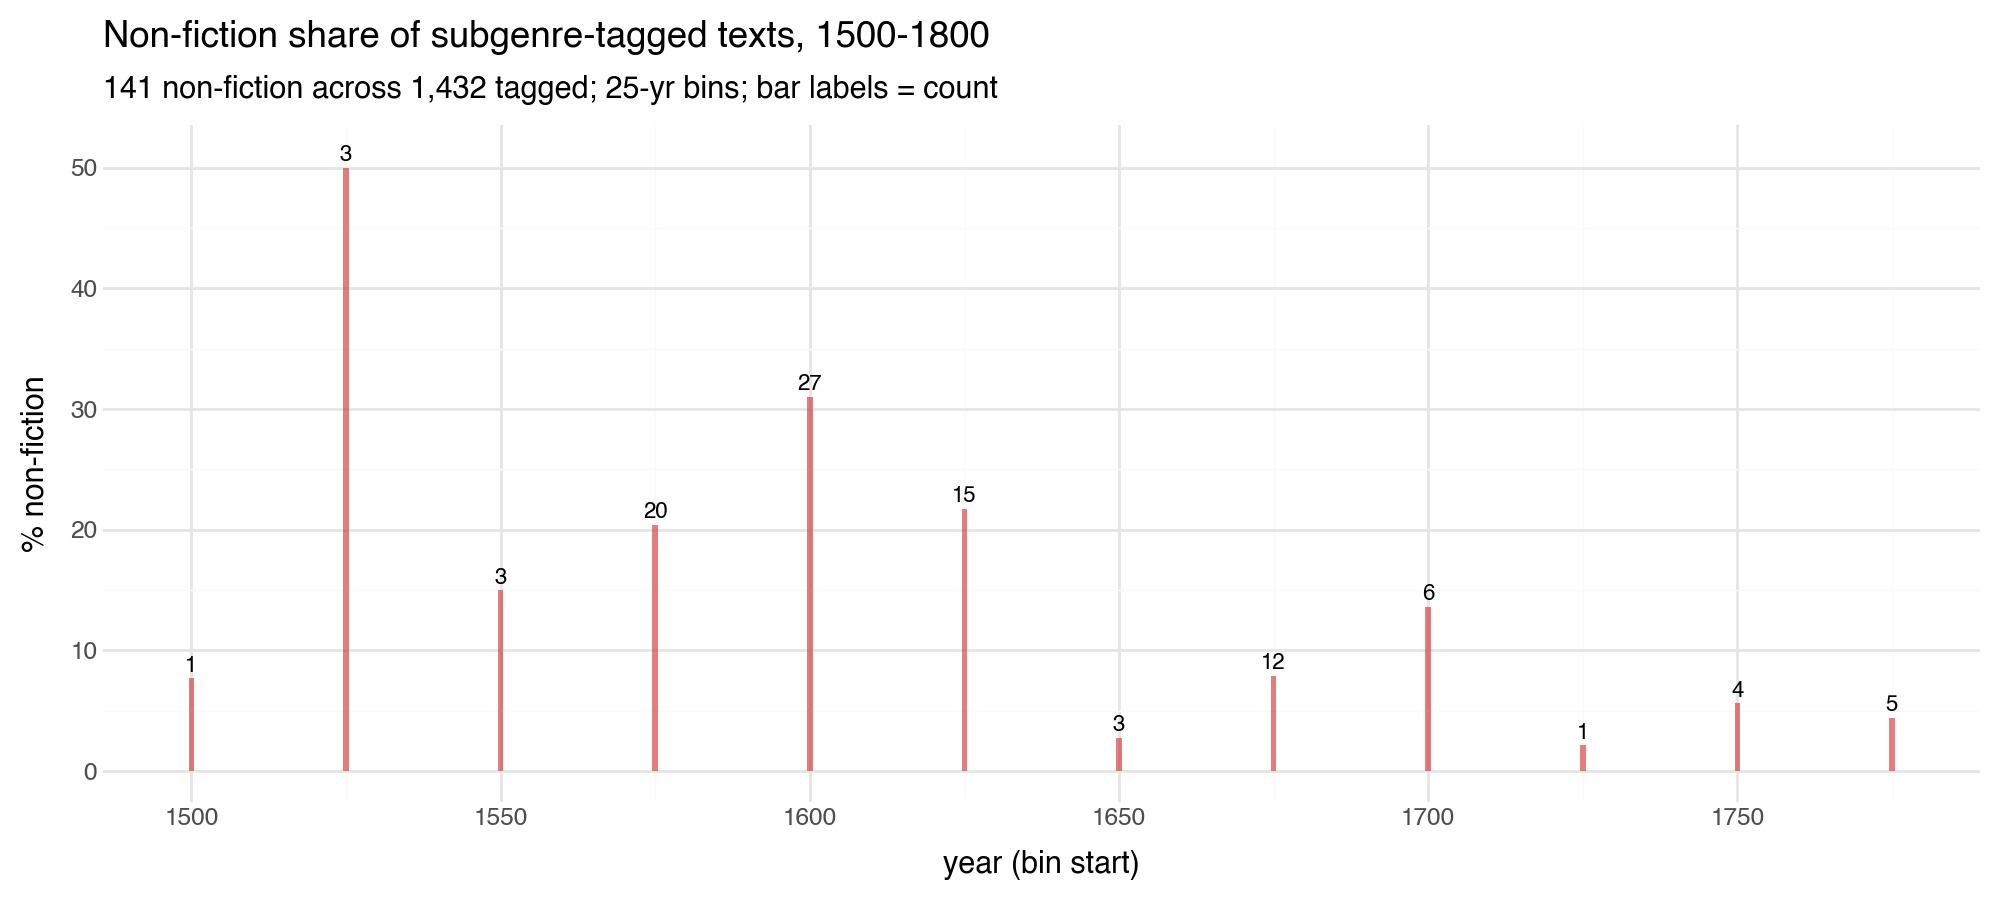

In [3]:
dia = df[(df['year'] >= 1500) & (df['year'] < 1800)].copy()
dia['bin'] = (dia['year'] // 25 * 25).astype(int)
nf_by_bin = (dia.groupby('bin')
             .agg(total=('source', 'count'),
                  nonfic=('is_fiction', lambda s: (s == False).sum()))
             .reset_index())
nf_by_bin['pct'] = nf_by_bin['nonfic'] / nf_by_bin['total'] * 100

p_nf = (p9.ggplot(nf_by_bin, p9.aes(x='bin', y='pct'))
        + p9.geom_col(fill='#d62728', alpha=0.6)
        + p9.geom_text(p9.aes(label='nonfic'), nudge_y=1, size=8)
        + p9.scale_x_continuous(breaks=range(1500, 1801, 50))
        + p9.labs(
            title='Non-fiction share of subgenre-tagged texts, 1500-1800',
            subtitle=f'{(df["is_fiction"]==False).sum()} non-fiction across {len(df):,} tagged; 25-yr bins; bar labels = count',
            x='year (bin start)', y='% non-fiction',
        )
        + p9.theme_minimal()
        + p9.theme(figure_size=(10, 4.5)))

out = os.path.join(DROPBOX_FIGS, 'subgenre_nonfiction_share_25y.png')
p_nf.save(out, dpi=300, verbose=False)
print(f'Saved to {out}')
p_nf

**Decision deferred** — these 139 texts are visible above but NOT filtered from any other notebook. Decide later whether to propagate `is_fiction == True` as a global filter or treat case-by-case.

## 2. Subgenre vocabulary

Each text can have multiple subgenre tags. Total tags and frequency.

In [4]:
# Explode the list-valued subgenres
fic = df[df['is_fiction'] == True].copy()
sg_counter = Counter()
for tags in fic['subgenres']:
    for t in tags:
        sg_counter[t] += 1
print(f'{len(sg_counter)} distinct subgenre tags across {len(fic):,} fiction texts')
print()
print('Counts:')
for tag, n in sg_counter.most_common():
    print(f'  {n:5}  {tag}')

80 distinct subgenre tags across 1,291 fiction texts

Counts:
    443  domestic_fiction
    388  sentimental
    361  historical_fiction
    239  bildungsroman
    219  frame_tale
    177  amatory_fiction
    169  heroic_romance
    140  picaresque
    135  regional_novel
    133  pseudo_memoir
    130  allegory
    124  novel_of_manners
    122  gothic
    118  adventure
    100  menippean_satire
     98  philosophical_tale
     91  satire
     90  epistolary
     85  travel_narrative
     79  conduct_fiction
     63  rogue_fiction
     63  condition_of_england
     63  modernist
     55  sensation_novel
     54  scandalous_memoir
     50  psychological_thriller
     49  postmodern
     47  pastoral
     46  naturalism
     45  romance_novel
     42  existentialist
     38  science_fiction
     37  secret_history
     31  war_novel
     29  detective_fiction
     27  newgate_narrative
     27  imaginary_voyage
     27  postcolonial_novel
     26  magical_realism
     25  roman_a_clef


## 3. Subgenre composition over time (top-12)

For the 12 most-common subgenres, plot per-bin share of fiction texts that carry the tag (multi-label, so shares can sum to >100%).

Saved to /Users/rj416/Dropbox/Prof/Books/AbsLitHist/book/figures/subgenre_top12_25y.png


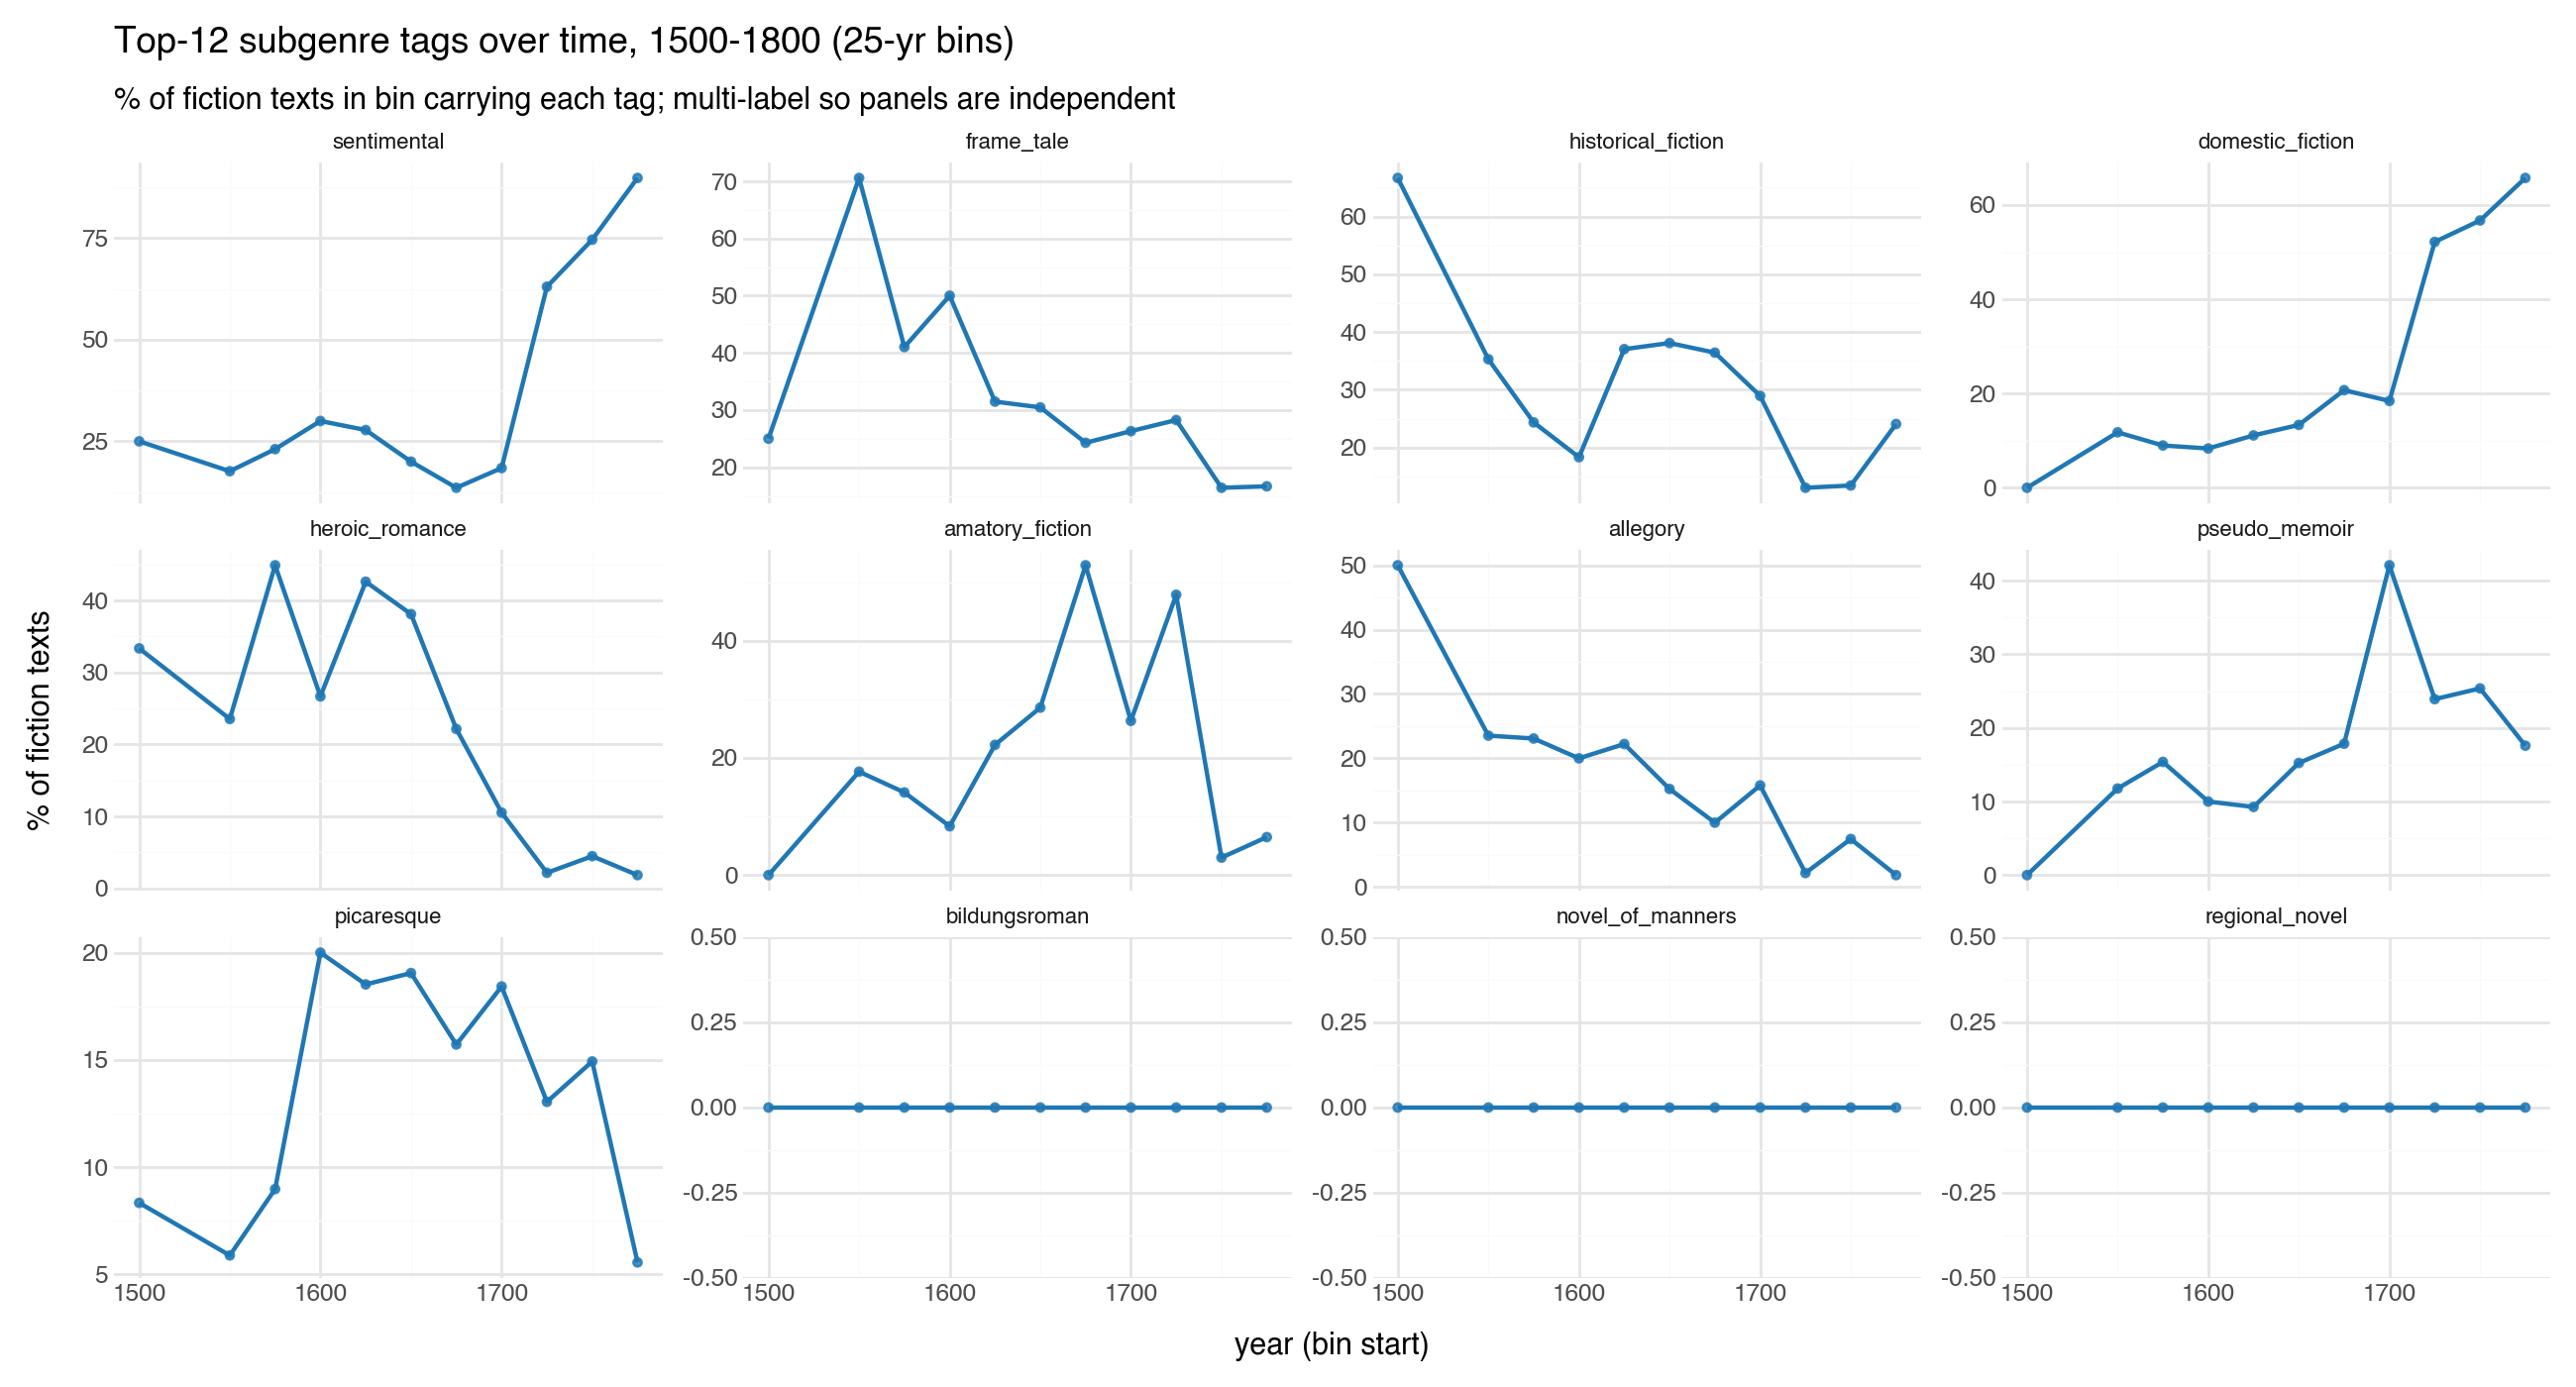

In [5]:
TOP_K = 12
MIN_N = 8
top_tags = [t for t, _ in sg_counter.most_common(TOP_K)]

dia = fic[(fic['year'] >= 1500) & (fic['year'] < 1800)].copy()
dia['bin'] = (dia['year'] // 25 * 25).astype(int)

long_rows = []
for tag in top_tags:
    has_tag = dia['subgenres'].apply(lambda L: tag in L)
    grp = dia.assign(has_tag=has_tag).groupby('bin').agg(
        n=('has_tag', 'sum'),
        total=('has_tag', 'count'),
    ).reset_index()
    grp = grp[grp['total'] >= MIN_N].copy()
    grp['pct'] = grp['n'] / grp['total'] * 100
    grp['subgenre'] = tag
    long_rows.append(grp)
sg_long = pd.concat(long_rows, ignore_index=True)

# Order facets by overall mean pct
order = (sg_long.groupby('subgenre')['pct'].mean()
         .sort_values(ascending=False).index.tolist())
sg_long['subgenre'] = pd.Categorical(sg_long['subgenre'], categories=order, ordered=True)

p_sg = (p9.ggplot(sg_long, p9.aes(x='bin', y='pct'))
        + p9.geom_line(color='#1f77b4', size=0.9)
        + p9.geom_point(color='#1f77b4', size=1.2, alpha=0.8)
        + p9.facet_wrap('~ subgenre', ncol=4, scales='free_y')
        + p9.scale_x_continuous(breaks=range(1500, 1801, 100))
        + p9.labs(
            title=f'Top-{TOP_K} subgenre tags over time, 1500-1800 (25-yr bins)',
            subtitle=f'% of fiction texts in bin carrying each tag; multi-label so panels are independent',
            x='year (bin start)', y='% of fiction texts',
        )
        + p9.theme_minimal()
        + p9.theme(figure_size=(13, 7),
                   strip_text=p9.element_text(size=8)))

out = os.path.join(DROPBOX_FIGS, 'subgenre_top12_25y.png')
p_sg.save(out, dpi=300, verbose=False)
print(f'Saved to {out}')
p_sg

Saved to /Users/rj416/Dropbox/Prof/Books/AbsLitHist/book/figures/subgenre_top12_25y_overlay.png


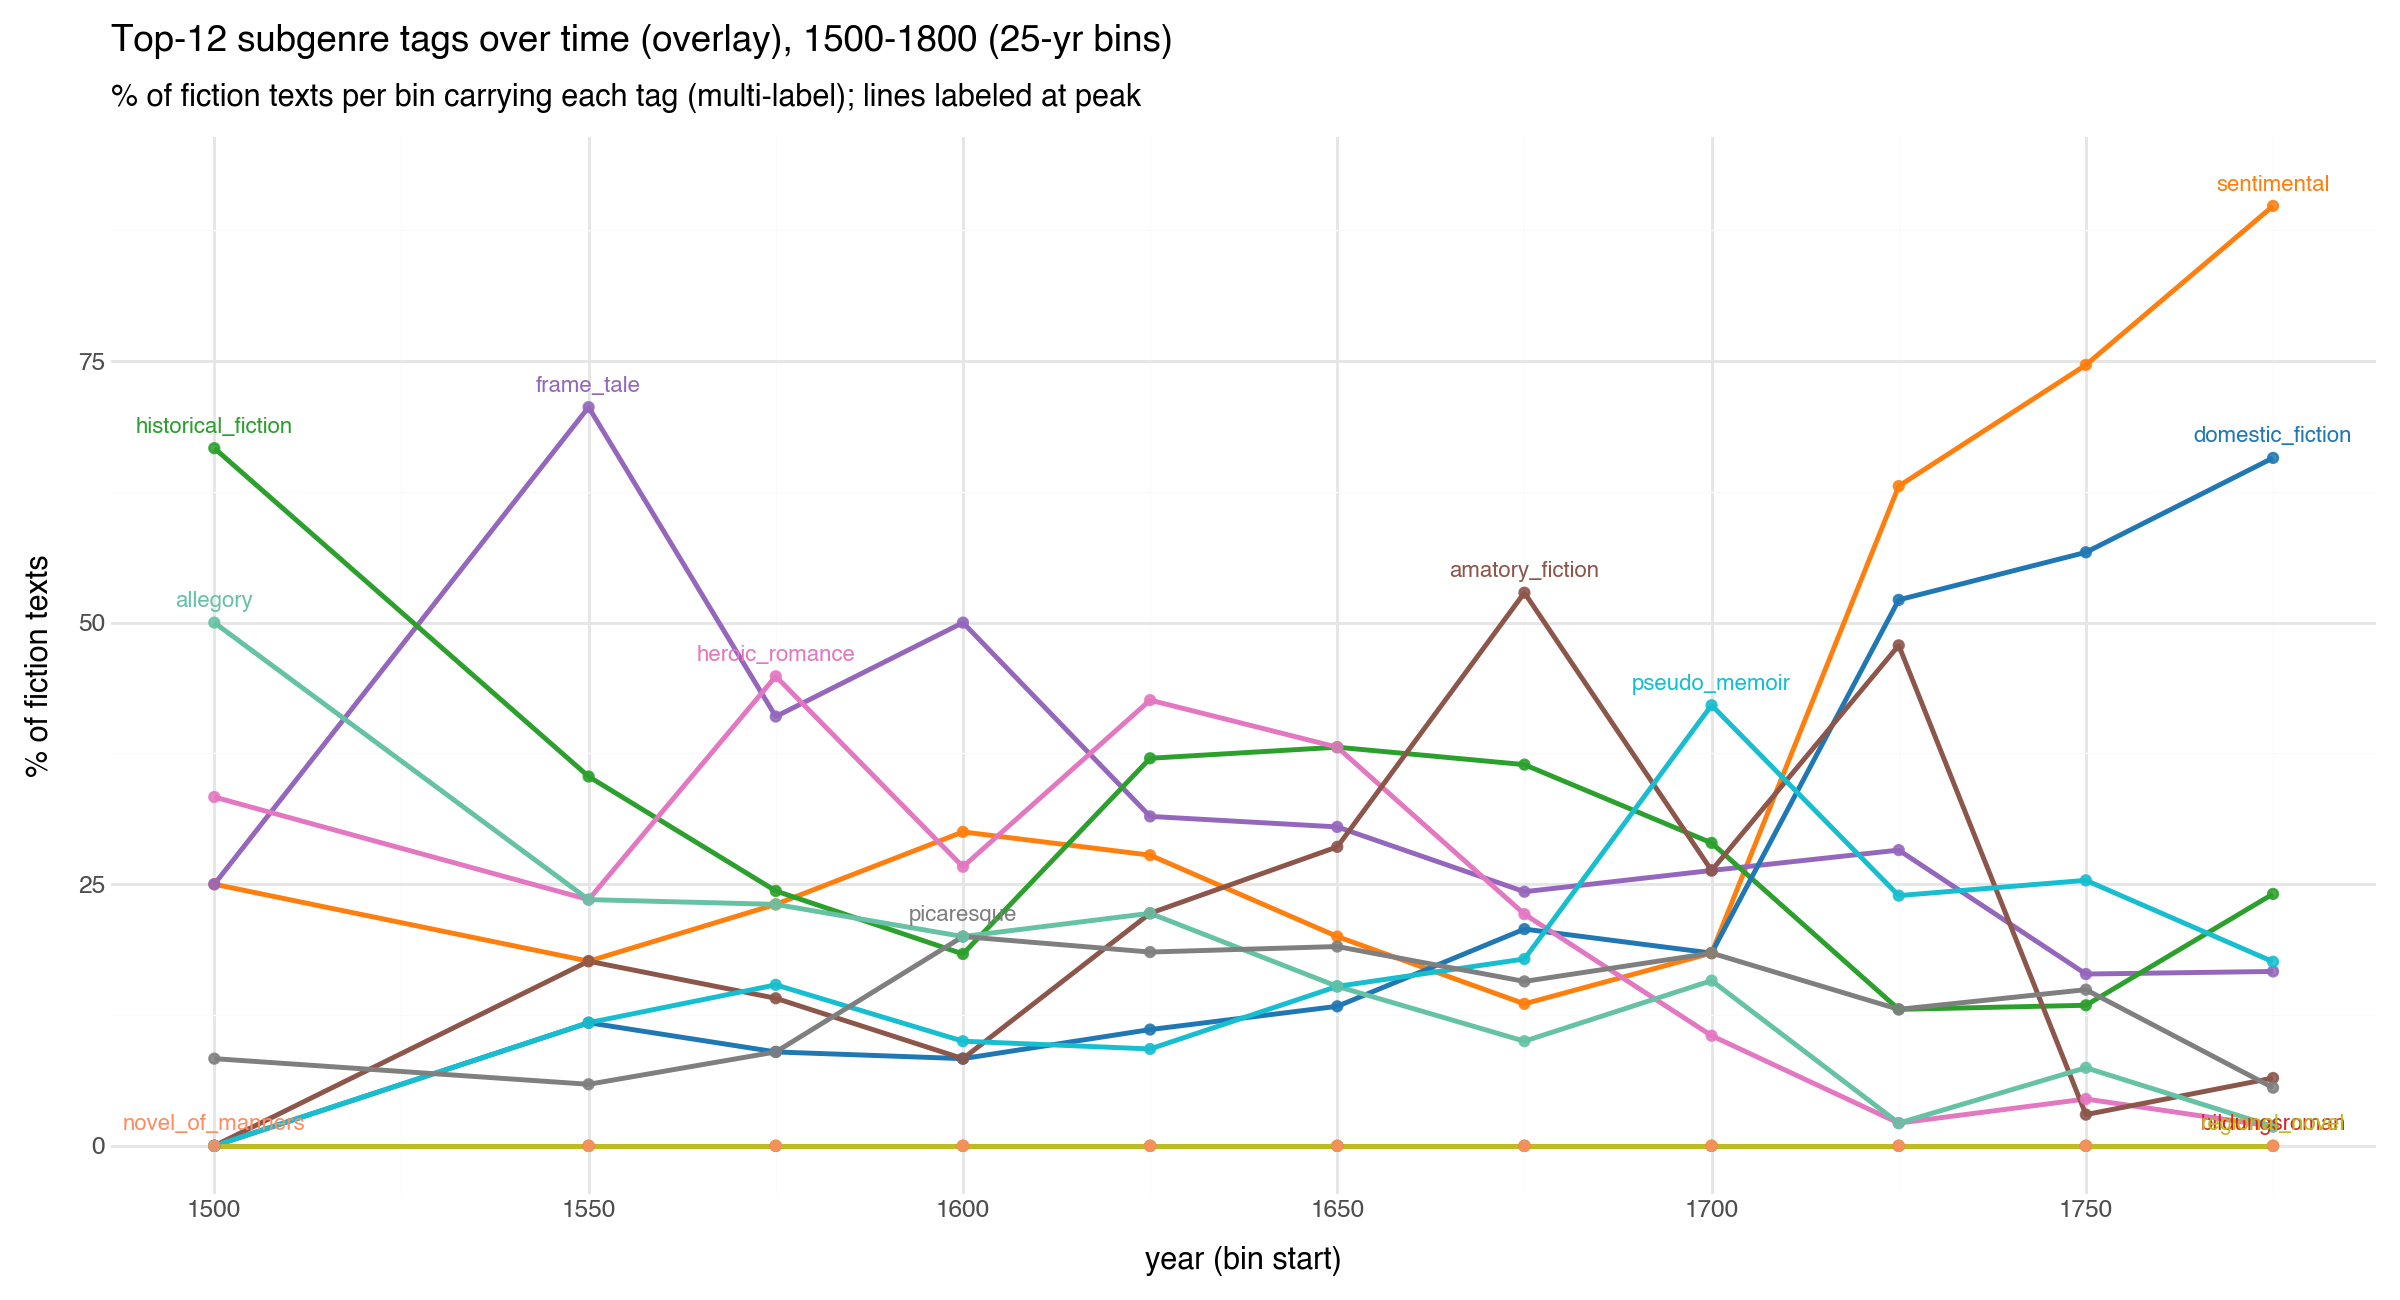

In [6]:
import matplotlib.colors as mcolors
import matplotlib.cm as mcm

# Single-axis line plot, one color per subgenre, label at peak.
tab10_hex = [mcolors.to_hex(c) for c in mcm.tab10.colors]
set2_hex = [mcolors.to_hex(c) for c in mcm.Set2.colors]
palette12 = tab10_hex + set2_hex[:2]
sg_palette = dict(zip(top_tags, palette12))

peak_rows_sg = (sg_long.sort_values('pct', ascending=False)
                .groupby('subgenre', as_index=False, observed=True)
                .first())

p_sg_overlay = (p9.ggplot(sg_long, p9.aes(x='bin', y='pct', color='subgenre'))
                + p9.geom_line(size=1.0)
                + p9.geom_point(size=1.5, alpha=0.85)
                + p9.geom_text(p9.aes(label='subgenre'),
                               data=peak_rows_sg,
                               nudge_y=2.0, size=8, fontweight='bold',
                               show_legend=False)
                + p9.scale_color_manual(values=sg_palette, breaks=top_tags)
                + p9.scale_x_continuous(breaks=range(1500, 1801, 50))
                + p9.labs(
                    title=f'Top-{TOP_K} subgenre tags over time (overlay), 1500-1800 (25-yr bins)',
                    subtitle='% of fiction texts per bin carrying each tag (multi-label); lines labeled at peak',
                    x='year (bin start)', y='% of fiction texts',
                    color='',
                )
                + p9.theme_minimal()
                + p9.theme(figure_size=(12, 6.5),
                           legend_position='none'))

out = os.path.join(DROPBOX_FIGS, 'subgenre_top12_25y_overlay.png')
p_sg_overlay.save(out, dpi=300, verbose=False)
print(f'Saved to {out}')
p_sg_overlay

## 4. The amatory → sentimental → domestic transition

lltm-claude's headline finding: amatory_fiction surges 1650-99, sentimental dominates 1750-99 (80% of texts), domestic_fiction rises 0 → 109 in the same period. Plot all three on one axis.

Saved to /Users/rj416/Dropbox/Prof/Books/AbsLitHist/book/figures/subgenre_amatory_sentimental_domestic_25y.png


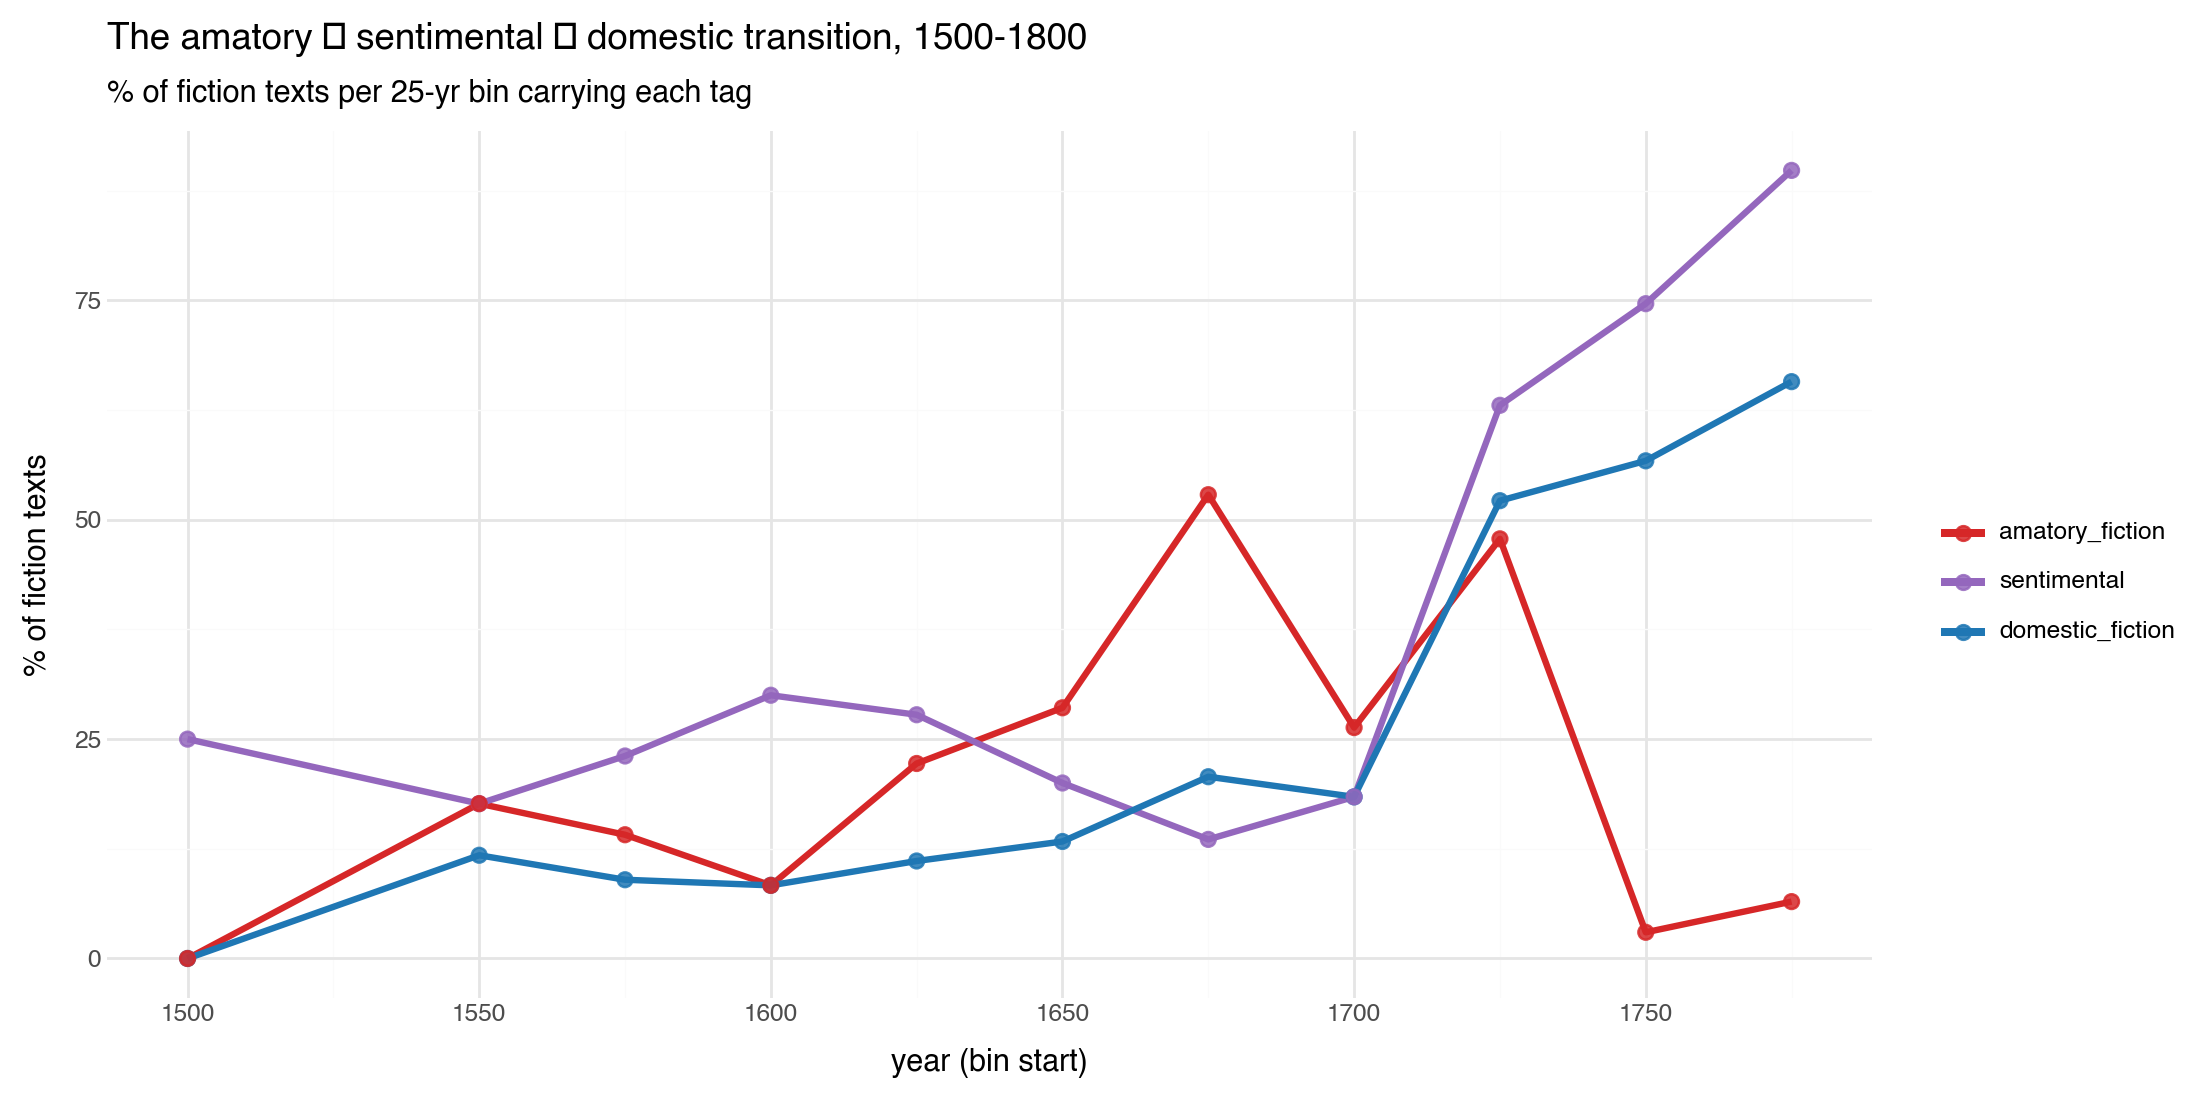

In [7]:
focus = ['amatory_fiction', 'sentimental', 'domestic_fiction']
focus_long = sg_long[sg_long['subgenre'].isin(focus)].copy()
focus_long['subgenre'] = pd.Categorical(focus_long['subgenre'], categories=focus, ordered=True)

p_trans = (p9.ggplot(focus_long, p9.aes(x='bin', y='pct', color='subgenre'))
           + p9.geom_line(size=1.3)
           + p9.geom_point(size=2.5, alpha=0.85)
           + p9.scale_color_manual(values={
               'amatory_fiction':  '#d62728',  # red (older)
               'sentimental':      '#9467bd',  # purple (transition)
               'domestic_fiction': '#1f77b4',  # blue (newer)
           })
           + p9.scale_x_continuous(breaks=range(1500, 1801, 50))
           + p9.labs(
               title='The amatory → sentimental → domestic transition, 1500-1800',
               subtitle=f'% of fiction texts per 25-yr bin carrying each tag',
               x='year (bin start)', y='% of fiction texts',
               color='',
           )
           + p9.theme_minimal()
           + p9.theme(figure_size=(11, 5.5)))

out = os.path.join(DROPBOX_FIGS, 'subgenre_amatory_sentimental_domestic_25y.png')
p_trans.save(out, dpi=300, verbose=False)
print(f'Saved to {out}')
p_trans

## 5. Abstractness — subgenre vs. century, decomposition

Whole-text abstractness from `abstraction.scores_en` (negated `Abs-Conc.Median.median`, + = abstract). Three views:

1. **2D mean table** — abstractness for each (subgenre × 25-yr bin), to see joint structure.
2. **Variance decomposition** — fit `abs ~ year`, `abs ~ subgenres`, `abs ~ year + subgenres`. Compare R²s; the difference attributes the explanatory work between the two.
3. **Per-subgenre coefficients controlling for year** — which subgenres still have a significant effect on abstractness once the long-run time trend is removed.

Multi-label note: each text can carry several subgenre tags, so dummies aren't mutually exclusive. Coefficients should be read as "marginal effect of carrying this tag, controlling for all others".

In [8]:
import clickhouse_connect
ch = clickhouse_connect.get_client(host='localhost', port=8123,
                                   username='lltk', password='lltk')
ids = fic['source'].tolist()
sc = ch.query_df(
    "SELECT _id, `Abs-Conc.Median.median` AS raw "
    "FROM abstraction.scores_en WHERE _id IN %(ids)s",
    parameters={'ids': ids},
).drop_duplicates('_id')
sc['abs_score'] = -sc['raw']
ch.close()

work = fic.merge(sc[['_id', 'abs_score']], left_on='source', right_on='_id', how='inner')
work = work[work['year'].notna() & work['abs_score'].notna()].copy()
work['bin'] = (work['year'] // 25 * 25).astype(int)
print(f'{len(work):,} fiction texts with year + abstractness + subgenres')

# Long-format for table
rows = []
for _, r in work.iterrows():
    for tag in r['subgenres']:
        rows.append({'tag': tag, 'bin': r['bin'], 'abs': r['abs_score']})
exploded = pd.DataFrame(rows)

top_for_table = [t for t, _ in sg_counter.most_common(12)]
table = (exploded[exploded['tag'].isin(top_for_table)]
         .groupby(['tag', 'bin'])['abs'].mean()
         .unstack('bin').round(2)
         .loc[top_for_table])
print('\nMean abstractness by subgenre x 25-yr bin:')
print(table.to_string())

1,287 fiction texts with year + abstractness + subgenres

Mean abstractness by subgenre x 25-yr bin:
bin                 1475  1500  1525  1550  1575  1600  1625  1650  1675  1700  1725  1750  1775  1800  1825  1850  1875  1900  1925  1950  1975  2000
tag                                                                                                                                                   
domestic_fiction     NaN   NaN   NaN  0.64  0.40  0.43  0.47  0.50  0.53  0.50  0.62  0.63  0.59  0.55  0.36  0.27  0.27  0.13 -0.10  0.01 -0.14 -0.10
sentimental         0.14  0.08  0.32  0.50  0.43  0.41  0.48  0.55  0.51  0.45  0.59  0.58  0.56  0.56  0.32  0.13  0.16 -0.02 -0.06 -0.09 -0.16 -0.32
historical_fiction  0.18  0.08   NaN  0.36  0.24  0.40  0.43  0.57  0.53  0.41  0.52  0.55  0.55  0.43  0.35  0.18  0.13  0.11 -0.05  0.03 -0.12  0.04
bildungsroman        NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN  0.56  0.36  0.21  0.15  0.08 -0.03 -0.05 -0.14

In [9]:
# Variance decomposition. Restrict to subgenres with n >= 30 to avoid noisy
# dummies. Center year so the intercept is meaningful at mid-period.
import numpy as np
from sklearn.linear_model import LinearRegression

MIN_N_DUMMY = 30
elig_tags = [t for t, n in sg_counter.most_common() if n >= MIN_N_DUMMY]
print(f'Using {len(elig_tags)} subgenre dummies (each with n >= {MIN_N_DUMMY})')

# Build feature matrices
X_year = (work[['year']].values.astype(float) - work['year'].mean())
X_sg = np.array([[1.0 if t in tags else 0.0 for t in elig_tags]
                 for tags in work['subgenres']])
y = work['abs_score'].values
n = len(y)

def r2(X):
    return LinearRegression().fit(X, y).score(X, y)

r2_year = r2(X_year)
r2_sg = r2(X_sg)
r2_both = r2(np.hstack([X_year, X_sg]))

# Adjusted R^2 to penalize the wide subgenre model
def adj(r2_val, k):
    return 1 - (1 - r2_val) * (n - 1) / (n - k - 1)

print(f'\n--- Variance decomposition (n = {n}) ---')
print(f'  R^2  year only       = {r2_year:.4f}   adj = {adj(r2_year, 1):.4f}   (1 df)')
print(f'  R^2  subgenres only  = {r2_sg:.4f}   adj = {adj(r2_sg, len(elig_tags)):.4f}   ({len(elig_tags)} df)')
print(f'  R^2  year + subgenre = {r2_both:.4f}   adj = {adj(r2_both, len(elig_tags) + 1):.4f}')
print()
unique_year = r2_both - r2_sg
unique_sg = r2_both - r2_year
shared = r2_year + r2_sg - r2_both
print(f'  Unique to YEAR     = {unique_year:.4f}')
print(f'  Unique to SUBGENRE = {unique_sg:.4f}')
print(f'  Shared (collinear) = {shared:.4f}')
print(f'  Total explained    = {r2_both:.4f}')
print()
ratio = unique_sg / unique_year if unique_year > 0 else float('inf')
print(f'  Subgenre/year unique-effect ratio = {ratio:.2f}x')

Using 34 subgenre dummies (each with n >= 30)

--- Variance decomposition (n = 1287) ---
  R^2  year only       = 0.2234   adj = 0.2228   (1 df)
  R^2  subgenres only  = 0.5616   adj = 0.5497   (34 df)
  R^2  year + subgenre = 0.5745   adj = 0.5626

  Unique to YEAR     = 0.0130
  Unique to SUBGENRE = 0.3511
  Shared (collinear) = 0.2104
  Total explained    = 0.5745

  Subgenre/year unique-effect ratio = 27.04x


Year coef: -0.00058 per year (t = -6.18, p = 8.69e-10)

Subgenre coefficients (effect on abstractness after detrending), sorted:
              subgenre      coef       se            p  signif
        regional_novel -0.140009 0.023071 1.707185e-09    True
            postmodern -0.127851 0.038047 8.018428e-04    True
            naturalism -0.118453 0.036447 1.184939e-03    True
         rogue_fiction -0.088430 0.035480 1.281669e-02    True
             war_novel -0.083228 0.041858 4.699088e-02    True
             adventure -0.073999 0.025964 4.442502e-03    True
             modernist -0.073125 0.031934 2.219341e-02    True
              allegory -0.064699 0.023537 6.065807e-03    True
      travel_narrative -0.040722 0.027108 1.332896e-01   False
       science_fiction -0.036001 0.040293 3.717724e-01   False
         romance_novel -0.015205 0.035239 6.661957e-01   False
            picaresque -0.006905 0.024647 7.793917e-01   False
        existentialist -0.004889 0.037362 8.959163e-


Saved to /Users/rj416/Dropbox/Prof/Books/AbsLitHist/book/figures/subgenre_abstractness_coefficients.png


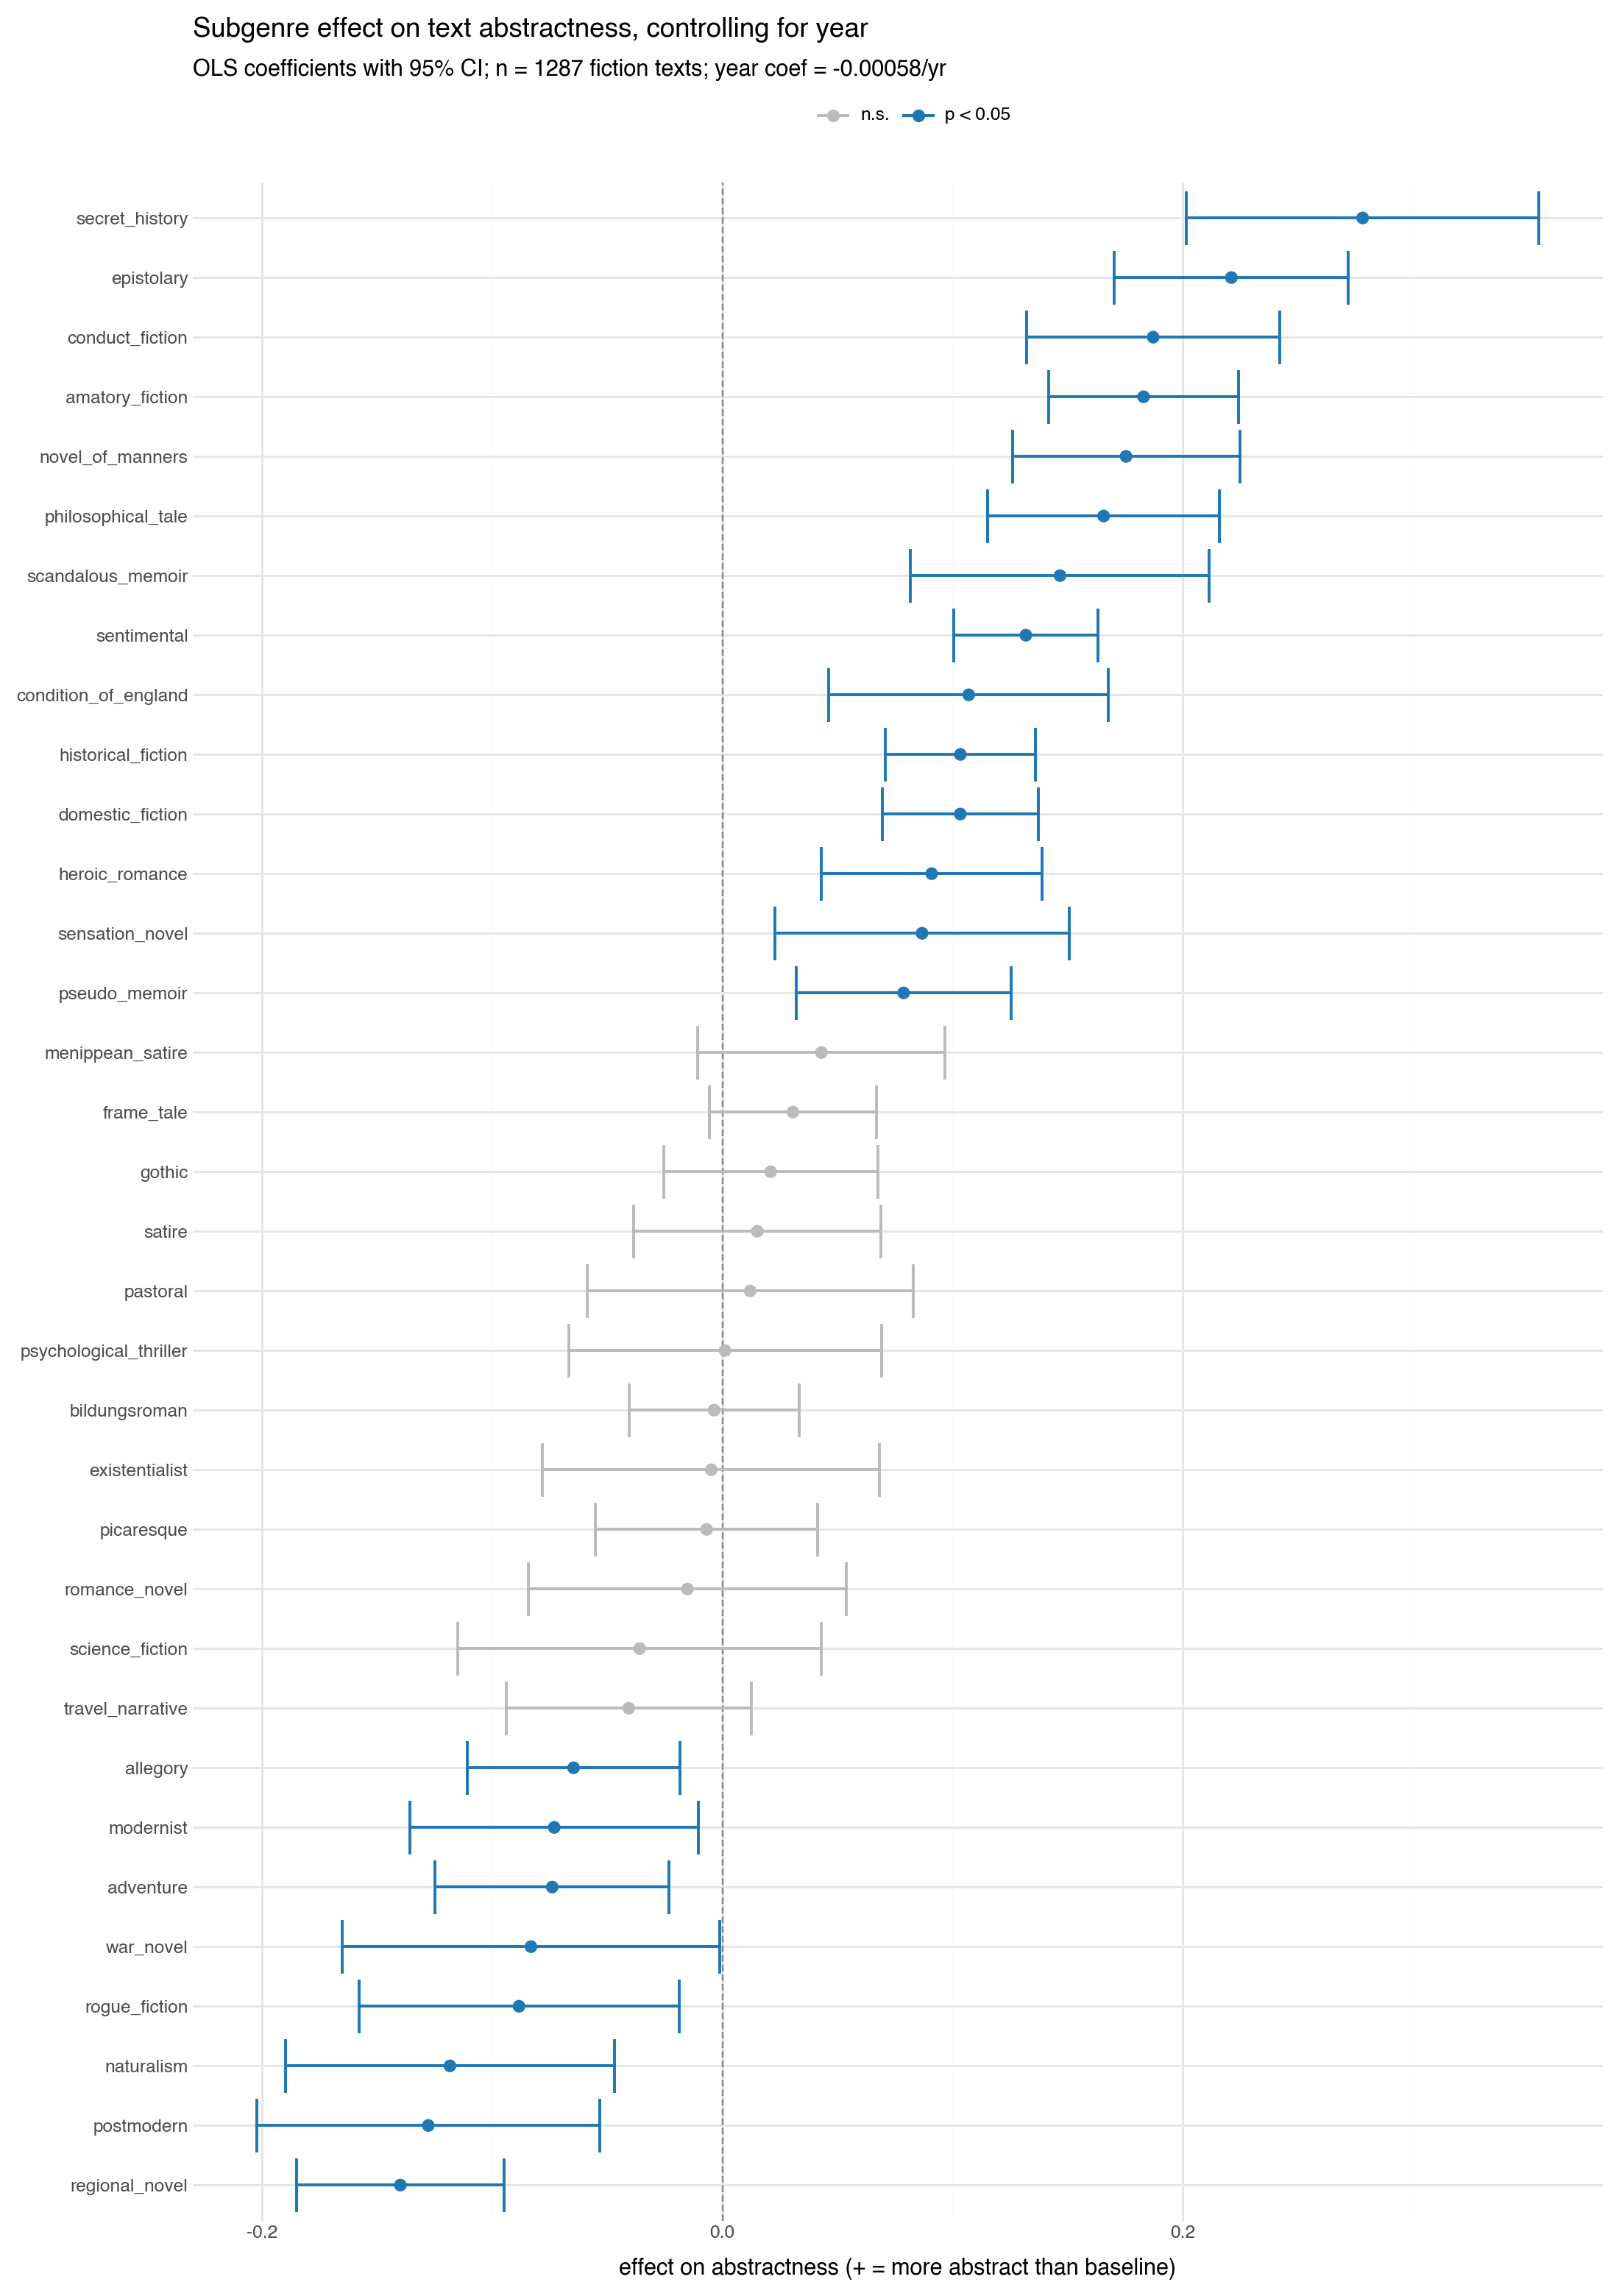

In [10]:
# Per-subgenre coefficient plot: effect on abstractness after detrending year.
# statsmodels gives us SEs and CIs.
import statsmodels.api as sm

X = np.hstack([X_year, X_sg])
X_const = sm.add_constant(X)
ols = sm.OLS(y, X_const).fit()

# Coefficient extraction: const, year, then subgenre dummies in order of elig_tags
coefs = ols.params[2:]
ses = ols.bse[2:]
pvals = ols.pvalues[2:]
coef_df = pd.DataFrame({
    'subgenre': elig_tags,
    'coef': coefs,
    'se': ses,
    'p': pvals,
    'lo': coefs - 1.96 * ses,
    'hi': coefs + 1.96 * ses,
}).sort_values('coef')
coef_df['signif'] = coef_df['p'] < 0.05
coef_df['subgenre'] = pd.Categorical(coef_df['subgenre'],
                                     categories=coef_df['subgenre'].tolist(),
                                     ordered=True)

print(f'Year coef: {ols.params[1]:+.5f} per year (t = {ols.tvalues[1]:.2f}, p = {ols.pvalues[1]:.2e})')
print()
print('Subgenre coefficients (effect on abstractness after detrending), sorted:')
print(coef_df[['subgenre', 'coef', 'se', 'p', 'signif']].to_string(index=False))

p_coef = (p9.ggplot(coef_df, p9.aes(x='coef', y='subgenre', color='signif'))
          + p9.geom_vline(xintercept=0, linetype='dashed', color='#888888')
          + p9.geom_errorbarh(p9.aes(xmin='lo', xmax='hi'), height=0.0, size=0.8)
          + p9.geom_point(size=2.5)
          + p9.scale_color_manual(values={True: '#1f77b4', False: '#bbbbbb'},
                                  labels={True: 'p < 0.05', False: 'n.s.'})
          + p9.labs(
              title='Subgenre effect on text abstractness, controlling for year',
              subtitle=f'OLS coefficients with 95% CI; n = {n} fiction texts; year coef = {ols.params[1]:+.5f}/yr',
              x='effect on abstractness (+ = more abstract than baseline)',
              y='',
              color='',
          )
          + p9.theme_minimal()
          + p9.theme(figure_size=(11, max(5, 0.4 * len(elig_tags) + 2)),
                     legend_position='top'))

out = os.path.join(DROPBOX_FIGS, 'subgenre_abstractness_coefficients.png')
p_coef.save(out, dpi=300, verbose=False)
print(f'\nSaved to {out}')
p_coef

## 6. Coincidence between subgenre and plot_genre

Two questions on the same set of 749 pre-1800 texts that have subgenre tags + plot_genre labels + whole-text abstractness:

1. **Cross-tab / lift heatmap** — for each (subgenre tag, plot_genre category) pair, compute lift = P(both) / [P(subgenre) · P(plot_genre_cat)]. Lift > 1 = positively associated; <1 = negatively associated. Tells us which Frye/Pavel categories cluster which subgenres.
2. **Variance partition (subgenre vs plot_genre vs year)** — fit `abs ~ year + subgenre`, `abs ~ year + plot_genre`, and `abs ~ year + subgenre + plot_genre`; decompose unique vs shared variance.

1,287 pre-1800 texts with subgenre + plot_genre + abstractness + year


Saved to /Users/rj416/Dropbox/Prof/Books/AbsLitHist/book/figures/subgenre_plot_genre_lift.png

Strongest positive associations (lift > 2.0, n_joint >= 10):
          subgenre                       pg_label  lift  n_joint
     bildungsroman  plot_structure: bildungsroman  4.43      102
        frame_tale     plot_structure: frame_tale  4.00       65
    heroic_romance             frye_mode: romance  3.57      112
  novel_of_manners     pavel_tradition: synthesis  2.93       88
    heroic_romance     moral_source: transcendent  2.79      139
     pseudo_memoir            ending_type: return  2.71       25
        picaresque           moral_source: absent  2.47       40
  novel_of_manners                 mythos: comedy  2.45       63
    regional_novel     pavel_tradition: synthesis  2.38       78
    heroic_romance      pavel_tradition: idealist  2.37      152
        picaresque pavel_tradition: anti_idealist  2.36      125
    regional_novel  plot_structure: bildungsroman  2.31       30

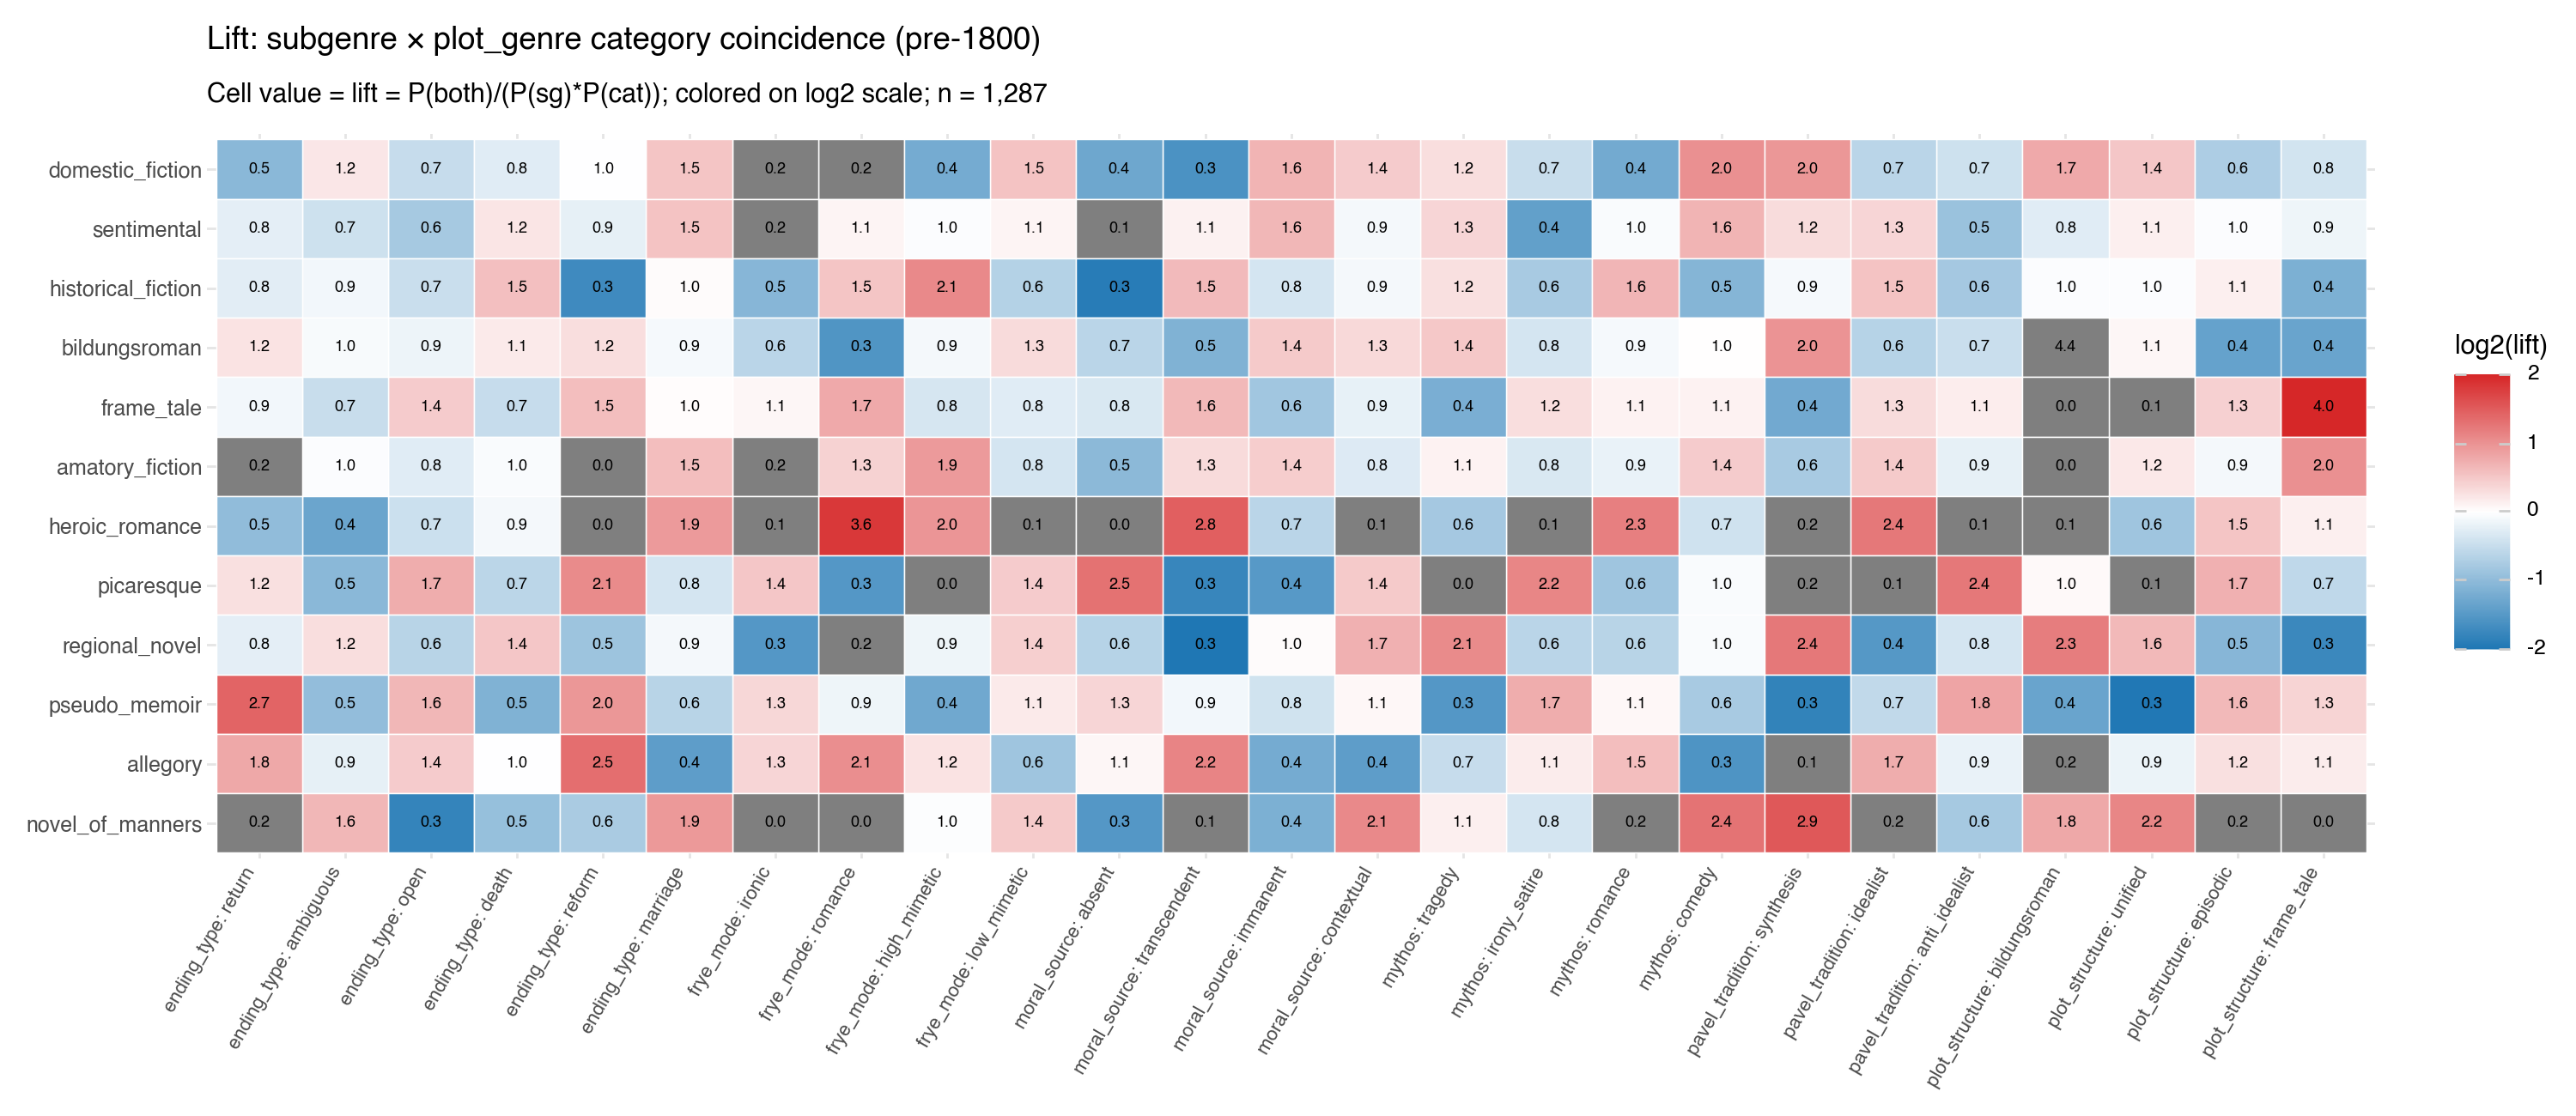

In [11]:
# Load plot_genre annotations + merge with the subgenre+abstractness work-set.
pg_rows = []
for _id, d in iter_task_results('plot_genre'):
    row = {'source': _id}
    for k in ('mythos', 'frye_mode', 'pavel_tradition', 'moral_source',
             'plot_structure', 'ending_type'):
        row[k] = d.get(k)
    pg_rows.append(row)
pg_df = pd.DataFrame(pg_rows)

joint = work.merge(pg_df, on='source', how='inner')
print(f'{len(joint):,} pre-1800 texts with subgenre + plot_genre + abstractness + year')

PG_FIELDS = ['mythos', 'frye_mode', 'pavel_tradition',
             'moral_source', 'plot_structure', 'ending_type']

# Lift table: rows = top-12 subgenres, cols = (field, category) flattened
top12 = [t for t, _ in sg_counter.most_common(12)]
N = len(joint)

lift_rows = []
for sg in top12:
    has_sg = joint['subgenres'].apply(lambda L: sg in L).values
    p_sg = has_sg.mean()
    for f in PG_FIELDS:
        for cat in joint[f].dropna().unique():
            in_cat = (joint[f] == cat).values
            n_cat = in_cat.sum()
            if n_cat < 20:
                continue
            p_cat = in_cat.mean()
            p_joint = (has_sg & in_cat).mean()
            if p_sg == 0 or p_cat == 0:
                continue
            lift = p_joint / (p_sg * p_cat)
            lift_rows.append({
                'subgenre': sg,
                'pg_label': f'{f}: {cat}',
                'field': f,
                'lift': lift,
                'log2_lift': np.log2(lift) if lift > 0 else np.nan,
                'n_joint': int((has_sg & in_cat).sum()),
                'n_cat': int(n_cat),
            })
lift_df = pd.DataFrame(lift_rows)

# Order rows (subgenres) by overall mass, columns by field then by mean log2_lift
sg_order = top12  # most-common first
pg_order = (lift_df.groupby(['field', 'pg_label'])['log2_lift'].mean()
            .reset_index()
            .sort_values(['field', 'log2_lift'])
            ['pg_label'].tolist())
lift_df['subgenre'] = pd.Categorical(lift_df['subgenre'], categories=sg_order[::-1], ordered=True)
lift_df['pg_label'] = pd.Categorical(lift_df['pg_label'], categories=pg_order, ordered=True)

p_lift = (p9.ggplot(lift_df, p9.aes(x='pg_label', y='subgenre', fill='log2_lift'))
          + p9.geom_tile(color='white', size=0.3)
          + p9.geom_text(p9.aes(label='lift'),
                         data=lift_df.assign(lift=lift_df['lift'].round(1)),
                         size=6.5)
          + p9.scale_fill_gradient2(low='#1f77b4', mid='white', high='#d62728',
                                    midpoint=0, limits=(-2, 2))
          + p9.labs(
              title='Lift: subgenre × plot_genre category coincidence (pre-1800)',
              subtitle=f'Cell value = lift = P(both)/(P(sg)*P(cat)); colored on log2 scale; n = {N:,}',
              x='', y='', fill='log2(lift)',
          )
          + p9.theme_minimal()
          + p9.theme(figure_size=(15, 6.5),
                     axis_text_x=p9.element_text(rotation=60, ha='right', size=8),
                     axis_text_y=p9.element_text(size=9)))

out = os.path.join(DROPBOX_FIGS, 'subgenre_plot_genre_lift.png')
p_lift.save(out, dpi=300, verbose=False)
print(f'Saved to {out}')

# Top associations
print('\nStrongest positive associations (lift > 2.0, n_joint >= 10):')
top_pos = lift_df[(lift_df['lift'] > 2.0) & (lift_df['n_joint'] >= 10)] \
    .sort_values('lift', ascending=False).head(20)
print(top_pos[['subgenre', 'pg_label', 'lift', 'n_joint']].round(2).to_string(index=False))

print('\nStrongest negative associations (lift < 0.5, n_cat >= 50):')
top_neg = lift_df[(lift_df['lift'] < 0.5) & (lift_df['n_cat'] >= 50)] \
    .sort_values('lift').head(15)
print(top_neg[['subgenre', 'pg_label', 'lift', 'n_joint']].round(2).to_string(index=False))

p_lift

### 6b. Variance partition: subgenre vs plot_genre vs year

Three nested model comparisons on the joined sample. The interesting question is whether plot_genre adds anything *on top of* subgenre, and vice versa — i.e. how much do the two annotation layers redundantly cover the same variance.

In [12]:
# Build feature matrices on the joint set.
n_j = len(joint)
y_j = joint['abs_score'].values
X_year_j = (joint[['year']].values.astype(float) - joint['year'].mean())

# Subgenre dummies (multi-label, n>=30 in the joint set)
joint_sg_counter = Counter()
for tags in joint['subgenres']:
    for t in tags:
        joint_sg_counter[t] += 1
elig_sg = [t for t, n in joint_sg_counter.most_common() if n >= 30]
X_sg_j = np.array([[1.0 if t in tags else 0.0 for t in elig_sg]
                   for tags in joint['subgenres']])

# Plot_genre dummies (drop most-common per field)
def make_dummies_joint(field):
    s = joint[field].fillna('__missing__')
    dummies = pd.get_dummies(s, prefix=field).astype(float)
    most_common = s.value_counts().index[0]
    ref_col = f'{field}_{most_common}'
    if ref_col in dummies.columns:
        dummies = dummies.drop(columns=[ref_col])
    return dummies
X_pg_j = pd.concat([make_dummies_joint(f) for f in PG_FIELDS], axis=1).values

def fit(X):
    return LinearRegression().fit(X, y_j).score(X, y_j)

r2_y     = fit(X_year_j)
r2_sg    = fit(X_sg_j)
r2_pg    = fit(X_pg_j)
r2_y_sg  = fit(np.hstack([X_year_j, X_sg_j]))
r2_y_pg  = fit(np.hstack([X_year_j, X_pg_j]))
r2_sg_pg = fit(np.hstack([X_sg_j, X_pg_j]))
r2_all   = fit(np.hstack([X_year_j, X_sg_j, X_pg_j]))

print(f'n = {n_j:,}; subgenre dummies = {len(elig_sg)}; plot_genre dummies = {X_pg_j.shape[1]}')
print()
print(f'  R^2 year                 = {r2_y:.4f}')
print(f'  R^2 subgenre             = {r2_sg:.4f}')
print(f'  R^2 plot_genre           = {r2_pg:.4f}')
print(f'  R^2 year + subgenre      = {r2_y_sg:.4f}')
print(f'  R^2 year + plot_genre    = {r2_y_pg:.4f}')
print(f'  R^2 subgenre + plot_genre = {r2_sg_pg:.4f}')
print(f'  R^2 all three            = {r2_all:.4f}')
print()
print('--- 3-way variance partition ---')
unique_year = r2_all - r2_sg_pg
unique_sg   = r2_all - r2_y_pg
unique_pg   = r2_all - r2_y_sg
print(f'  Unique to YEAR        = {unique_year:.4f}')
print(f'  Unique to SUBGENRE    = {unique_sg:.4f}')
print(f'  Unique to PLOT_GENRE  = {unique_pg:.4f}')
print(f'  Shared (any pair/all) = {r2_all - unique_year - unique_sg - unique_pg:.4f}')
print(f'  Total                 = {r2_all:.4f}')
print()
print('--- Pairwise additions (does X add to Y+others?) ---')
print(f'  plot_genre adds, on top of (year + subgenre): {(r2_all - r2_y_sg):.4f}')
print(f'  subgenre   adds, on top of (year + plot_genre): {(r2_all - r2_y_pg):.4f}')
print(f'  year       adds, on top of (subgenre + plot_genre): {(r2_all - r2_sg_pg):.4f}')

n = 1,287; subgenre dummies = 34; plot_genre dummies = 21

  R^2 year                 = 0.2234
  R^2 subgenre             = 0.5616
  R^2 plot_genre           = 0.2770
  R^2 year + subgenre      = 0.5745
  R^2 year + plot_genre    = 0.3978
  R^2 subgenre + plot_genre = 0.6098
  R^2 all three            = 0.6176

--- 3-way variance partition ---
  Unique to YEAR        = 0.0078
  Unique to SUBGENRE    = 0.2198
  Unique to PLOT_GENRE  = 0.0431
  Shared (any pair/all) = 0.3470
  Total                 = 0.6176

--- Pairwise additions (does X add to Y+others?) ---
  plot_genre adds, on top of (year + subgenre): 0.0431
  subgenre   adds, on top of (year + plot_genre): 0.2198
  year       adds, on top of (subgenre + plot_genre): 0.0078


## 7. Robustness: time as 25-year-bin dummies (not linear year)

A methodological correction. The §5 and §6 decompositions used `year` as a single linear coefficient, which gives time only 1 df vs subgenre's 19 dummies. But subgenres are themselves periodizations (`amatory_fiction` is concentrated 1670-1730, `sentimental` is 1740-1810, etc.), so giving time only 1 df forces all the non-linear structure of historical change into subgenre's "unique" bucket.

Fairer comparison: replace linear year with **25-year-bin dummies** (~12 df, similar to subgenre's 19). Whatever's still uniquely subgenre after that is the **form-net-of-period** signal, not "subgenre absorbing what year couldn't."

Re-run both the 2-way (subgenre vs time) and 3-way (subgenre + plot_genre + time) decompositions with this binned-time spec, side-by-side with the linear-year results.

In [13]:
# Build 25-year-bin dummies on the same `joint` sample from §6.
joint['bin'] = (joint['year'] // 25 * 25).astype(int)
bin_dummies = pd.get_dummies(joint['bin'], prefix='bin').astype(float)
# Drop most common as reference for comparability with the other dummies
ref_bin = joint['bin'].value_counts().index[0]
bin_dummies = bin_dummies.drop(columns=[f'bin_{ref_bin}'])
X_bin = bin_dummies.values
print(f'25-yr bin dummies: {X_bin.shape[1]}  (reference bin = {ref_bin})')

# Recompute everything with X_bin replacing X_year_j (subgenre and plot_genre
# matrices are unchanged from §6: X_sg_j, X_pg_j).
def fit_b(X):
    return LinearRegression().fit(X, y_j).score(X, y_j)

r2_b      = fit_b(X_bin)
r2_sg_b   = fit_b(X_sg_j)
r2_pg_b   = fit_b(X_pg_j)
r2_b_sg   = fit_b(np.hstack([X_bin, X_sg_j]))
r2_b_pg   = fit_b(np.hstack([X_bin, X_pg_j]))
r2_sg_pg_b = fit_b(np.hstack([X_sg_j, X_pg_j]))
r2_all_b  = fit_b(np.hstack([X_bin, X_sg_j, X_pg_j]))

print()
print(f'{"":<28} {"linear year":>13} {"25-yr bins":>13}')
print('-' * 56)
print(f'{"R^2 time alone":<28} {r2_y:>13.4f} {r2_b:>13.4f}   ({X_bin.shape[1]} df)')
print(f'{"R^2 subgenre alone":<28} {r2_sg:>13.4f} {r2_sg_b:>13.4f}')
print(f'{"R^2 plot_genre alone":<28} {r2_pg:>13.4f} {r2_pg_b:>13.4f}')
print(f'{"R^2 time + subgenre":<28} {r2_y_sg:>13.4f} {r2_b_sg:>13.4f}')
print(f'{"R^2 time + plot_genre":<28} {r2_y_pg:>13.4f} {r2_b_pg:>13.4f}')
print(f'{"R^2 subgenre + plot_genre":<28} {r2_sg_pg:>13.4f} {r2_sg_pg_b:>13.4f}')
print(f'{"R^2 all three":<28} {r2_all:>13.4f} {r2_all_b:>13.4f}')

print()
print('--- 3-way variance partition ---')
u_year_lin = r2_all - r2_sg_pg
u_sg_lin   = r2_all - r2_y_pg
u_pg_lin   = r2_all - r2_y_sg
sh_lin     = r2_all - u_year_lin - u_sg_lin - u_pg_lin

u_bin     = r2_all_b - r2_sg_pg_b
u_sg_b    = r2_all_b - r2_b_pg
u_pg_b    = r2_all_b - r2_b_sg
sh_b      = r2_all_b - u_bin - u_sg_b - u_pg_b

print(f'{"":<28} {"linear year":>13} {"25-yr bins":>13}')
print('-' * 56)
print(f'{"Unique to TIME":<28} {u_year_lin:>13.4f} {u_bin:>13.4f}')
print(f'{"Unique to SUBGENRE":<28} {u_sg_lin:>13.4f} {u_sg_b:>13.4f}')
print(f'{"Unique to PLOT_GENRE":<28} {u_pg_lin:>13.4f} {u_pg_b:>13.4f}')
print(f'{"Shared":<28} {sh_lin:>13.4f} {sh_b:>13.4f}')
print(f'{"Total":<28} {r2_all:>13.4f} {r2_all_b:>13.4f}')

print()
print('--- Pairwise additions ---')
print(f'{"":<40} {"linear year":>13} {"25-yr bins":>13}')
print(f'{"plot_genre adds, on top of (time + sg)":<40} '
      f'{r2_all - r2_y_sg:>13.4f} {r2_all_b - r2_b_sg:>13.4f}')
print(f'{"subgenre adds, on top of (time + pg)":<40} '
      f'{r2_all - r2_y_pg:>13.4f} {r2_all_b - r2_b_pg:>13.4f}')
print(f'{"time adds, on top of (subgenre + pg)":<40} '
      f'{r2_all - r2_sg_pg:>13.4f} {r2_all_b - r2_sg_pg_b:>13.4f}')

print()
ratio_lin = u_sg_lin / u_year_lin if u_year_lin > 0 else float('inf')
ratio_b   = u_sg_b / u_bin if u_bin > 0 else float('inf')
print(f'Subgenre/time unique-effect ratio:  '
      f'linear year = {ratio_lin:.2f}x  -->  25-yr bins = {ratio_b:.2f}x')

25-yr bin dummies: 21  (reference bin = 1675)

                               linear year    25-yr bins
--------------------------------------------------------
R^2 time alone                      0.2234        0.5363   (21 df)
R^2 subgenre alone                  0.5616        0.5616
R^2 plot_genre alone                0.2770        0.2770
R^2 time + subgenre                 0.5745        0.6959
R^2 time + plot_genre               0.3978        0.6242
R^2 subgenre + plot_genre           0.6098        0.6098
R^2 all three                       0.6176        0.7211

--- 3-way variance partition ---
                               linear year    25-yr bins
--------------------------------------------------------
Unique to TIME                      0.0078        0.1113
Unique to SUBGENRE                  0.2198        0.0969
Unique to PLOT_GENRE                0.0431        0.0253
Shared                              0.3470        0.4876
Total                               0.6176        0.72

## 8. Paratext genre — title-keyword analysis

Many titles announce a genre directly: "A Novel", "A Romance", "A Tale", "The History of...", "Adventures of...", "Memoirs of...", "Life of...". This is paratext-level self-positioning, distinct from both bibliographic form-tags and subgenre annotations.

Two analyses parallel to §6:
1. **Coincidence**: lift heatmap, paratext keywords × subgenre tags
2. **Variance partition**: extend the 3-way (time + subgenre + plot_genre) to 4-way by adding paratext as a fourth feature set. Does paratext add anything on top of subgenre + plot_genre + time?

Note: refetching full titles from lltk because the analysis CSV truncates to 50 chars.

In [14]:
import re
import lltk

# Use match-group-aware longest_titles helper (lltk commit 49d8105) to capture
# subtitles like "...A Novel" / "...In Two Tales" that may live in a different
# copy of the same work than the canonical id.
longest = lltk.db.longest_titles(joint['source'].tolist())

# Guard against non-English title sources (helper takes argMax across all
# match-group siblings including translations). Fall back to direct title where
# the longest copy is non-English.
src_lang = lltk.db.fetch_metadata(longest['title_source_id'].dropna().unique().tolist(),
                                  columns=['lang']).set_index('_id')['lang']
direct = lltk.db.fetch_metadata(joint['source'].tolist(),
                                columns=['title']).set_index('_id')['title']
def pick_title(row):
    src = row['title_source_id']
    if pd.isna(src) or src_lang.get(src) != 'en':
        return direct.get(row['_id'], row['title'])
    return row['title']
longest['title_full'] = longest.apply(pick_title, axis=1)

n_swap = (longest['title_full'].str.len() > longest['_id'].map(direct).fillna('').str.len()).sum()
print(f'longest_titles: {n_swap}/{len(longest)} got a longer title from a sibling (after lang guard)')

joint = joint.drop(columns=[c for c in joint.columns if c == 'title_full'], errors='ignore')
joint = joint.merge(longest[['_id', 'title_full', 'title_source_id']],
                    left_on='source', right_on='_id', how='left', suffixes=('', '_dup'))

PARATEXT_PATTERNS = {
    'pt_novel':       re.compile(r'\bnovel\b', re.I),
    'pt_romance':     re.compile(r'\bromance\b', re.I),
    'pt_tale':        re.compile(r'\btales?\b', re.I),
    'pt_history':     re.compile(r'\bhistory\b', re.I),
    'pt_memoirs':     re.compile(r'\bmemoirs?\b', re.I),
    'pt_adventures':  re.compile(r'\badventures?\b', re.I),
    'pt_life':        re.compile(r'\blife\b', re.I),
}

for col, pat in PARATEXT_PATTERNS.items():
    joint[col] = joint['title_full'].astype(str).str.contains(pat, regex=True).astype(int)

print(f'\nParatext-tag counts in the joint sample (n = {len(joint):,}):')
for col in PARATEXT_PATTERNS:
    name = col.replace('pt_', '')
    print(f'  {name:<12} {joint[col].sum():>4}')
print(f'  any tag      {joint[list(PARATEXT_PATTERNS.keys())].sum(axis=1).gt(0).sum():>4}')
print(f'  no tag       {joint[list(PARATEXT_PATTERNS.keys())].sum(axis=1).eq(0).sum():>4}')

longest_titles: 485/1287 got a longer title from a sibling (after lang guard)

Paratext-tag counts in the joint sample (n = 1,287):
  novel         148
  romance        56
  tale           73
  history       147
  memoirs        36
  adventures     77
  life           88
  any tag       518
  no tag        769


Saved to /Users/rj416/Dropbox/Prof/Books/AbsLitHist/book/figures/subgenre_paratext_lift.png

Strongest positive associations (lift > 2.0, n_joint >= 5):
  paratext           subgenre  lift  n_joint  n_para
adventures      pseudo_memoir  3.55       28      77
      life      pseudo_memoir  3.55       32      88
   romance     heroic_romance  3.13       23      56
      life         picaresque  3.03       29      88
   memoirs      pseudo_memoir  2.98       11      36
adventures         picaresque  2.75       23      77
   romance historical_fiction  2.48       39      56
     novel    amatory_fiction  2.06       42     148


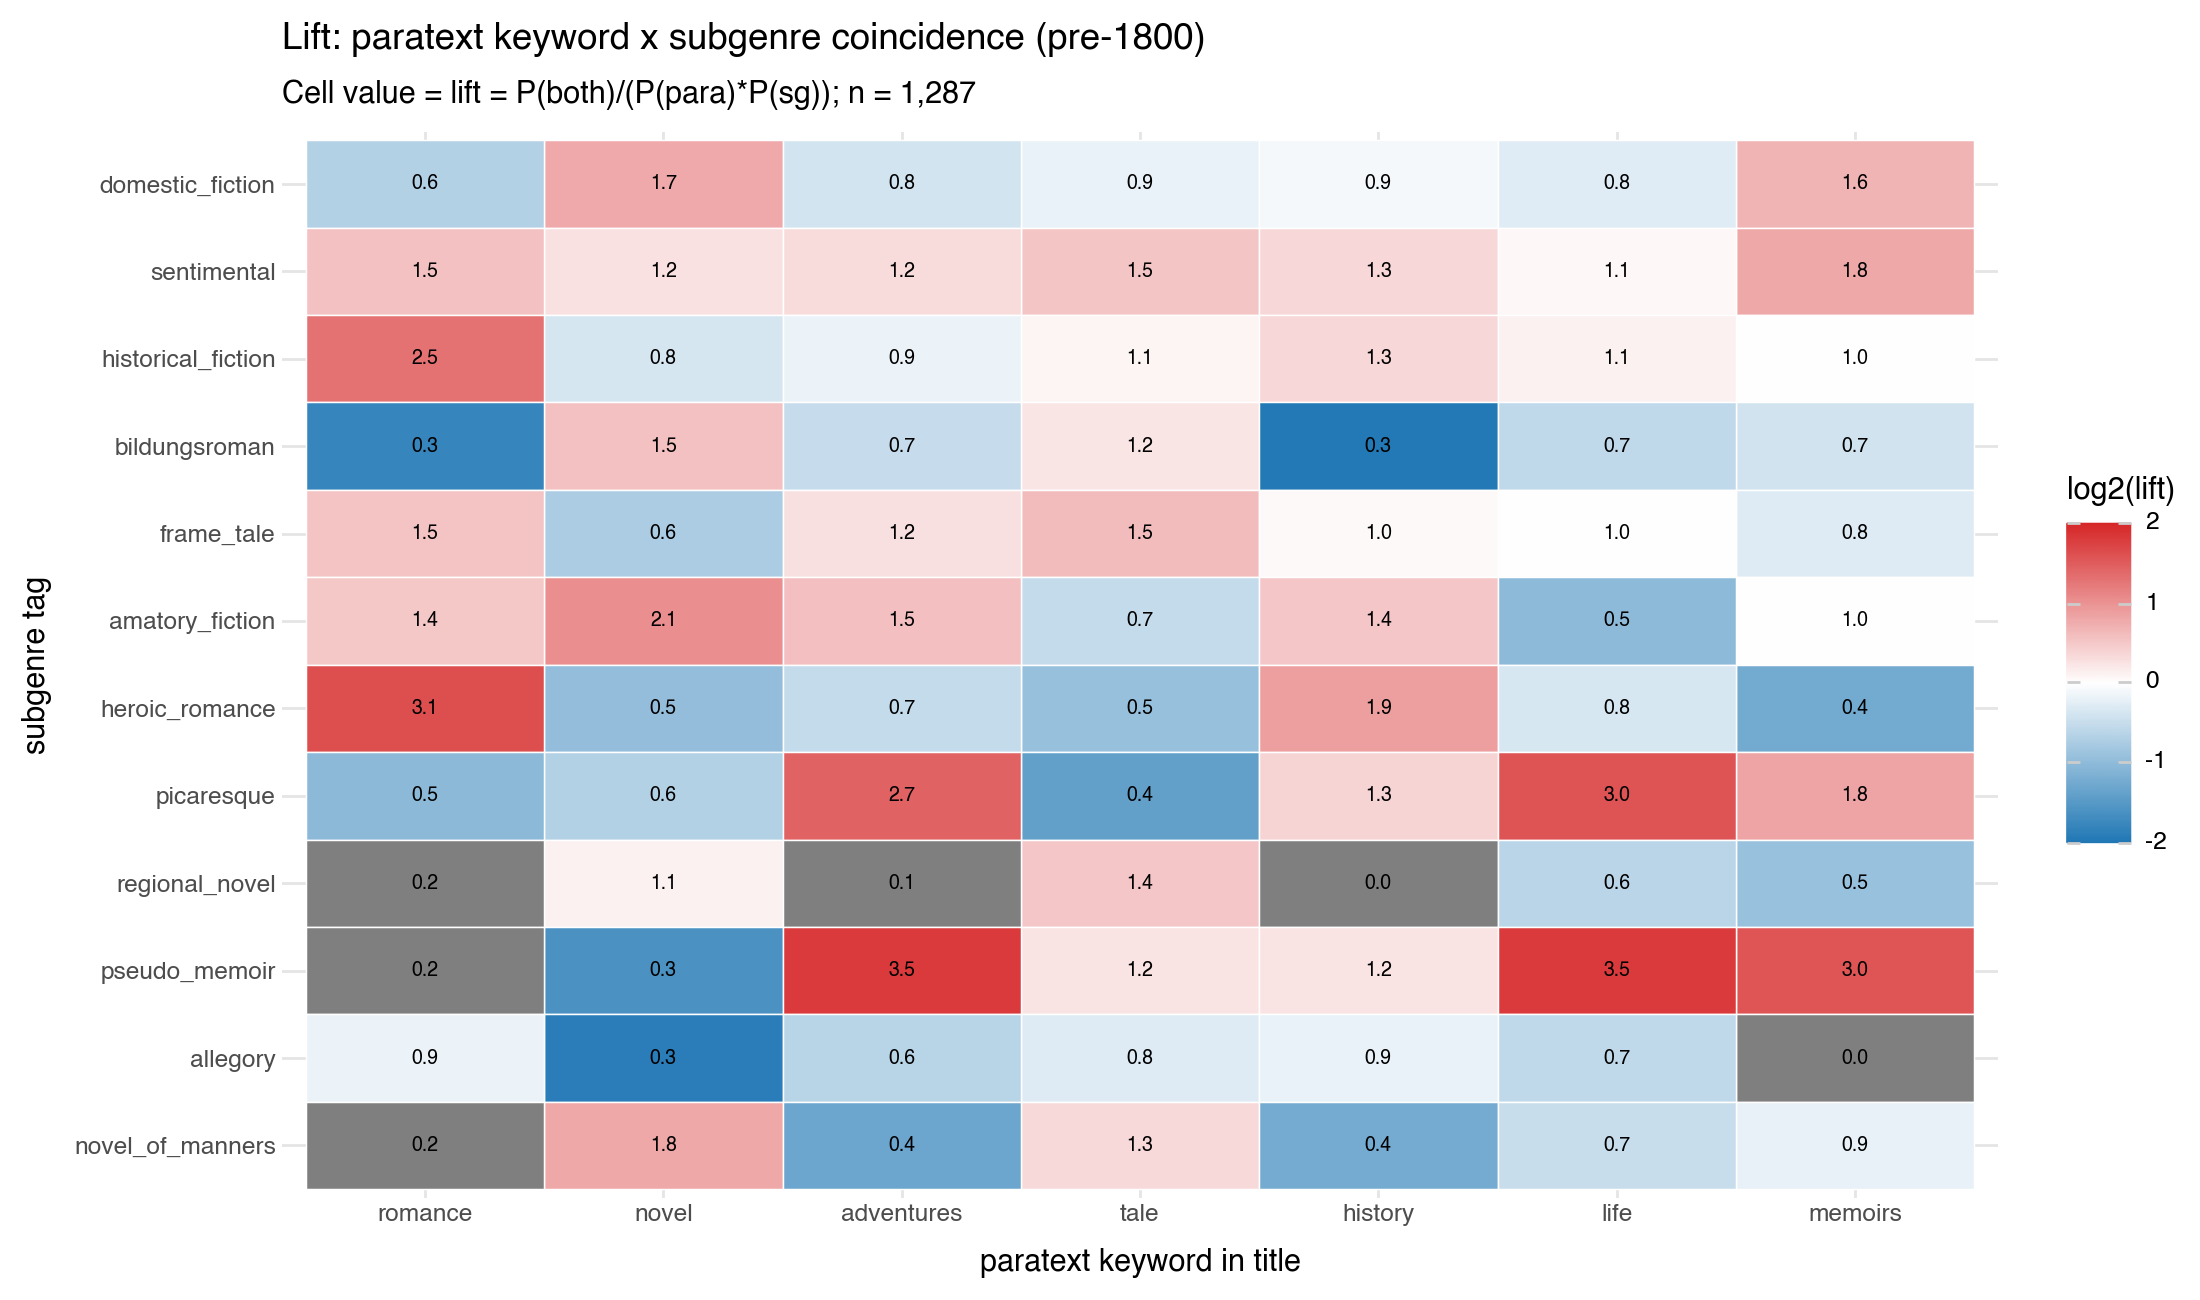

In [15]:
# Lift heatmap: paratext keywords x top-12 subgenres
N_j = len(joint)
top12 = [t for t, _ in sg_counter.most_common(12)]

lift_rows = []
for sg in top12:
    has_sg = joint['subgenres'].apply(lambda L: sg in L).values
    p_sg = has_sg.mean()
    for col, pat in PARATEXT_PATTERNS.items():
        name = col.replace('pt_', '')
        in_para = joint[col].astype(bool).values
        n_para = in_para.sum()
        if n_para < 10:
            continue
        p_para = in_para.mean()
        p_joint = (has_sg & in_para).mean()
        if p_sg == 0 or p_para == 0:
            continue
        lift = p_joint / (p_sg * p_para)
        lift_rows.append({
            'subgenre': sg,
            'paratext': name,
            'lift': lift,
            'log2_lift': np.log2(lift) if lift > 0 else np.nan,
            'n_joint': int((has_sg & in_para).sum()),
            'n_para': int(n_para),
        })
para_lift = pd.DataFrame(lift_rows)

# Order paratext cols by mean log2_lift, subgenres by mass
para_order = (para_lift.groupby('paratext')['log2_lift'].mean()
              .sort_values().index.tolist())
para_lift['paratext'] = pd.Categorical(para_lift['paratext'], categories=para_order, ordered=True)
para_lift['subgenre'] = pd.Categorical(para_lift['subgenre'], categories=top12[::-1], ordered=True)

p_pl = (p9.ggplot(para_lift, p9.aes(x='paratext', y='subgenre', fill='log2_lift'))
        + p9.geom_tile(color='white', size=0.3)
        + p9.geom_text(p9.aes(label='lift'),
                       data=para_lift.assign(lift=para_lift['lift'].round(1)),
                       size=7)
        + p9.scale_fill_gradient2(low='#1f77b4', mid='white', high='#d62728',
                                  midpoint=0, limits=(-2, 2))
        + p9.labs(
            title='Lift: paratext keyword x subgenre coincidence (pre-1800)',
            subtitle=f'Cell value = lift = P(both)/(P(para)*P(sg)); n = {N_j:,}',
            x='paratext keyword in title', y='subgenre tag', fill='log2(lift)',
        )
        + p9.theme_minimal()
        + p9.theme(figure_size=(11, 6.5)))

out = os.path.join(DROPBOX_FIGS, 'subgenre_paratext_lift.png')
p_pl.save(out, dpi=300, verbose=False)
print(f'Saved to {out}')

print('\nStrongest positive associations (lift > 2.0, n_joint >= 5):')
top = para_lift[(para_lift['lift'] > 2.0) & (para_lift['n_joint'] >= 5)] \
    .sort_values('lift', ascending=False).head(15)
print(top[['paratext', 'subgenre', 'lift', 'n_joint', 'n_para']].round(2).to_string(index=False))

p_pl

In [16]:
# 4-way variance partition: time-bin + subgenre + plot_genre + paratext
# Reuses X_bin, X_sg_j, X_pg_j from §7. Builds X_para from joint columns.
PARA_COLS = list(PARATEXT_PATTERNS.keys())
X_para = joint[PARA_COLS].values.astype(float)
print(f'Paratext features: {len(PARA_COLS)} (n={len(joint):,})')

def fit4(X):
    return LinearRegression().fit(X, y_j).score(X, y_j)

# Singletons (paratext)
r2_para = fit4(X_para)
# Triples (one missing each)
r2_no_b    = fit4(np.hstack([X_sg_j, X_pg_j, X_para]))
r2_no_sg   = fit4(np.hstack([X_bin, X_pg_j, X_para]))
r2_no_pg   = fit4(np.hstack([X_bin, X_sg_j, X_para]))
r2_no_para = fit4(np.hstack([X_bin, X_sg_j, X_pg_j]))  # = r2_all_b
# All four
r2_all4 = fit4(np.hstack([X_bin, X_sg_j, X_pg_j, X_para]))

print()
print(f'  R^2 paratext alone           = {r2_para:.4f}  ({len(PARA_COLS)} df)')
print(f'  R^2 time-bin alone           = {r2_b:.4f}  ({X_bin.shape[1]} df)')
print(f'  R^2 subgenre alone           = {r2_sg:.4f}  ({X_sg_j.shape[1]} df)')
print(f'  R^2 plot_genre alone         = {r2_pg:.4f}  ({X_pg_j.shape[1]} df)')
print(f'  R^2 all 3 (no paratext)      = {r2_no_para:.4f}')
print(f'  R^2 all 4                    = {r2_all4:.4f}')
print()
print('--- 4-way variance partition (time-bin spec) ---')
u_b    = r2_all4 - r2_no_b
u_sg   = r2_all4 - r2_no_sg
u_pg   = r2_all4 - r2_no_pg
u_para = r2_all4 - r2_no_para
shared = r2_all4 - u_b - u_sg - u_pg - u_para
print(f'  Unique to TIME-BIN   = {u_b:.4f}')
print(f'  Unique to SUBGENRE   = {u_sg:.4f}')
print(f'  Unique to PLOT_GENRE = {u_pg:.4f}')
print(f'  Unique to PARATEXT   = {u_para:.4f}')
print(f'  Shared               = {shared:.4f}')
print(f'  Total                = {r2_all4:.4f}')

print()
print('--- Pairwise additions (does X add anything to Y+others?) ---')
print(f'  paratext   adds, on top of (time + sg + pg):   {r2_all4 - r2_no_para:.4f}')
print(f'  plot_genre adds, on top of (time + sg + para): {r2_all4 - r2_no_pg:.4f}')
print(f'  subgenre   adds, on top of (time + pg + para): {r2_all4 - r2_no_sg:.4f}')
print(f'  time-bin   adds, on top of (sg + pg + para):   {r2_all4 - r2_no_b:.4f}')

# Per-paratext coefficients controlling for time + subgenre + plot_genre
import statsmodels.api as sm
X_full = np.hstack([X_bin, X_sg_j, X_pg_j, X_para])
X_const = sm.add_constant(X_full)
ols4 = sm.OLS(y_j, X_const).fit()
para_offset = 1 + X_bin.shape[1] + X_sg_j.shape[1] + X_pg_j.shape[1]
hdr_para, hdr_coef, hdr_se, hdr_p = 'paratext', 'coef', 'se', 'p'
print()
print('Paratext coefficients controlling for time + subgenre + plot_genre:')
print(f'{hdr_para:<12} {hdr_coef:>8} {hdr_se:>8} {hdr_p:>10}')
for i, col in enumerate(PARA_COLS):
    b = ols4.params[para_offset + i]
    s = ols4.bse[para_offset + i]
    p = ols4.pvalues[para_offset + i]
    name = col.replace('pt_', '')
    sig = '*' if p < 0.05 else ' '
    print(f'  {name:<10} {b:>+8.4f} {s:>8.4f} {p:>10.4f} {sig}')

Paratext features: 7 (n=1,287)

  R^2 paratext alone           = 0.0923  (7 df)
  R^2 time-bin alone           = 0.5363  (21 df)
  R^2 subgenre alone           = 0.5616  (34 df)
  R^2 plot_genre alone         = 0.2770  (21 df)
  R^2 all 3 (no paratext)      = 0.7211
  R^2 all 4                    = 0.7253

--- 4-way variance partition (time-bin spec) ---
  Unique to TIME-BIN   = 0.1012
  Unique to SUBGENRE   = 0.0924
  Unique to PLOT_GENRE = 0.0238
  Unique to PARATEXT   = 0.0041
  Shared               = 0.5037
  Total                = 0.7253

--- Pairwise additions (does X add anything to Y+others?) ---
  paratext   adds, on top of (time + sg + pg):   0.0041
  plot_genre adds, on top of (time + sg + para): 0.0238
  subgenre   adds, on top of (time + pg + para): 0.0924
  time-bin   adds, on top of (sg + pg + para):   0.1012

Paratext coefficients controlling for time + subgenre + plot_genre:
paratext         coef       se          p
  novel       +0.0316   0.0172     0.0659  
  romance

### Full-sample paratext setup

Pull the full pre-1800 arc_fiction sample (n=1,306) with abstractness scores and longest-title paratext. The remaining cells in §8 use this `arc` dataframe — the lift heatmap and 4-way variance partition above stayed on the smaller `joint` (749) because they need subgenre+plot_genre annotations.

In [17]:
# Pull pre-1800 arc_fiction with scores, attach longest titles, compute paratext columns.
import clickhouse_connect
ch = clickhouse_connect.get_client(host='localhost', port=8123, username='lltk', password='lltk')
arc = ch.query_df('''
    SELECT _id, year, `Abs-Conc.Median.median` AS raw_score
    FROM abstraction.texts_rep
    WHERE arc_corpus='arc_fiction'
      AND year IS NOT NULL AND year < 1800
      AND `Abs-Conc.Median.median` IS NOT NULL
''')
ch.close()
arc['abs_score'] = -arc['raw_score']
print(f'Full pre-1800 arc_fiction with score: n={len(arc):,}')

# Longest titles + lang guard (English-source only, fall back to direct title otherwise)
arc_longest = lltk.db.longest_titles(arc['_id'].tolist())
src_lang = (lltk.db.fetch_metadata(arc_longest['title_source_id'].dropna().unique().tolist(),
                                    columns=['lang']).set_index('_id')['lang'])
arc_direct = (lltk.db.fetch_metadata(arc['_id'].tolist(), columns=['title'])
              .set_index('_id')['title'])
def _pick_title(row):
    src = row['title_source_id']
    if pd.isna(src) or src_lang.get(src) != 'en':
        return arc_direct.get(row['_id'], row['title'])
    return row['title']
arc_longest['title_full'] = arc_longest.apply(_pick_title, axis=1)
arc = arc.merge(arc_longest[['_id', 'title_full']], on='_id', how='left')

# Paratext columns + century
for col, pat in PARATEXT_PATTERNS.items():
    arc[col] = arc['title_full'].astype(str).str.contains(pat, regex=True).astype(int)
arc['century'] = (arc['year'] // 100 * 100).astype(int)
arc['bin'] = (arc['year'] // 25 * 25).astype(int)

# Century-exploded paratext columns (C17 + C18 only; C16 too thin)
PT_X_CENT = []
for col in PARA_COLS:
    name = col.replace('pt_', '')
    for cent in (1600, 1700):
        cname = f'{name}_C{cent//100+1}'
        arc[cname] = ((arc['century'] == cent) & arc[col].astype(bool)).astype(int)
        PT_X_CENT.append(cname)

print(f'Paratext columns: {len(PARA_COLS)} keywords × 2 centuries = {len(PT_X_CENT)} cells')

Full pre-1800 arc_fiction with score: n=1,306


Paratext columns: 7 keywords × 2 centuries = 14 cells


### Paratext keywords over time

Frequency of each paratext keyword in fiction titles, 25-yr bins, full pre-1800 arc_fiction (n=1,306). Each line labeled at its peak.

arc pre-1800 sample: n=1,306


Saved to /Users/rj416/Dropbox/Prof/Books/AbsLitHist/book/figures/subgenre_paratext_keywords_25y.png

Peak bins per paratext keyword:
  paratext  bin   n  total  pct
      tale 1550   4     22 18.2
   romance 1650  16     98 16.3
adventures 1700  15     65 23.1
      life 1700  14     65 21.5
   memoirs 1700  11     65 16.9
   history 1750  63    202 31.2
     novel 1775 106    339 31.3


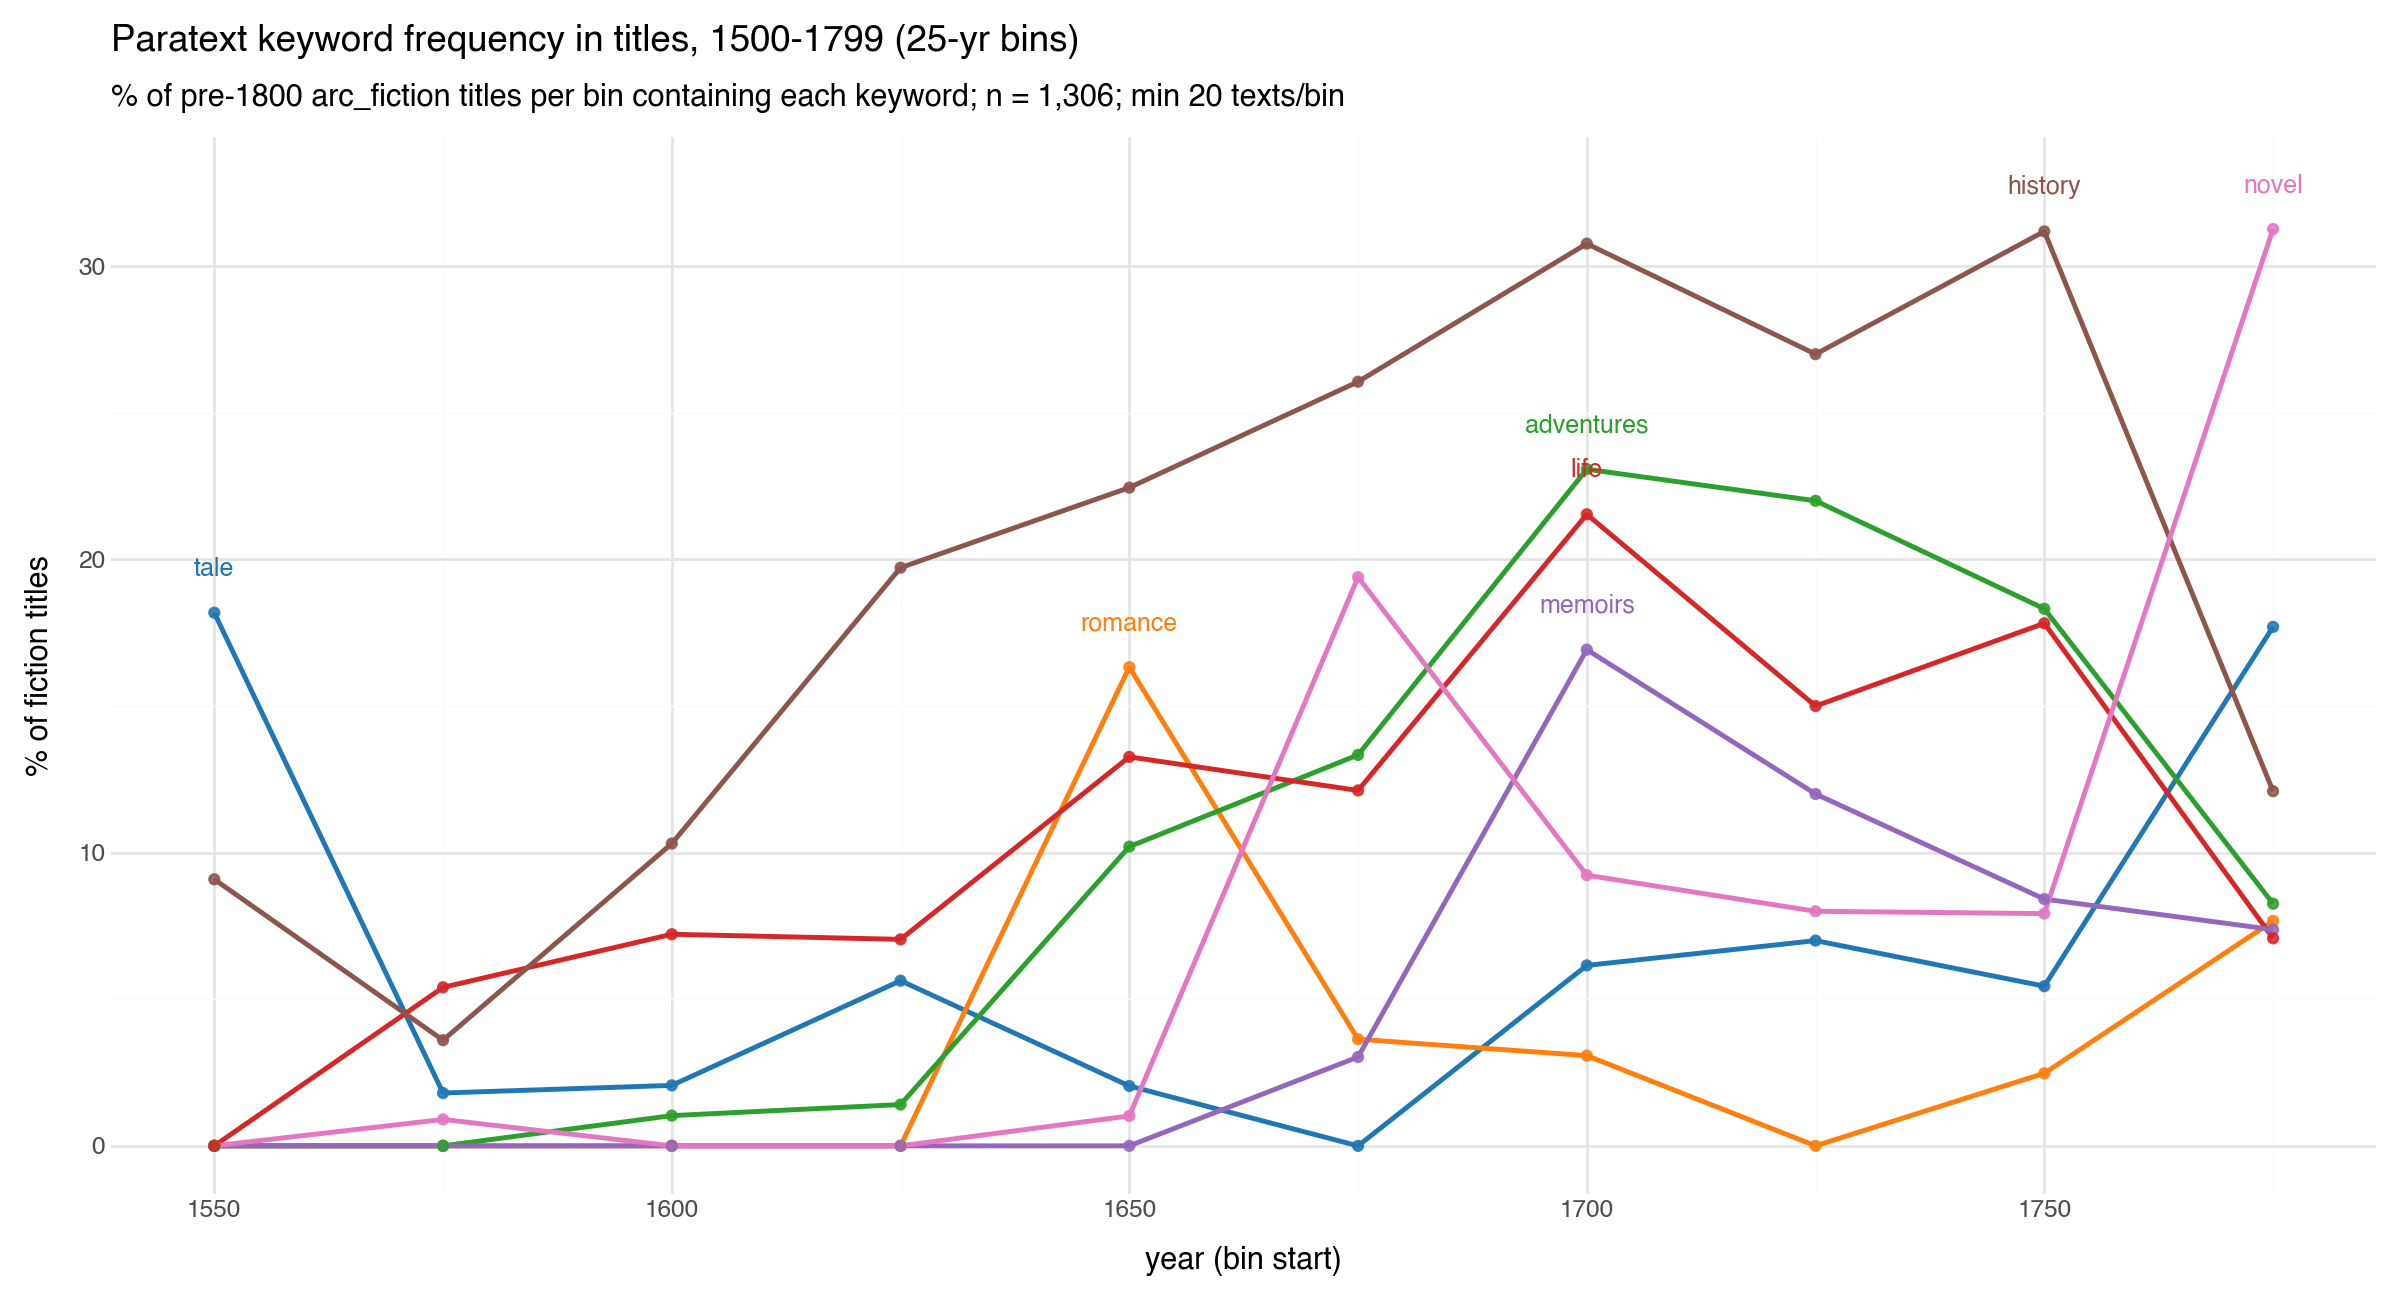

In [18]:
# Paratext keyword frequency over time on the full pre-1800 arc_fiction sample.
# Uses `arc` from the setup cell above (n=1,306).
print(f'arc pre-1800 sample: n={len(arc):,}')

para_names = [c.replace('pt_', '') for c in PARA_COLS]
MIN_TOTAL = 20

para_long_rows = []
for col in PARA_COLS:
    name = col.replace('pt_', '')
    grp = arc.assign(has=arc[col].astype(int)).groupby('bin').agg(
        n=('has', 'sum'),
        total=('has', 'count'),
    ).reset_index()
    grp = grp[grp['total'] >= MIN_TOTAL].copy()
    grp['pct'] = grp['n'] / grp['total'] * 100
    grp['paratext'] = name
    para_long_rows.append(grp)
para_long = pd.concat(para_long_rows, ignore_index=True)

# Order by peak year (early -> late) for left-to-right color reading
peaks_for_order = (para_long.sort_values('pct', ascending=False)
                   .groupby('paratext', as_index=False, observed=True).first()
                   .sort_values('bin'))
para_names_ordered = peaks_for_order['paratext'].tolist()
tab10 = [mcolors.to_hex(c) for c in mcm.tab10.colors]
para_palette = dict(zip(para_names_ordered, tab10[:len(para_names_ordered)]))
para_long['paratext'] = pd.Categorical(para_long['paratext'],
                                       categories=para_names_ordered, ordered=True)

peak_rows_pt = (para_long.sort_values('pct', ascending=False)
                .groupby('paratext', as_index=False, observed=True).first())

p_pt = (p9.ggplot(para_long, p9.aes(x='bin', y='pct', color='paratext'))
        + p9.geom_line(size=1.0)
        + p9.geom_point(size=1.5, alpha=0.85)
        + p9.geom_text(p9.aes(label='paratext'),
                       data=peak_rows_pt,
                       nudge_y=1.5, size=9, fontweight='bold',
                       show_legend=False)
        + p9.scale_color_manual(values=para_palette, breaks=para_names_ordered)
        + p9.scale_x_continuous(breaks=range(1500, 1801, 50))
        + p9.labs(
            title='Paratext keyword frequency in titles, 1500-1799 (25-yr bins)',
            subtitle=f'% of pre-1800 arc_fiction titles per bin containing each keyword; n = {len(arc):,}; min {MIN_TOTAL} texts/bin',
            x='year (bin start)', y='% of fiction titles',
            color='',
        )
        + p9.theme_minimal()
        + p9.theme(figure_size=(12, 6.5), legend_position='none'))

out = os.path.join(DROPBOX_FIGS, 'subgenre_paratext_keywords_25y.png')
p_pt.save(out, dpi=300, verbose=False)
print(f'Saved to {out}')

print('\nPeak bins per paratext keyword:')
print(peak_rows_pt[['paratext', 'bin', 'n', 'total', 'pct']]
      .assign(pct=lambda d: d['pct'].round(1))
      .sort_values('bin').to_string(index=False))

p_pt

### Per-paratext effect on abstractness (controlling for time)

Parallel to `subgenre_abstractness_coefficients.png`. Two versions:

1. **Time-only controls** — OLS `abs ~ 25-yr-bin + paratext`. Coefficient = how much more/less abstract a title with this banner is than a no-banner title in the same 25-yr period. Comparable to the per-subgenre plot in §5.
2. **Full controls** — OLS `abs ~ time + subgenre + plot_genre + paratext` (same fit as §8's 4-way model). Coefficient = paratext effect after subgenre/plot_genre also do their work.

The gap between the two tells us how much each paratext effect is mediated by the LLM-annotated form features: a coefficient that survives the full-controls model is a *paratext-specific* signal, not just "novel-banners are amatory and amatory is abstract."

Paratext coefficients (effect on abstractness vs no-banner baseline):
  paratext          spec      coef       se        p  signif
adventures     time only -0.085032 0.027635 0.002136    True
      life     time only -0.061708 0.025799 0.016911    True
      tale     time only -0.055748 0.028130 0.047717    True
   history     time only -0.007954 0.020735 0.701343   False
   romance     time only  0.064916 0.031991 0.042647    True
     novel     time only  0.068042 0.020473 0.000915    True
   memoirs     time only  0.112641 0.038990 0.003931    True
adventures full controls -0.034255 0.023254 0.140993   False
   history full controls -0.029826 0.017278 0.084553   False
      tale full controls -0.027844 0.023298 0.232270   False
      life full controls -0.009112 0.021731 0.675061   False
     novel full controls  0.031621 0.017176 0.065870   False
   romance full controls  0.043163 0.027641 0.118660   False
   memoirs full controls  0.051771 0.032242 0.108599   False



Saved to /Users/rj416/Dropbox/Prof/Books/AbsLitHist/book/figures/subgenre_paratext_abstractness_coefficients.png


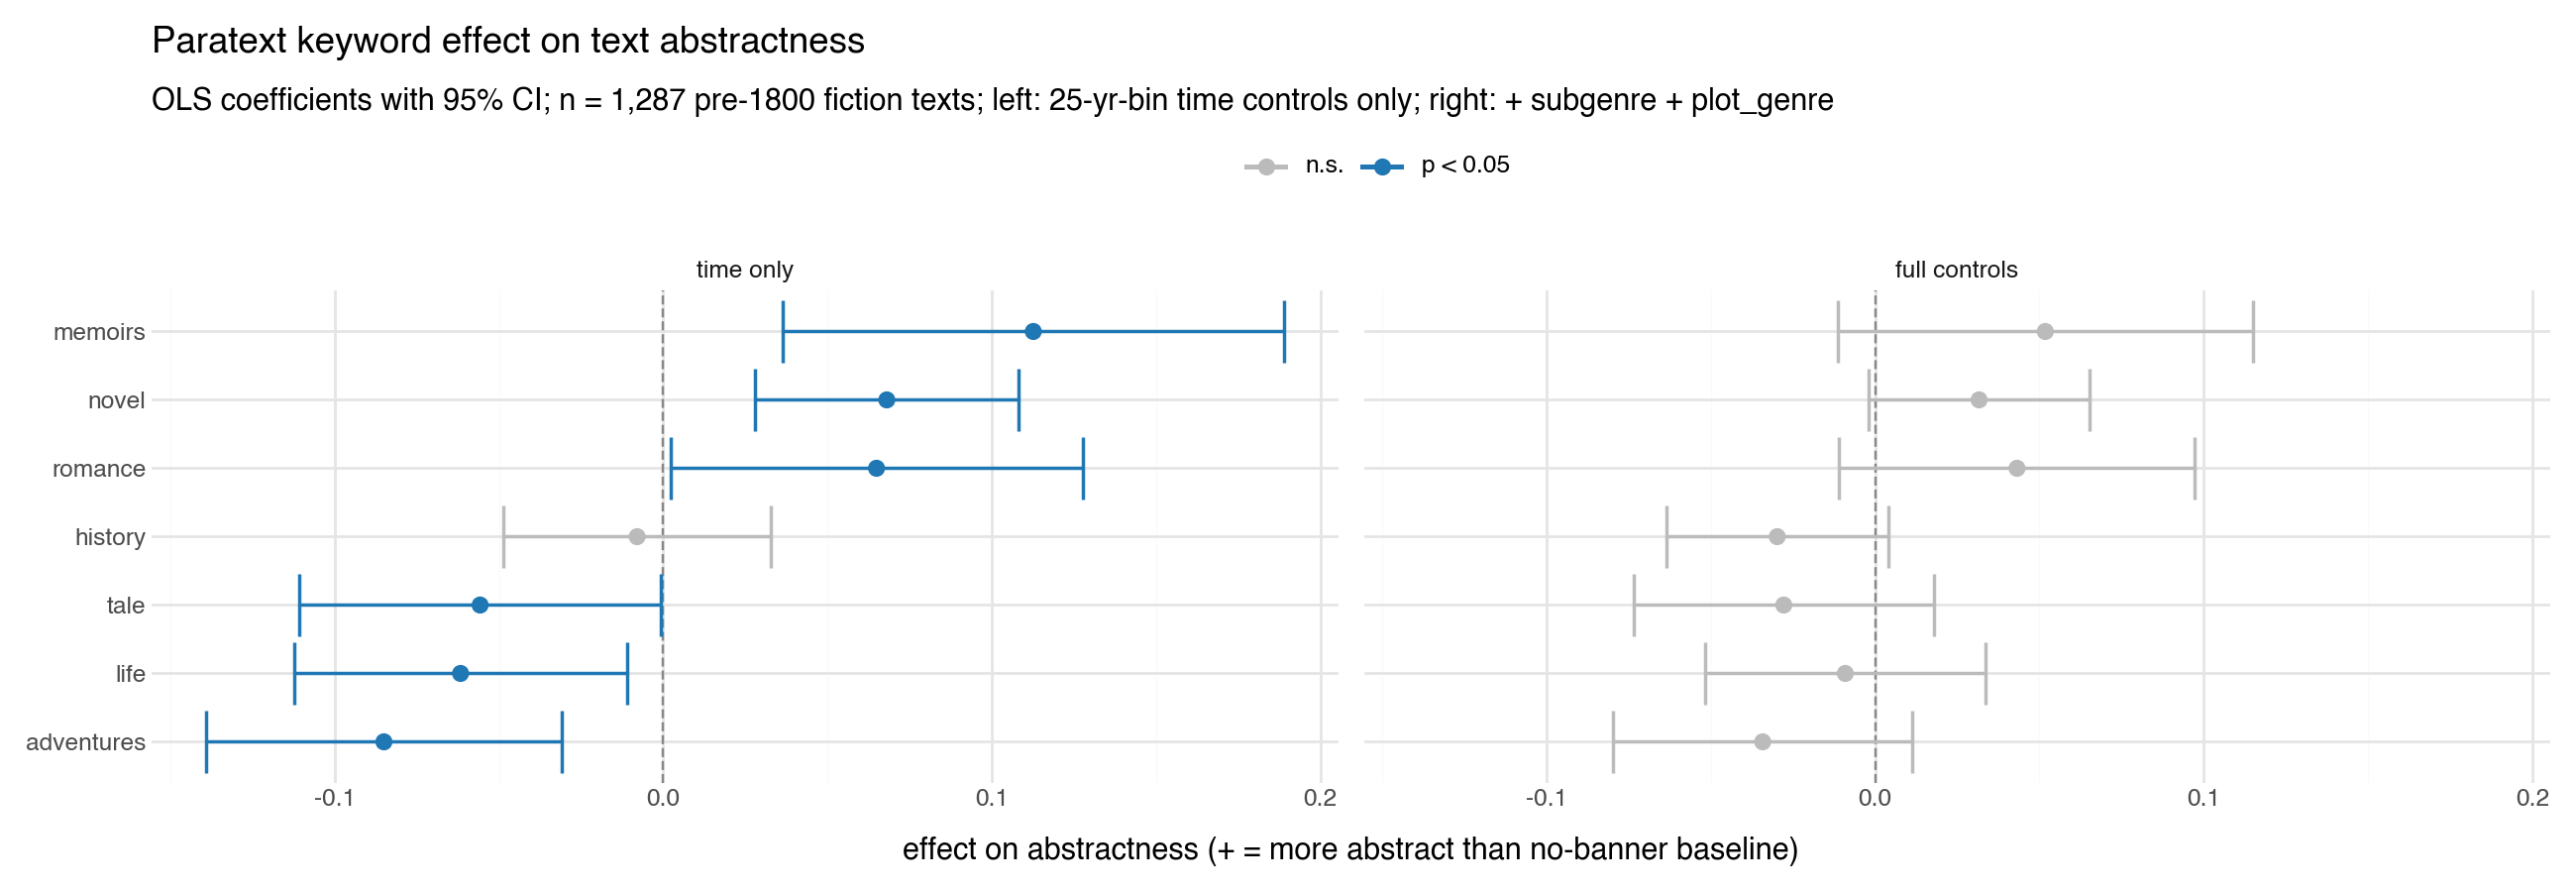

In [19]:
# Per-paratext coefficient plot. Two specs side by side: time-only vs full 4-way.
import statsmodels.api as sm

# Spec 1: time-bin + paratext
X1 = np.hstack([X_bin, X_para])
X1c = sm.add_constant(X1)
ols1 = sm.OLS(y_j, X1c).fit()
off1 = 1 + X_bin.shape[1]
rows1 = []
for i, col in enumerate(PARA_COLS):
    name = col.replace('pt_', '')
    rows1.append({'paratext': name, 'spec': 'time only',
                  'coef': ols1.params[off1+i], 'se': ols1.bse[off1+i],
                  'p': ols1.pvalues[off1+i]})

# Spec 2: full 4-way (refit since ols4 from §8 was a separate scope)
X2 = np.hstack([X_bin, X_sg_j, X_pg_j, X_para])
X2c = sm.add_constant(X2)
ols2 = sm.OLS(y_j, X2c).fit()
off2 = 1 + X_bin.shape[1] + X_sg_j.shape[1] + X_pg_j.shape[1]
rows2 = []
for i, col in enumerate(PARA_COLS):
    name = col.replace('pt_', '')
    rows2.append({'paratext': name, 'spec': 'full controls',
                  'coef': ols2.params[off2+i], 'se': ols2.bse[off2+i],
                  'p': ols2.pvalues[off2+i]})

coef_df = pd.DataFrame(rows1 + rows2)
coef_df['lo'] = coef_df['coef'] - 1.96 * coef_df['se']
coef_df['hi'] = coef_df['coef'] + 1.96 * coef_df['se']
coef_df['signif'] = coef_df['p'] < 0.05

# Order y-axis by time-only coef
order = (coef_df[coef_df['spec'] == 'time only']
         .sort_values('coef')['paratext'].tolist())
coef_df['paratext'] = pd.Categorical(coef_df['paratext'], categories=order, ordered=True)
coef_df['spec'] = pd.Categorical(coef_df['spec'],
                                 categories=['time only', 'full controls'], ordered=True)

print('Paratext coefficients (effect on abstractness vs no-banner baseline):')
print(coef_df[['paratext', 'spec', 'coef', 'se', 'p', 'signif']]
      .sort_values(['spec', 'coef']).to_string(index=False))

p_pcoef = (p9.ggplot(coef_df, p9.aes(x='coef', y='paratext', color='signif'))
           + p9.geom_vline(xintercept=0, linetype='dashed', color='#888888')
           + p9.geom_errorbarh(p9.aes(xmin='lo', xmax='hi'), height=0.0, size=0.7)
           + p9.geom_point(size=2.5)
           + p9.facet_wrap('~ spec', ncol=2)
           + p9.scale_color_manual(values={True: '#1f77b4', False: '#bbbbbb'},
                                   labels={True: 'p < 0.05', False: 'n.s.'})
           + p9.labs(
               title='Paratext keyword effect on text abstractness',
               subtitle=f'OLS coefficients with 95% CI; n = {len(joint):,} pre-1800 fiction texts; '
                        f'left: 25-yr-bin time controls only; right: + subgenre + plot_genre',
               x='effect on abstractness (+ = more abstract than no-banner baseline)',
               y='', color='',
           )
           + p9.theme_minimal()
           + p9.theme(figure_size=(13, 4.5), legend_position='top'))

out = os.path.join(DROPBOX_FIGS, 'subgenre_paratext_abstractness_coefficients.png')
p_pcoef.save(out, dpi=300, verbose=False)
print(f'\nSaved to {out}')
p_pcoef

### Century-exploded paratext: does "novel" mean something different in C17 vs C18?

Splits each paratext keyword into `keyword_C17` and `keyword_C18`. C16 dropped (n too small — most banners 0-5 hits before 1600), but C16/early texts still anchor the time-bin baseline.

Sample size note: paratext analysis only needs title + year + abstractness, so we use the full pre-1800 arc_fiction sample (n=1,306) for the raw-mean and time-only panels. The full-controls panel still uses the joint subgenre+plot_genre subsample (n=749).

Model: `abs ~ 25-yr-bin + paratext × century`. Coefficient = effect of carrying that banner in that century vs no-banner-in-same-period.

Full-sample n per (banner x century) cell:
  novel_C17          33
  novel_C18         136
  romance_C17        22
  romance_C18        33
  tale_C17            8
  tale_C18           82
  history_C17        89
  history_C18       151
  memoirs_C17         5
  memoirs_C18        65
  adventures_C17     34
  adventures_C18    102
  life_C17           45
  life_C18           89

Full-sample century baselines:
  C17: all=+0.399   no-banner=+0.382
  C18: all=+0.524   no-banner=+0.540



Paratext x century, full-sample mean + time-only + (joint) full-controls:
         label  n_mean abstractness  coef_mean abstractness  coef_time only (n=1,306)  p_time only (n=1,306)  coef_full controls (n=749)  p_full controls (n=749)
adventures_C18             102.0000                  0.4281                   -0.0969                 0.0001                      0.0213                   0.5784
      life_C17              45.0000                  0.3251                   -0.0802                 0.0197                      0.0029                   0.9273
   romance_C18              33.0000                  0.4587                   -0.0798                 0.0458                      0.0380                   0.4836
adventures_C17              34.0000                  0.3746                   -0.0707                 0.0746                     -0.0633                   0.0672
   history_C17              89.0000                  0.3532                   -0.0618                 0.0190       


Saved to /Users/rj416/Dropbox/Prof/Books/AbsLitHist/book/figures/subgenre_paratext_abstractness_century_coefficients.png


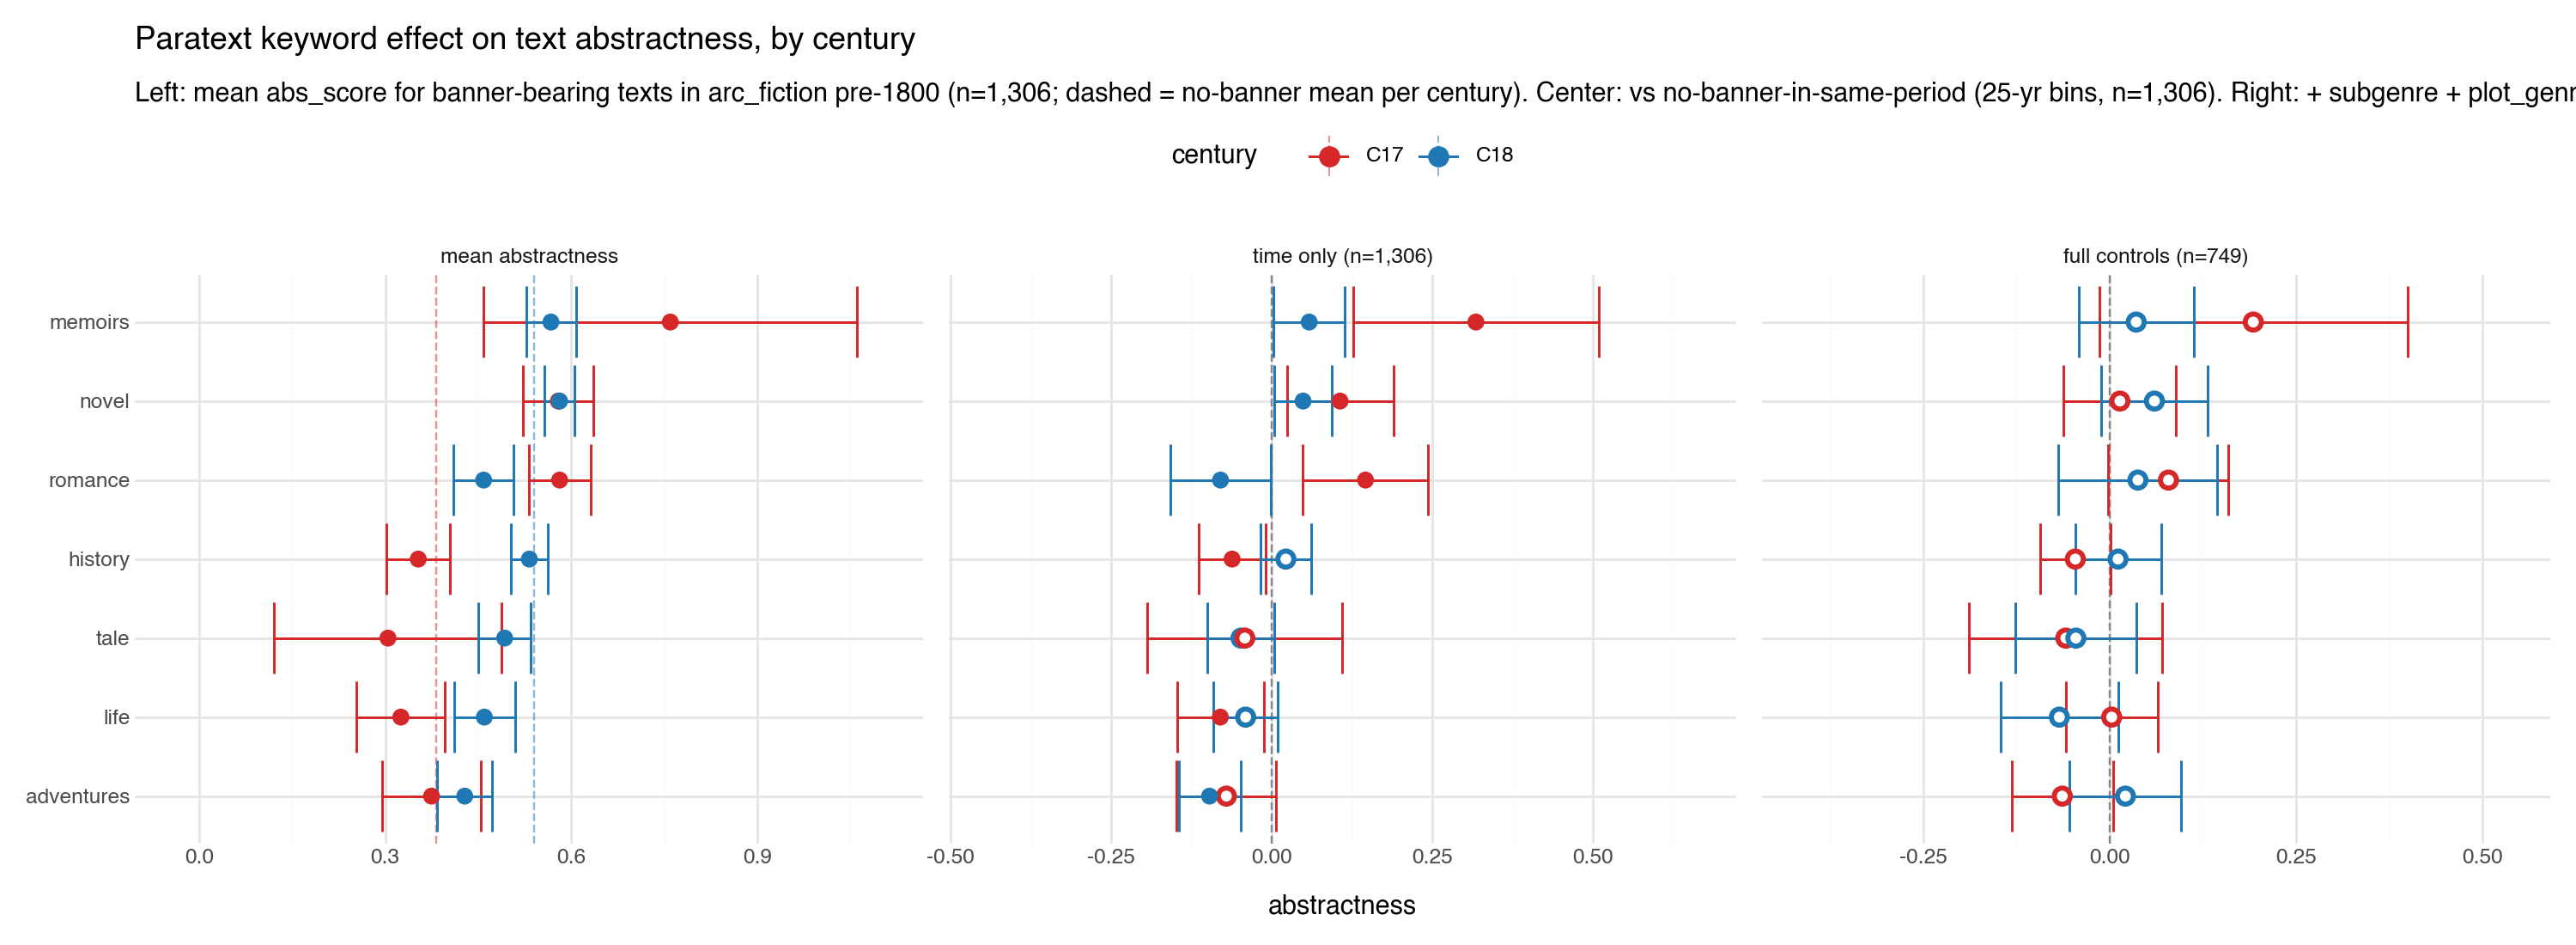

In [20]:
# Century-exploded paratext coefficients (using `arc` from setup cell + `joint` for full controls).

n_per_cell_full = arc[PT_X_CENT].sum().to_dict()
print('Full-sample n per (banner x century) cell:')
for c in PT_X_CENT:
    print(f'  {c:<16} {int(n_per_cell_full[c]):>4}')

# 25-yr time bins on full sample
bin_dum_full = pd.get_dummies(arc['bin'], prefix='bin').astype(float)
ref_bin_full = arc['bin'].value_counts().index[0]
bin_dum_full = bin_dum_full.drop(columns=[f'bin_{ref_bin_full}'])
X_bin_full = bin_dum_full.values
X_pt_full = arc[PT_X_CENT].values.astype(float)
y_full = arc['abs_score'].values

import statsmodels.api as sm
ols_full = sm.OLS(y_full, sm.add_constant(np.hstack([X_bin_full, X_pt_full]))).fit()
off_full = 1 + X_bin_full.shape[1]

# Raw mean abstractness per (banner, century) on full sample
has_any_full = arc[list(PARA_COLS)].sum(axis=1) > 0
mean_no_banner_full = {
    'C17': arc.loc[(arc['century']==1600) & ~has_any_full, 'abs_score'].mean(),
    'C18': arc.loc[(arc['century']==1700) & ~has_any_full, 'abs_score'].mean(),
}
mean_all_full = {
    'C17': arc.loc[arc['century']==1600, 'abs_score'].mean(),
    'C18': arc.loc[arc['century']==1700, 'abs_score'].mean(),
}
print(f'\nFull-sample century baselines:')
for c in ('C17', 'C18'):
    print(f'  {c}: all={mean_all_full[c]:+.3f}   no-banner={mean_no_banner_full[c]:+.3f}')

# Full-controls regression on joint subset (needs subgenre+plot_genre)
joint['century'] = (joint['year'] // 100 * 100).astype(int)
PT_X_CENT_JOINT = []
for col in PARA_COLS:
    name = col.replace('pt_', '')
    for cent in (1600, 1700):
        cname = f'{name}_C{cent//100+1}'
        joint[cname] = ((joint['century'] == cent) & joint[col].astype(bool)).astype(int)
        PT_X_CENT_JOINT.append(cname)
X_pt_c = joint[PT_X_CENT_JOINT].values.astype(float)
n_per_cell = joint[PT_X_CENT_JOINT].sum().to_dict()

ols_jc = sm.OLS(y_j, sm.add_constant(np.hstack([X_bin, X_sg_j, X_pg_j, X_pt_c]))).fit()
off_jc = 1 + X_bin.shape[1] + X_sg_j.shape[1] + X_pg_j.shape[1]

rows = []
for i, name in enumerate(PT_X_CENT):
    banner, cent = name.rsplit('_', 1)
    mask = arc[name].astype(bool)
    mean_raw = arc.loc[mask, 'abs_score'].mean() if mask.any() else float('nan')
    se_raw = arc.loc[mask, 'abs_score'].sem() if mask.sum() > 1 else float('nan')
    rows.append({
        'banner': banner, 'century': cent, 'label': name, 'spec': 'mean abstractness',
        'coef': mean_raw, 'se': se_raw,
        'lo': mean_raw - 1.96 * se_raw if pd.notna(se_raw) else float('nan'),
        'hi': mean_raw + 1.96 * se_raw if pd.notna(se_raw) else float('nan'),
        'p': float('nan'), 'signif': True, 'n': int(n_per_cell_full[name]),
    })
    rows.append({
        'banner': banner, 'century': cent, 'label': name, 'spec': 'time only (n=1,306)',
        'coef': ols_full.params[off_full+i], 'se': ols_full.bse[off_full+i],
        'p': ols_full.pvalues[off_full+i], 'n': int(n_per_cell_full[name]),
        'lo': ols_full.params[off_full+i] - 1.96 * ols_full.bse[off_full+i],
        'hi': ols_full.params[off_full+i] + 1.96 * ols_full.bse[off_full+i],
        'signif': ols_full.pvalues[off_full+i] < 0.05,
    })
    rows.append({
        'banner': banner, 'century': cent, 'label': name, 'spec': 'full controls (n=749)',
        'coef': ols_jc.params[off_jc+i], 'se': ols_jc.bse[off_jc+i],
        'p': ols_jc.pvalues[off_jc+i], 'n': int(n_per_cell[name]),
        'lo': ols_jc.params[off_jc+i] - 1.96 * ols_jc.bse[off_jc+i],
        'hi': ols_jc.params[off_jc+i] + 1.96 * ols_jc.bse[off_jc+i],
        'signif': ols_jc.pvalues[off_jc+i] < 0.05,
    })
plot_df = pd.DataFrame(rows)

banner_order = (plot_df[plot_df['spec'].astype(str).str.startswith('time only')]
                .groupby('banner')['coef'].mean().sort_values().index.tolist())
plot_df['banner'] = pd.Categorical(plot_df['banner'], categories=banner_order, ordered=True)
plot_df['century'] = pd.Categorical(plot_df['century'], categories=['C17','C18'], ordered=True)
spec_order = ['mean abstractness', 'time only (n=1,306)', 'full controls (n=749)']
plot_df['spec'] = pd.Categorical(plot_df['spec'], categories=spec_order, ordered=True)

print('\nParatext x century, full-sample mean + time-only + (joint) full-controls:')
piv = plot_df.pivot_table(index=['banner','century','label'],
                          columns='spec', values=['coef','p','n'])
piv.columns = ['_'.join([str(x) for x in c]).strip('_') for c in piv.columns]
piv = piv.reset_index().sort_values('coef_time only (n=1,306)')
disp_cols = ['label', 'n_mean abstractness', 'coef_mean abstractness',
             'coef_time only (n=1,306)', 'p_time only (n=1,306)',
             'coef_full controls (n=749)', 'p_full controls (n=749)']
print(piv[disp_cols].to_string(index=False, float_format='%.4f'))

ref_lines = pd.DataFrame([
    {'spec': 'mean abstractness', 'century': 'C17', 'xref': mean_no_banner_full['C17']},
    {'spec': 'mean abstractness', 'century': 'C18', 'xref': mean_no_banner_full['C18']},
])
ref_lines['spec'] = pd.Categorical(ref_lines['spec'], categories=spec_order, ordered=True)
ref_lines['century'] = pd.Categorical(ref_lines['century'], categories=['C17','C18'], ordered=True)
zero_lines = pd.DataFrame([
    {'spec': spec_order[1], 'xref': 0.0},
    {'spec': spec_order[2], 'xref': 0.0},
])
zero_lines['spec'] = pd.Categorical(zero_lines['spec'], categories=spec_order, ordered=True)

mean_pts = plot_df[plot_df['spec'] == 'mean abstractness']
sig_pts = plot_df[plot_df['signif'] & (plot_df['spec'] != 'mean abstractness')]
nsig_pts = plot_df[(~plot_df['signif']) & (plot_df['spec'] != 'mean abstractness')]

p_pcc = (p9.ggplot(plot_df, p9.aes(x='coef', y='banner', color='century'))
         + p9.geom_vline(p9.aes(xintercept='xref'), data=zero_lines,
                         linetype='dashed', color='#888888', inherit_aes=False)
         + p9.geom_vline(p9.aes(xintercept='xref', color='century'),
                         data=ref_lines, linetype='dashed', alpha=0.5, inherit_aes=False)
         + p9.geom_errorbarh(p9.aes(xmin='lo', xmax='hi'),
                             height=0.0, size=0.6,
                             position=p9.position_dodge(width=0.7))
         + p9.geom_point(data=mean_pts, size=3.0,
                         position=p9.position_dodge(width=0.7))
         + p9.geom_point(data=nsig_pts, size=2.6, fill='white', stroke=1.2,
                         position=p9.position_dodge(width=0.7))
         + p9.geom_point(data=sig_pts, size=3.0,
                         position=p9.position_dodge(width=0.7))
         + p9.facet_wrap('~ spec', ncol=3, scales='free_x')
         + p9.scale_color_manual(values={'C17': '#d62728', 'C18': '#1f77b4'})
         + p9.labs(
             title='Paratext keyword effect on text abstractness, by century',
             subtitle=f'Left: mean abs_score for banner-bearing texts in arc_fiction pre-1800 (n=1,306; '
                      f'dashed = no-banner mean per century). '
                      f'Center: vs no-banner-in-same-period (25-yr bins, n=1,306). '
                      f'Right: + subgenre + plot_genre (n=749, joint sample). Filled = p<0.05.',
             x='abstractness', y='', color='century',
         )
         + p9.theme_minimal()
         + p9.theme(figure_size=(15, 5.5), legend_position='top'))

out = os.path.join(DROPBOX_FIGS, 'subgenre_paratext_abstractness_century_coefficients.png')
p_pcc.save(out, dpi=300, verbose=False)
print(f'\nSaved to {out}')
p_pcc

## 9. Subgenre stability across C17→C18

Test the stronger thesis: the novel-banner is stable across centuries (mean ~0.58 in both) — does the same hold for the *subgenres* in the Watt canon (amatory_fiction, epistolary, domestic_fiction, pseudo_memoir, sentimental)?

If amatory/epistolary/domestic are stably abstract C17→C18 while pseudo_memoir/picaresque are stably concrete, then the secular abstractness rise we see in the corpus is mostly **compositional shift** (more abstract subgenres dominating in C18) rather than each subgenre concretizing or abstracting individually.

Plot: mean abstractness per (subgenre × century) with 95% CI, alongside the period no-banner baseline. Stable subgenres = horizontal lines; subgenres that drift = sloped.

Subgenres with >=8 texts in BOTH C17 and C18: 19

Subgenre abstractness, C17 vs C18 (sorted by Δ):
century               C17    C18  delta
subgenre                               
roman_a_clef        0.582  0.460 -0.122
secret_history      0.694  0.662 -0.032
epistolary          0.646  0.640 -0.005
historical_fiction  0.514  0.515  0.001
allegory            0.351  0.353  0.003
amatory_fiction     0.575  0.627  0.052
travel_narrative    0.284  0.349  0.065
conduct_fiction     0.558  0.623  0.065
sentimental         0.492  0.567  0.075
domestic_fiction    0.505  0.601  0.095
scandalous_memoir   0.493  0.594  0.101
pseudo_memoir       0.314  0.429  0.115
frame_tale          0.398  0.514  0.115
heroic_romance      0.498  0.614  0.116
philosophical_tale  0.395  0.543  0.149
picaresque          0.210  0.430  0.220
parody              0.187  0.413  0.226
menippean_satire    0.216  0.446  0.229
anti_romance        0.197  0.529  0.331

Period baseline shift: 0.382 (C17) -> 0.540 (C18) = +0.157
S


Saved to /Users/rj416/Dropbox/Prof/Books/AbsLitHist/book/figures/subgenre_abstractness_century.png


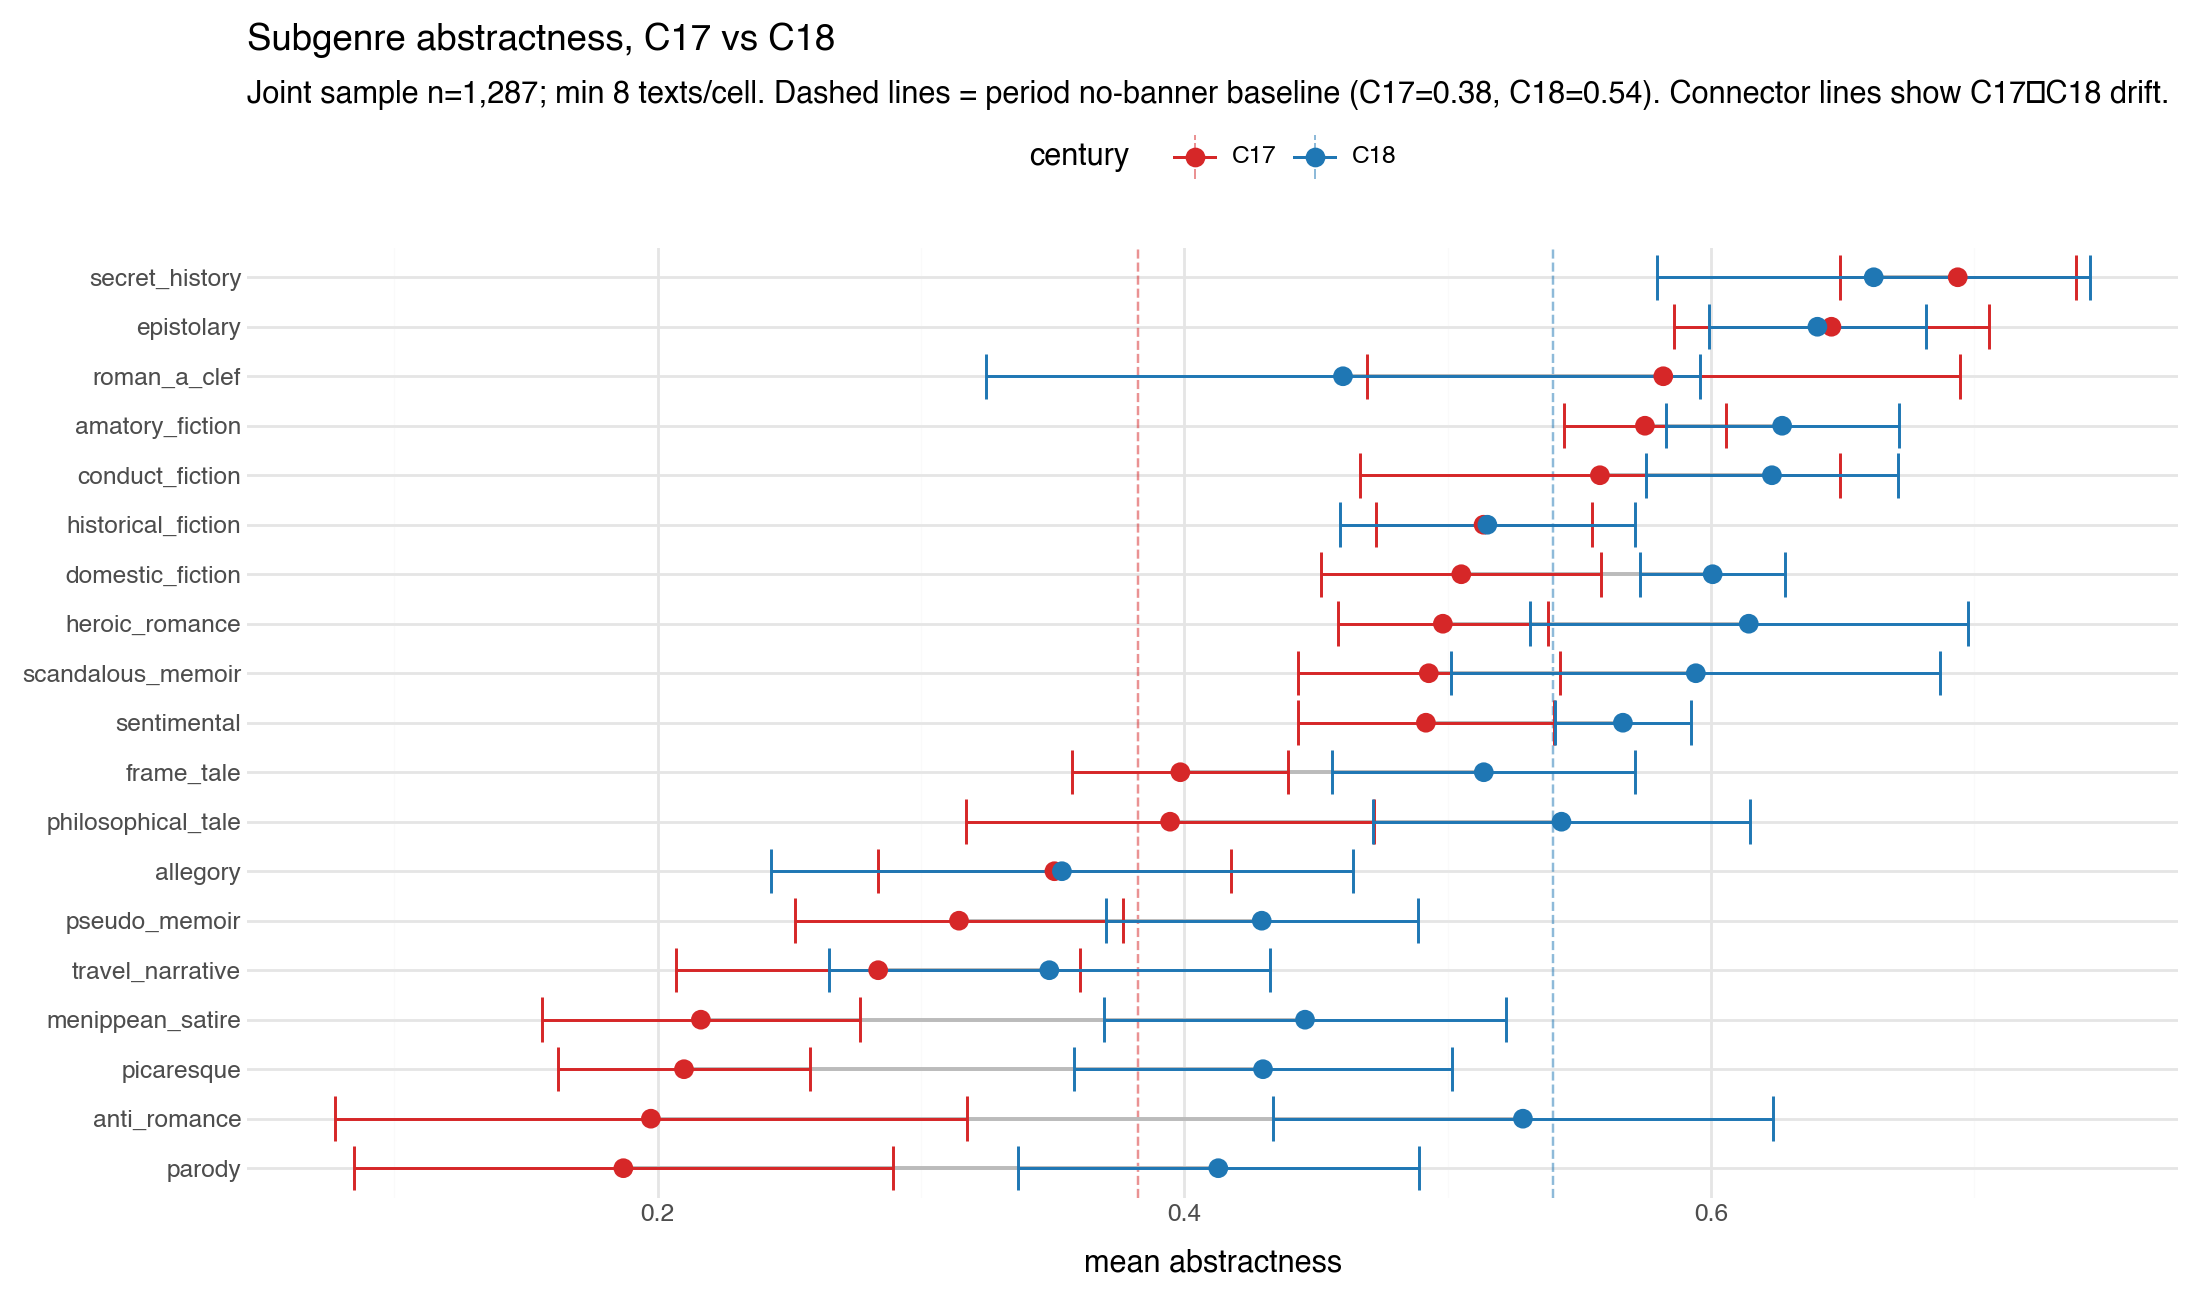

In [21]:
# Subgenre stability across C17 vs C18.
# Use joint sample (n=749 pre-1800) since we need subgenre annotations.
# Filter to subgenres with at least 8 texts in BOTH centuries.
MIN_PER_CELL = 8

rows = []
for tag in [t for t, _ in sg_counter.most_common()]:
    has = joint['subgenres'].apply(lambda L: tag in L)
    for cent_label, cent_year in [('C17', 1600), ('C18', 1700)]:
        mask = has & (joint['century'] == cent_year)
        if mask.sum() >= MIN_PER_CELL:
            rows.append({
                'subgenre': tag, 'century': cent_label,
                'n': int(mask.sum()),
                'mean_abs': joint.loc[mask, 'abs_score'].mean(),
                'se': joint.loc[mask, 'abs_score'].sem(),
            })
sgcent = pd.DataFrame(rows)

# Keep only subgenres that survived in BOTH centuries
tag_centuries = sgcent.groupby('subgenre')['century'].nunique()
stable_tags = tag_centuries[tag_centuries == 2].index.tolist()
sgcent = sgcent[sgcent['subgenre'].isin(stable_tags)].copy()
sgcent['lo'] = sgcent['mean_abs'] - 1.96 * sgcent['se']
sgcent['hi'] = sgcent['mean_abs'] + 1.96 * sgcent['se']

# Compute C17→C18 delta to sort
delta = (sgcent.pivot(index='subgenre', columns='century', values='mean_abs')
         .assign(delta=lambda d: d['C18'] - d['C17']))
delta = delta.sort_values('delta')
print(f'Subgenres with >={MIN_PER_CELL} texts in BOTH C17 and C18: {len(stable_tags)}')
print('\nSubgenre abstractness, C17 vs C18 (sorted by Δ):')
print(delta.round(3).to_string())

# Period baselines (full arc_fiction, no-banner reference)
baseline_C17 = mean_no_banner_full['C17']
baseline_C18 = mean_no_banner_full['C18']
delta_baseline = baseline_C18 - baseline_C17
print(f'\nPeriod baseline shift: {baseline_C17:.3f} (C17) -> {baseline_C18:.3f} (C18) = +{delta_baseline:.3f}')
stable_count = (delta['delta'].abs() < delta_baseline).sum()
print(f'Subgenres with |Δ| < baseline shift (= "stable"): {stable_count} / {len(delta)}')

# Order subgenres on y-axis by C17 mean abs (concrete -> abstract)
sg_order = sgcent[sgcent['century']=='C17'].sort_values('mean_abs')['subgenre'].tolist()
sgcent['subgenre'] = pd.Categorical(sgcent['subgenre'], categories=sg_order, ordered=True)
sgcent['century'] = pd.Categorical(sgcent['century'], categories=['C17','C18'], ordered=True)

# Reference lines: period baseline per century
ref_lines = pd.DataFrame([
    {'century': 'C17', 'xref': baseline_C17},
    {'century': 'C18', 'xref': baseline_C18},
])
ref_lines['century'] = pd.Categorical(ref_lines['century'], categories=['C17','C18'], ordered=True)

# Build connector segments between C17 and C18 points for each subgenre
wide = sgcent.pivot(index='subgenre', columns='century', values='mean_abs').reset_index()
wide['subgenre'] = pd.Categorical(wide['subgenre'], categories=sg_order, ordered=True)

p_sg = (p9.ggplot(sgcent, p9.aes(x='mean_abs', y='subgenre', color='century'))
        + p9.geom_vline(p9.aes(xintercept='xref', color='century'),
                        data=ref_lines, linetype='dashed', alpha=0.5, inherit_aes=False)
        + p9.geom_segment(p9.aes(x='C17', xend='C18', y='subgenre', yend='subgenre'),
                          data=wide, color='#bbbbbb', size=0.8, inherit_aes=False)
        + p9.geom_errorbarh(p9.aes(xmin='lo', xmax='hi'), height=0.0, size=0.6)
        + p9.geom_point(size=3.0)
        + p9.scale_color_manual(values={'C17': '#d62728', 'C18': '#1f77b4'})
        + p9.labs(
            title='Subgenre abstractness, C17 vs C18',
            subtitle=f'Joint sample n={len(joint):,}; min {MIN_PER_CELL} texts/cell. '
                     f'Dashed lines = period no-banner baseline (C17={baseline_C17:.2f}, C18={baseline_C18:.2f}). '
                     f'Connector lines show C17→C18 drift.',
            x='mean abstractness', y='', color='century',
        )
        + p9.theme_minimal()
        + p9.theme(figure_size=(11, 6.5), legend_position='top'))

out = os.path.join(DROPBOX_FIGS, 'subgenre_abstractness_century.png')
p_sg.save(out, dpi=300, verbose=False)
print(f'\nSaved to {out}')
p_sg

### 9b. Subgenre + paratext-banner side by side

Mean abstractness per category × century, with both subgenres (LLM-extracted form) and paratext banners (title self-positioning) on the same axis. Tells us whether the paratext banners line up with the subgenre signal or pull it differently — and whether the same C17→C18 stability pattern shows up in both layers.

Sample note: subgenres on joint (n=749), paratext on full pre-1800 arc_fiction (n=1,306). The visual lines up because both axes share the same scoring.

Saved to /Users/rj416/Dropbox/Prof/Books/AbsLitHist/book/figures/subgenre_paratext_century_combined.png

Combined C17 vs C18 ranking (sorted by C17 mean):
    kind           category   C17   C18  delta
subgenre             parody 0.187 0.413  0.226
subgenre       anti_romance 0.197 0.529  0.331
subgenre         picaresque 0.210 0.430  0.220
subgenre   menippean_satire 0.216 0.446  0.229
subgenre   travel_narrative 0.284 0.349  0.065
paratext               tale 0.304 0.493  0.188
subgenre      pseudo_memoir 0.314 0.429  0.115
paratext               life 0.325 0.460  0.135
subgenre           allegory 0.351 0.353  0.003
paratext            history 0.353 0.532  0.179
paratext         adventures 0.375 0.428  0.054
subgenre philosophical_tale 0.395 0.543  0.149
subgenre         frame_tale 0.398 0.514  0.115
subgenre        sentimental 0.492 0.567  0.075
subgenre  scandalous_memoir 0.493 0.594  0.101
subgenre     heroic_romance 0.498 0.614  0.116
subgenre   domestic_fiction 0.505 0.601  0.095

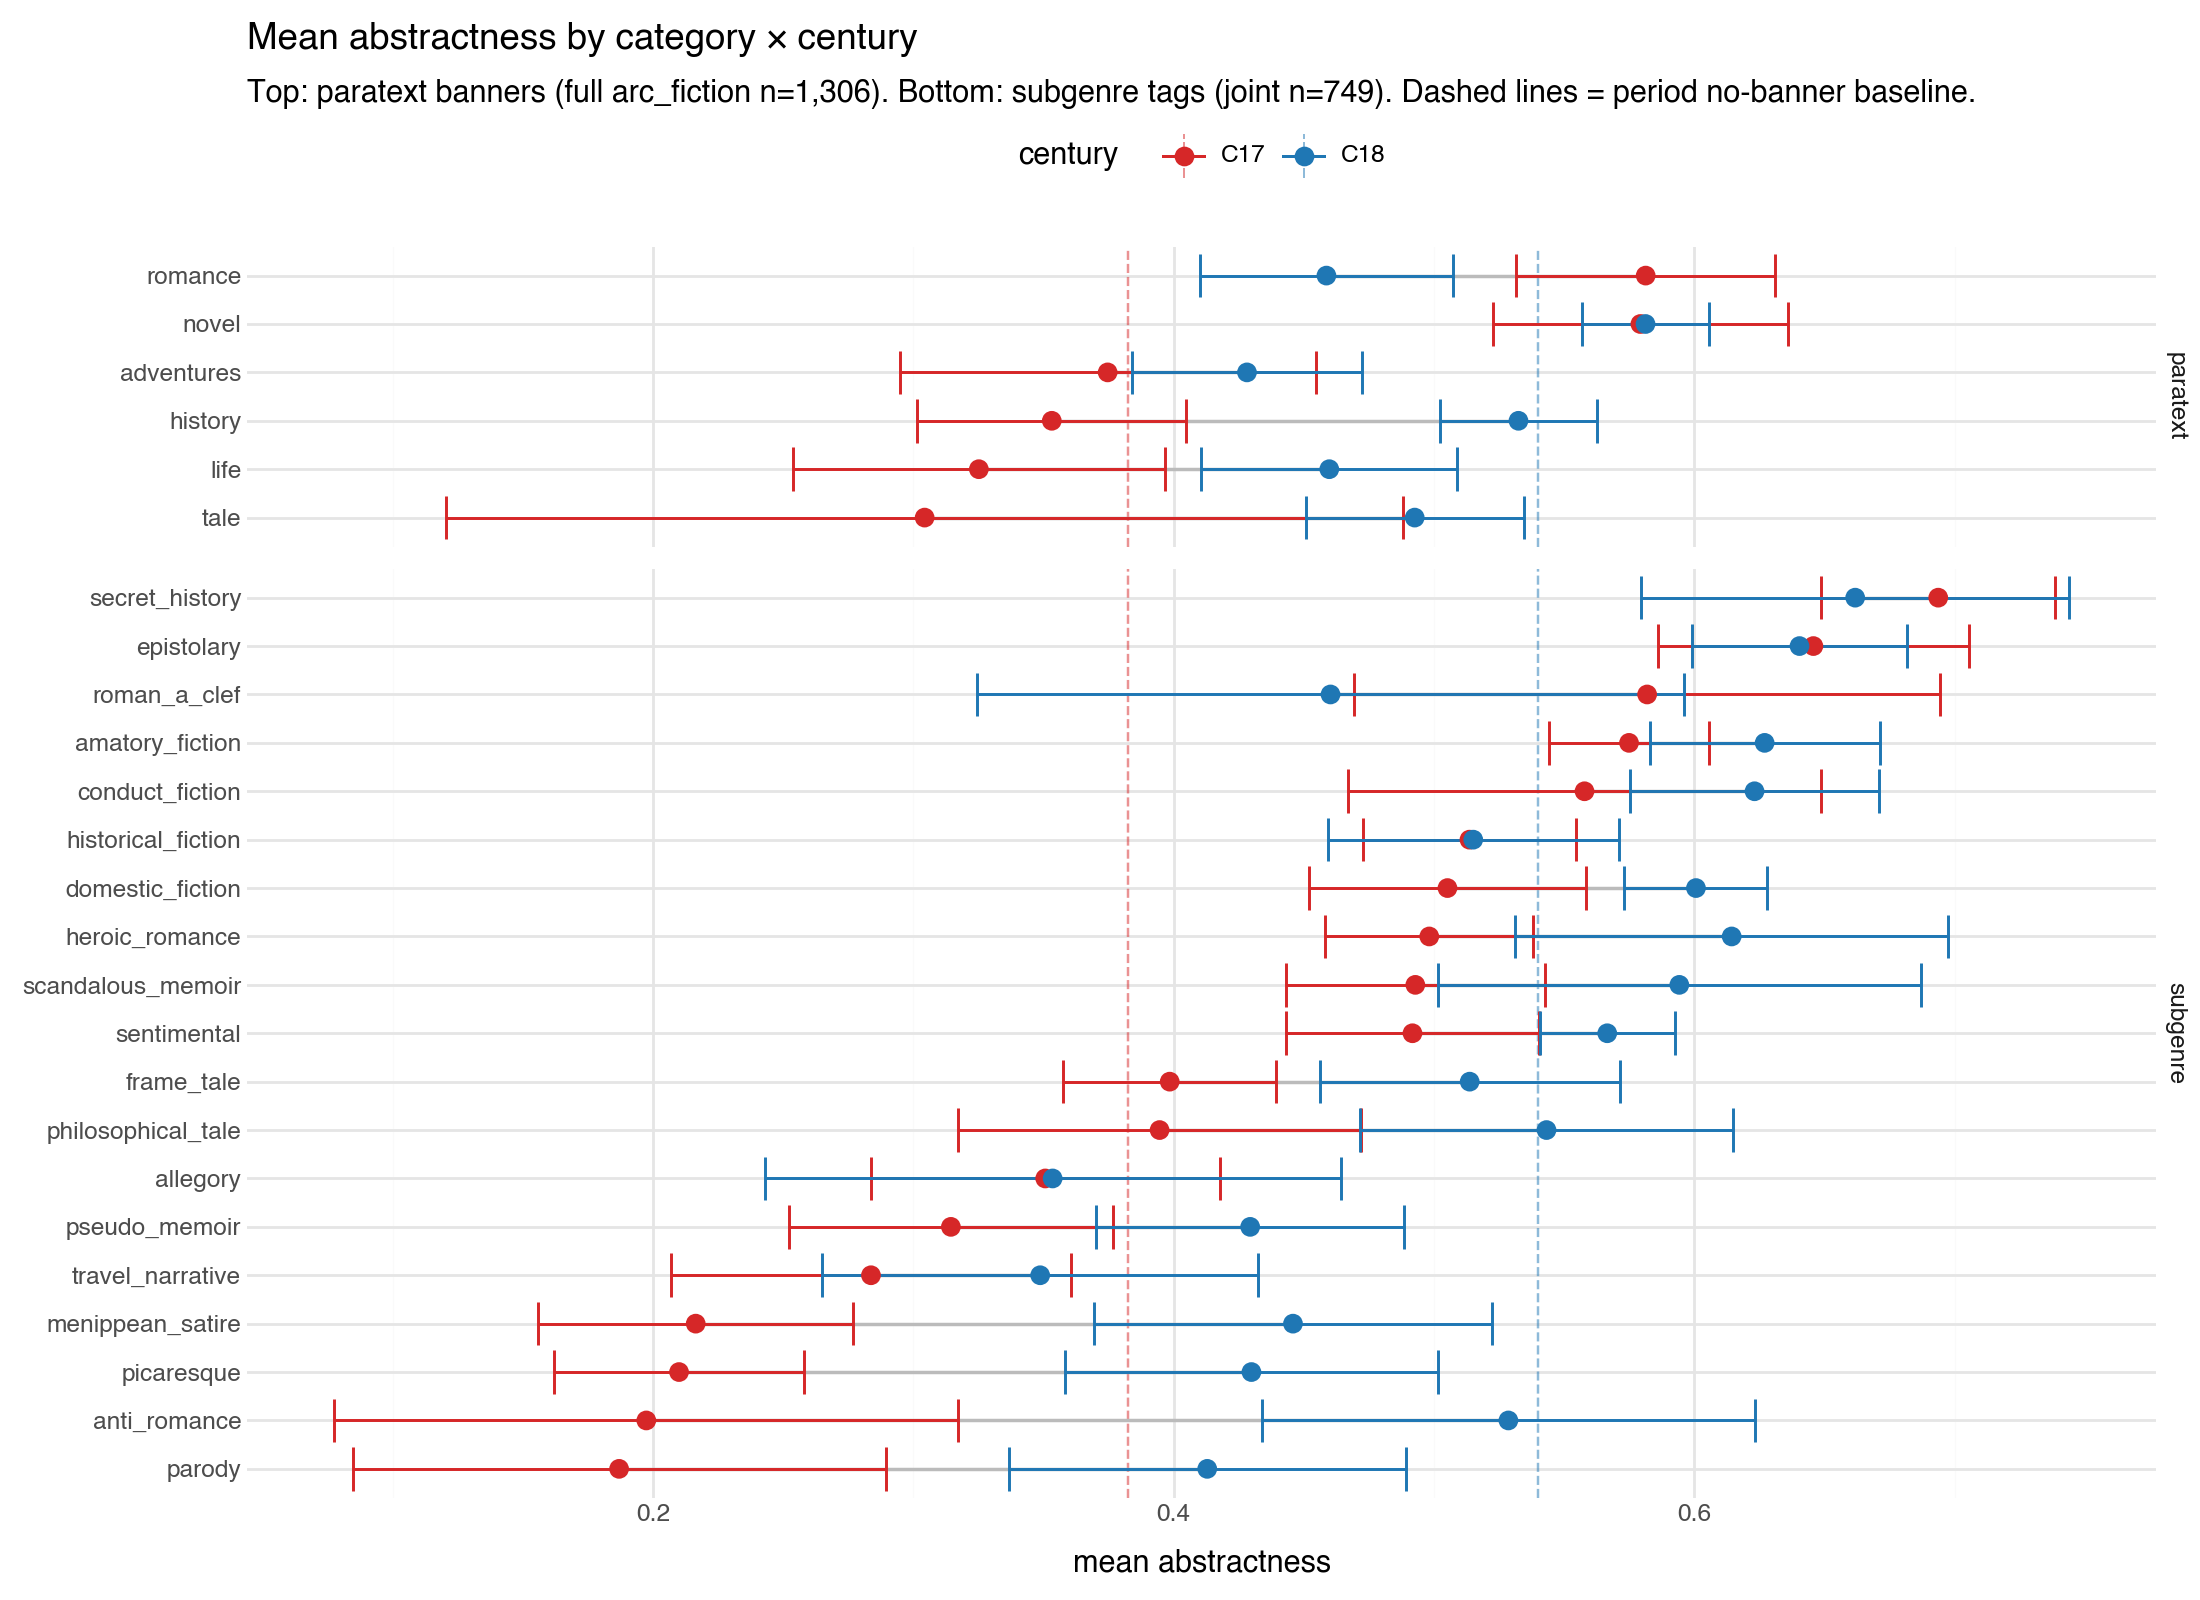

In [22]:
# Side-by-side: subgenre × century (joint) and paratext × century (full arc).
# Reuse sgcent (from §9). Build a comparable DataFrame for paratext.
MIN = 8

pt_rows = []
for col in PARA_COLS:
    name = col.replace('pt_', '')
    for cent_label, cent_year in [('C17', 1600), ('C18', 1700)]:
        mask = (arc[col].astype(bool)) & (arc['century'] == cent_year)
        if mask.sum() >= MIN:
            pt_rows.append({
                'category': name, 'kind': 'paratext', 'century': cent_label,
                'n': int(mask.sum()),
                'mean_abs': arc.loc[mask, 'abs_score'].mean(),
                'se': arc.loc[mask, 'abs_score'].sem(),
            })
ptcent = pd.DataFrame(pt_rows)

# Subgenre rows from §9
sg_part = sgcent[['subgenre', 'century', 'n', 'mean_abs', 'se']].rename(
    columns={'subgenre': 'category'}).copy()
sg_part['kind'] = 'subgenre'

combo = pd.concat([sg_part, ptcent], ignore_index=True)
combo['lo'] = combo['mean_abs'] - 1.96 * combo['se']
combo['hi'] = combo['mean_abs'] + 1.96 * combo['se']

# Keep only categories with both centuries
kept = combo.groupby(['category','kind'])['century'].nunique()
kept = kept[kept == 2].index
combo = combo.merge(pd.DataFrame(kept.tolist(), columns=['category','kind']),
                    on=['category','kind'], how='inner')

# Order y-axis by C17 mean (concrete -> abstract), grouped by kind for the facet
y_order = (combo[combo['century']=='C17']
           .sort_values(['kind','mean_abs'])
           [['kind','category']].drop_duplicates())
subg_order = y_order[y_order['kind']=='subgenre']['category'].tolist()
para_order = y_order[y_order['kind']=='paratext']['category'].tolist()
all_order = subg_order + para_order
combo['category'] = pd.Categorical(combo['category'], categories=all_order, ordered=True)
combo['century'] = pd.Categorical(combo['century'], categories=['C17','C18'], ordered=True)
combo['kind'] = pd.Categorical(combo['kind'], categories=['paratext','subgenre'], ordered=True)

# Connector segments per category
wide = combo.pivot_table(index=['kind','category'], columns='century',
                         values='mean_abs').reset_index()
wide['category'] = pd.Categorical(wide['category'], categories=all_order, ordered=True)
wide['kind'] = pd.Categorical(wide['kind'], categories=['paratext','subgenre'], ordered=True)

# Reference baselines
ref_lines = pd.DataFrame([
    {'century': 'C17', 'xref': mean_no_banner_full['C17']},
    {'century': 'C18', 'xref': mean_no_banner_full['C18']},
])
ref_lines['century'] = pd.Categorical(ref_lines['century'], categories=['C17','C18'], ordered=True)

p_combo = (p9.ggplot(combo, p9.aes(x='mean_abs', y='category', color='century'))
           + p9.geom_vline(p9.aes(xintercept='xref', color='century'),
                           data=ref_lines, linetype='dashed', alpha=0.5, inherit_aes=False)
           + p9.geom_segment(p9.aes(x='C17', xend='C18', y='category', yend='category'),
                             data=wide, color='#bbbbbb', size=0.7, inherit_aes=False)
           + p9.geom_errorbarh(p9.aes(xmin='lo', xmax='hi'), height=0.0, size=0.6)
           + p9.geom_point(size=3.0)
           + p9.facet_grid('kind ~ .', scales='free_y', space='free_y')
           + p9.scale_color_manual(values={'C17': '#d62728', 'C18': '#1f77b4'})
           + p9.labs(
               title='Mean abstractness by category × century',
               subtitle=f'Top: paratext banners (full arc_fiction n=1,306). '
                        f'Bottom: subgenre tags (joint n=749). '
                        f'Dashed lines = period no-banner baseline.',
               x='mean abstractness', y='', color='century',
           )
           + p9.theme_minimal()
           + p9.theme(figure_size=(11, 8), legend_position='top'))

out = os.path.join(DROPBOX_FIGS, 'subgenre_paratext_century_combined.png')
p_combo.save(out, dpi=300, verbose=False)
print(f'Saved to {out}')

# Print combined ranking by C17 abstractness
print('\nCombined C17 vs C18 ranking (sorted by C17 mean):')
tbl = wide.sort_values('C17')
tbl['delta'] = tbl['C18'] - tbl['C17']
print(tbl[['kind','category','C17','C18','delta']].round(3).to_string(index=False))

p_combo

### 9c. Pairwise subgenre × paratext × century

One row per (subgenre × paratext-banner) combination, e.g. `amatory_fiction × novel`, `pseudo_memoir × adventures`. Tells us whether the banner adds information *within* a subgenre — i.e. is `amatory_fiction × novel` more abstract than `amatory_fiction × no-banner`?

Filter: top-12 subgenres × 7 paratext banners + no-banner; keep combinations with n≥5 in each century. Multi-label texts contribute to multiple cells.

Pairs with n>=5 in BOTH centuries: 33


Saved to /Users/rj416/Dropbox/Prof/Books/AbsLitHist/book/figures/subgenre_paratext_pair_century.png

Top 15 pairs by C17 mean abs (most abstract):
                           pair   C17   C18  delta
   historical_fiction × romance 0.633 0.574 -0.058
        amatory_fiction × novel 0.605 0.666  0.061
      amatory_fiction × history 0.584 0.698  0.114
   domestic_fiction × no_banner 0.574 0.596  0.022
    amatory_fiction × no_banner 0.572 0.598  0.026
          sentimental × romance 0.558 0.506 -0.052
       domestic_fiction × novel 0.554 0.636  0.082
        sentimental × no_banner 0.529 0.565  0.036
 historical_fiction × no_banner 0.525 0.468 -0.057
historical_fiction × adventures 0.519 0.414 -0.105
       sentimental × adventures 0.506 0.467 -0.038
             frame_tale × novel 0.500 0.618  0.118
             sentimental × life 0.472 0.447 -0.025
  domestic_fiction × adventures 0.471 0.570  0.099
           frame_tale × history 0.452 0.441 -0.010

Top 15 pairs by C17 mean abs (most c

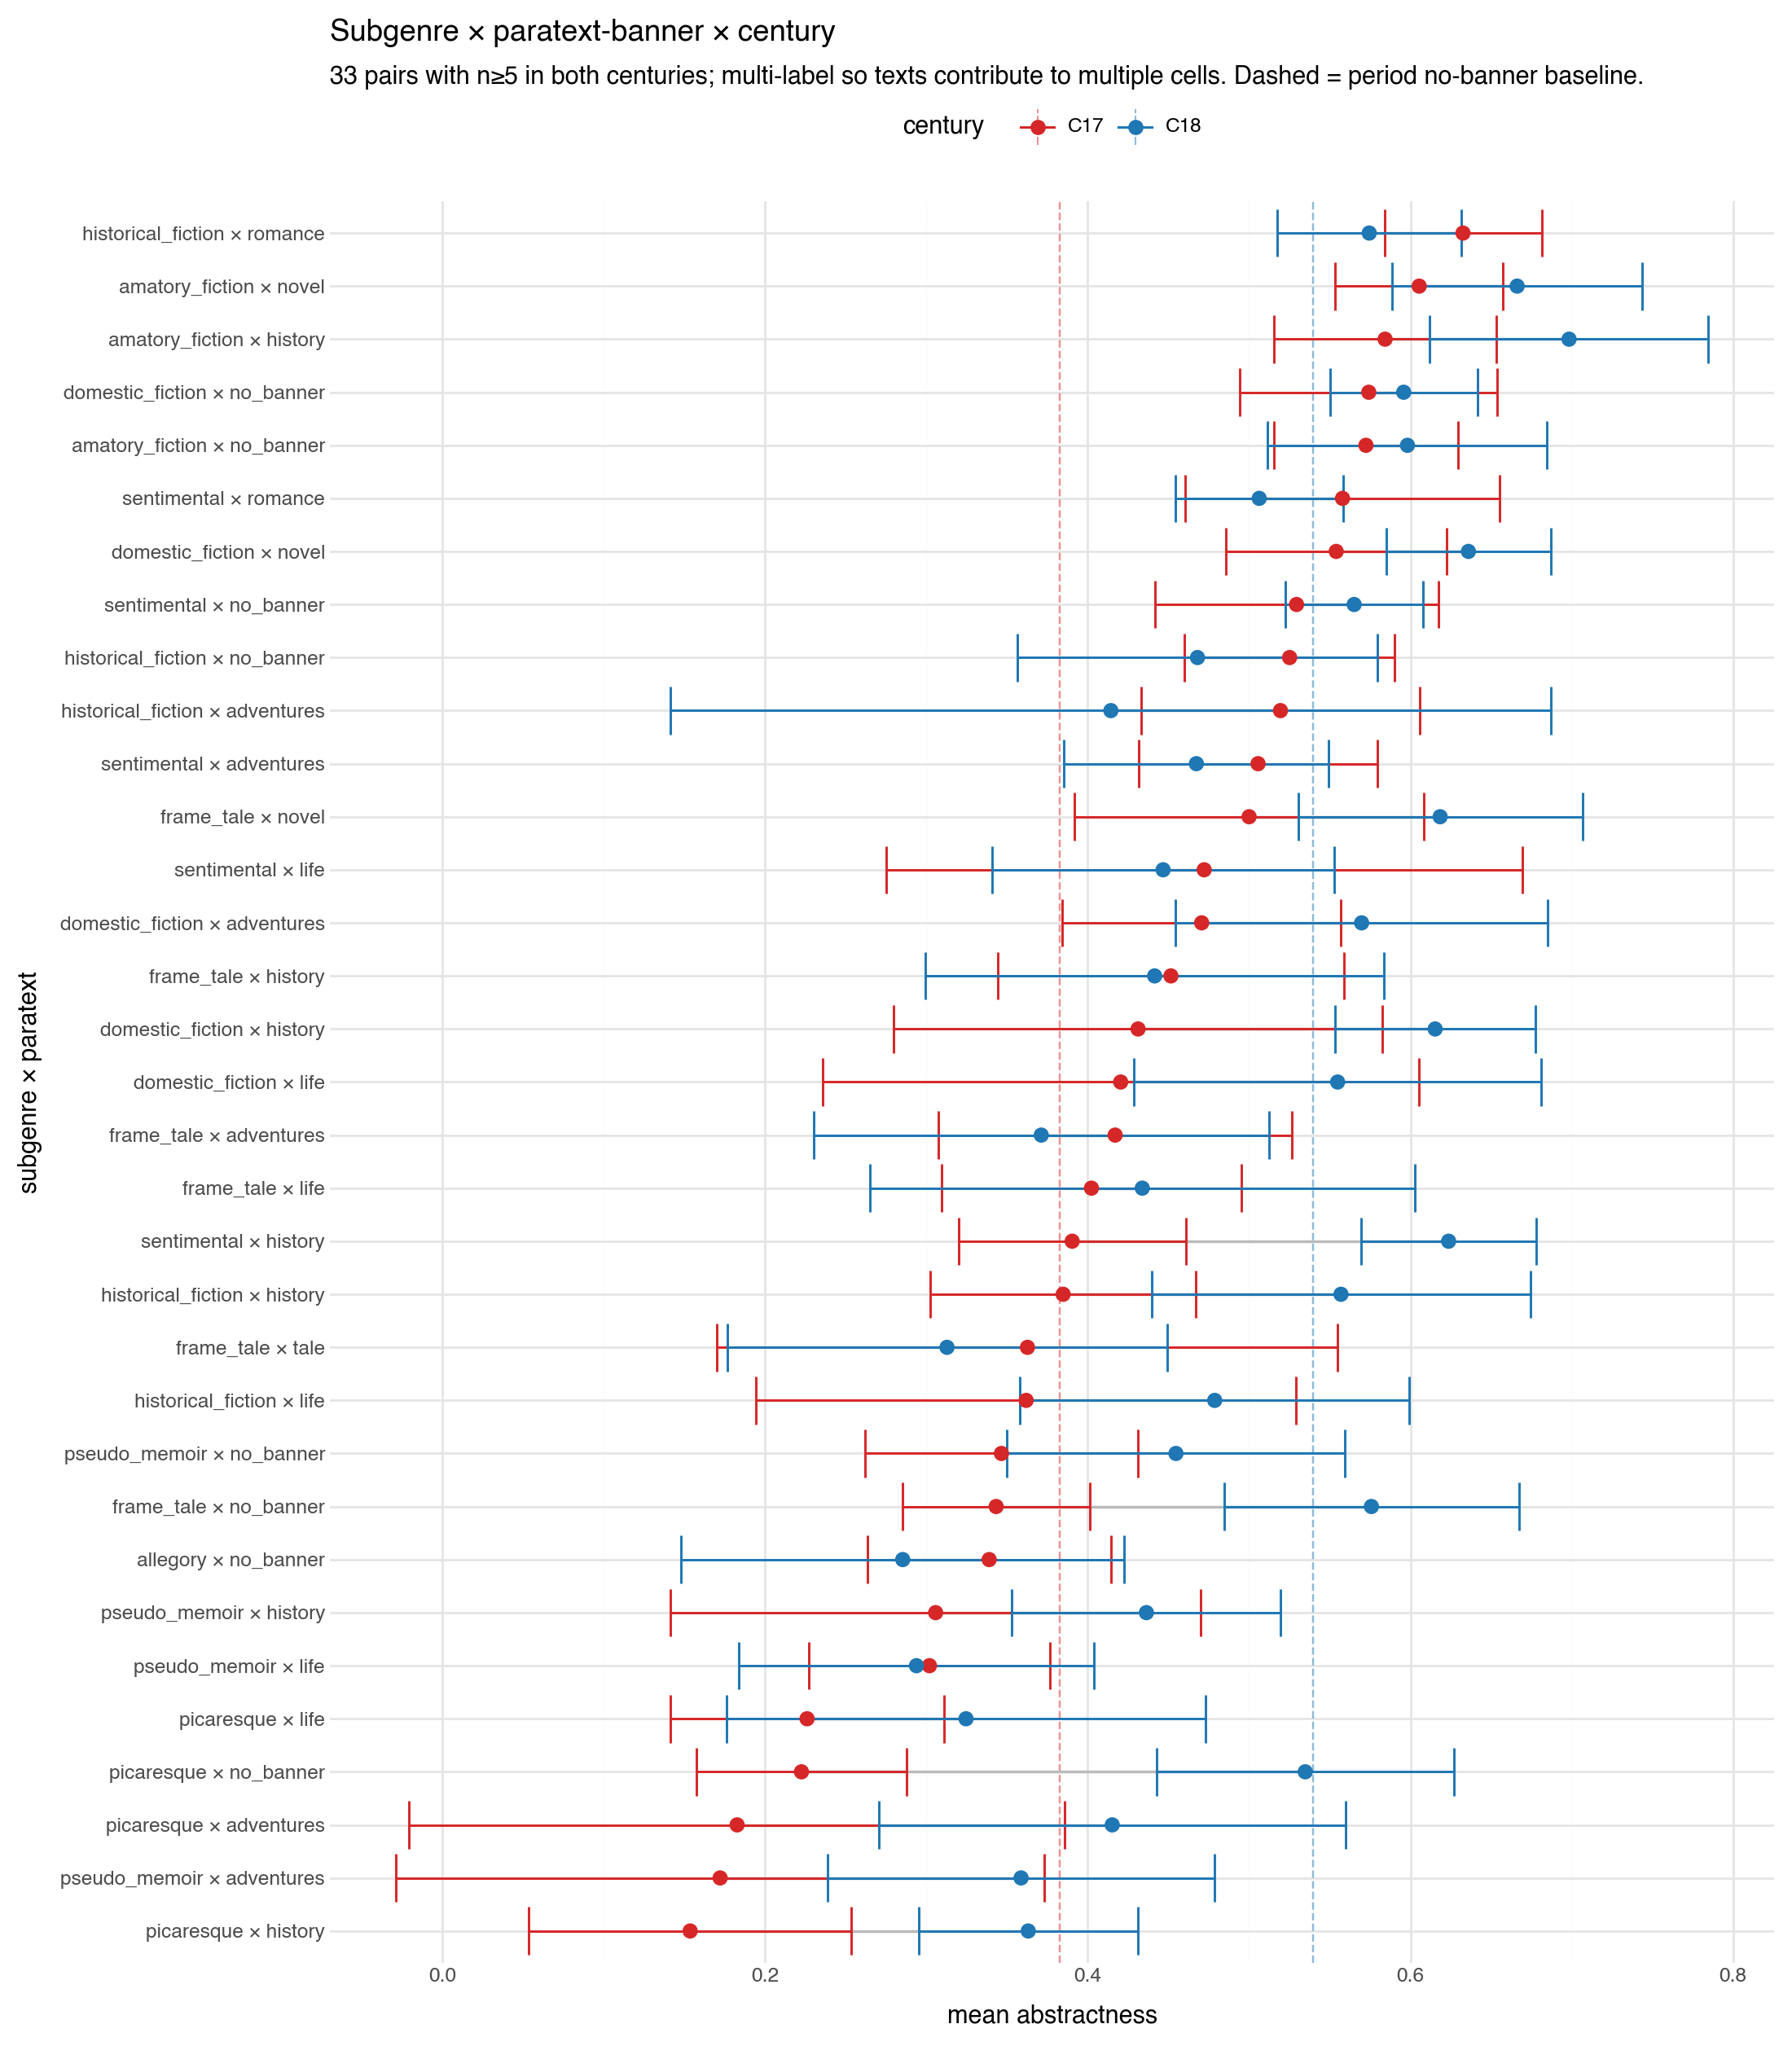

In [23]:
# Pairwise subgenre × paratext × century cells.
# Use joint sample (n=749). Multi-label: each text contributes to all
# (subgenre, banner) combos it matches, plus (subgenre, no-banner).
MIN_PER_CENT = 5
TOP_N_SG = 12
top_sg_pair = [t for t, _ in sg_counter.most_common(TOP_N_SG)]
PARA_NAMES = [c.replace('pt_', '') for c in PARA_COLS] + ['no_banner']

joint['no_banner'] = (joint[list(PARA_COLS)].sum(axis=1) == 0).astype(int)
joint['__pt_no_banner'] = joint['no_banner']
for col in PARA_COLS:
    joint[f'__pt_{col.replace("pt_", "")}'] = joint[col]

rows = []
for sg in top_sg_pair:
    has_sg = joint['subgenres'].apply(lambda L: sg in L)
    for pname in PARA_NAMES:
        has_pt = joint[f'__pt_{pname}'].astype(bool)
        for cent_label, cent_year in [('C17', 1600), ('C18', 1700)]:
            mask = has_sg & has_pt & (joint['century'] == cent_year)
            n = int(mask.sum())
            if n >= MIN_PER_CENT:
                rows.append({
                    'subgenre': sg, 'paratext': pname,
                    'pair': f'{sg} × {pname}',
                    'century': cent_label, 'n': n,
                    'mean_abs': joint.loc[mask, 'abs_score'].mean(),
                    'se': joint.loc[mask, 'abs_score'].sem(),
                })
pair_df = pd.DataFrame(rows)
pair_df['lo'] = pair_df['mean_abs'] - 1.96 * pair_df['se']
pair_df['hi'] = pair_df['mean_abs'] + 1.96 * pair_df['se']

# Keep only pairs surviving in BOTH centuries
pair_centuries = pair_df.groupby('pair')['century'].nunique()
stable_pairs = pair_centuries[pair_centuries == 2].index.tolist()
pair_df = pair_df[pair_df['pair'].isin(stable_pairs)].copy()
print(f'Pairs with n>={MIN_PER_CENT} in BOTH centuries: {len(stable_pairs)}')

# Order pairs by C17 mean_abs (concrete -> abstract)
pair_order = (pair_df[pair_df['century']=='C17']
              .sort_values('mean_abs')['pair'].tolist())
pair_df['pair'] = pd.Categorical(pair_df['pair'], categories=pair_order, ordered=True)
pair_df['century'] = pd.Categorical(pair_df['century'], categories=['C17','C18'], ordered=True)

# Connector segments
wide = pair_df.pivot_table(index='pair', columns='century',
                            values='mean_abs').reset_index()
wide['pair'] = pd.Categorical(wide['pair'], categories=pair_order, ordered=True)
wide['delta'] = wide['C18'] - wide['C17']

ref_lines = pd.DataFrame([
    {'century': 'C17', 'xref': mean_no_banner_full['C17']},
    {'century': 'C18', 'xref': mean_no_banner_full['C18']},
])
ref_lines['century'] = pd.Categorical(ref_lines['century'], categories=['C17','C18'], ordered=True)

p_pair = (p9.ggplot(pair_df, p9.aes(x='mean_abs', y='pair', color='century'))
          + p9.geom_vline(p9.aes(xintercept='xref', color='century'),
                          data=ref_lines, linetype='dashed', alpha=0.5, inherit_aes=False)
          + p9.geom_segment(p9.aes(x='C17', xend='C18', y='pair', yend='pair'),
                            data=wide, color='#bbbbbb', size=0.7, inherit_aes=False)
          + p9.geom_errorbarh(p9.aes(xmin='lo', xmax='hi'), height=0.0, size=0.6)
          + p9.geom_point(size=2.8)
          + p9.scale_color_manual(values={'C17': '#d62728', 'C18': '#1f77b4'})
          + p9.labs(
              title='Subgenre × paratext-banner × century',
              subtitle=f'{len(stable_pairs)} pairs with n≥{MIN_PER_CENT} in both centuries; '
                       f'multi-label so texts contribute to multiple cells. '
                       f'Dashed = period no-banner baseline.',
              x='mean abstractness', y='subgenre × paratext', color='century',
          )
          + p9.theme_minimal()
          + p9.theme(figure_size=(11, max(6, 0.32 * len(stable_pairs) + 2)),
                     legend_position='top'))

out = os.path.join(DROPBOX_FIGS, 'subgenre_paratext_pair_century.png')
p_pair.save(out, dpi=300, verbose=False)
print(f'Saved to {out}')

# Print ranking
print('\nTop 15 pairs by C17 mean abs (most abstract):')
print(wide.sort_values('C17', ascending=False).head(15).round(3).to_string(index=False))
print('\nTop 15 pairs by C17 mean abs (most concrete):')
print(wide.sort_values('C17').head(15).round(3).to_string(index=False))

p_pair

## 10. Oaxaca-Blinder: composition vs within-group decomposition of the C17→C18 rise

The corpus-mean abstractness rises ~+0.13 from C17 to C18. §9 / §9c show this rise has two components:
1. **Composition**: corpus shifts toward subgenres/banners that are already abstract.
2. **Within-group**: even within a fixed (subgenre × banner) cell, C18 instances are more abstract than C17 instances.

Decomposition (period 0 = C17, period 1 = C18):
$$\bar{Y}_1 - \bar{Y}_0 = \underbrace{\sum_g (w_{g,1} - w_{g,0})\,\mu_{g,0}}_{\text{composition}} + \underbrace{\sum_g w_{g,0}\,(\mu_{g,1} - \mu_{g,0})}_{\text{within}} + \underbrace{\sum_g (w_{g,1}-w_{g,0})(\mu_{g,1}-\mu_{g,0})}_{\text{interaction}}$$

Three groupings:
- **Banner only** — full arc_fiction (n=1,306), 8 disjoint banner categories
- **Subgenre only** — joint (n=618, only C17+C18), single-label primary subgenre
- **Subgenre × banner** — joint, primary-subgenre × banner pairing

Multi-label handling: pick a single primary banner per text (rarest match wins); single primary subgenre per text (rarest tag wins) — biases toward distinctive labels.

Oaxaca-Blinder decomposition of C17→C18 abstractness rise:

                           grouping   total   comp  within   inter
       banner only (k=8, n=431+706)  0.1251 0.0422  0.1287 -0.0459
subgenre (primary, k=16, n=210+187)  0.1043 0.0183  0.0939 -0.0079
   subgenre × banner (k=3, n=25+22) -0.0729 0.0551 -0.1357  0.0077

As % of total rise:
                           grouping  pct_comp  pct_within  pct_inter
       banner only (k=8, n=431+706)      33.8       102.9      -36.7
subgenre (primary, k=16, n=210+187)      17.5        90.1       -7.6
   subgenre × banner (k=3, n=25+22)     -75.6       186.2      -10.5

Note: subgenre × banner pairing was attempted but only k=2 cells survived n>=5 in both centuries (rarest-tag primary subgenre is too sparse when crossed with banner). Dropped from the figure.

Saved to /Users/rj416/Dropbox/Prof/Books/AbsLitHist/book/figures/subgenre_paratext_oaxaca_blinder.png


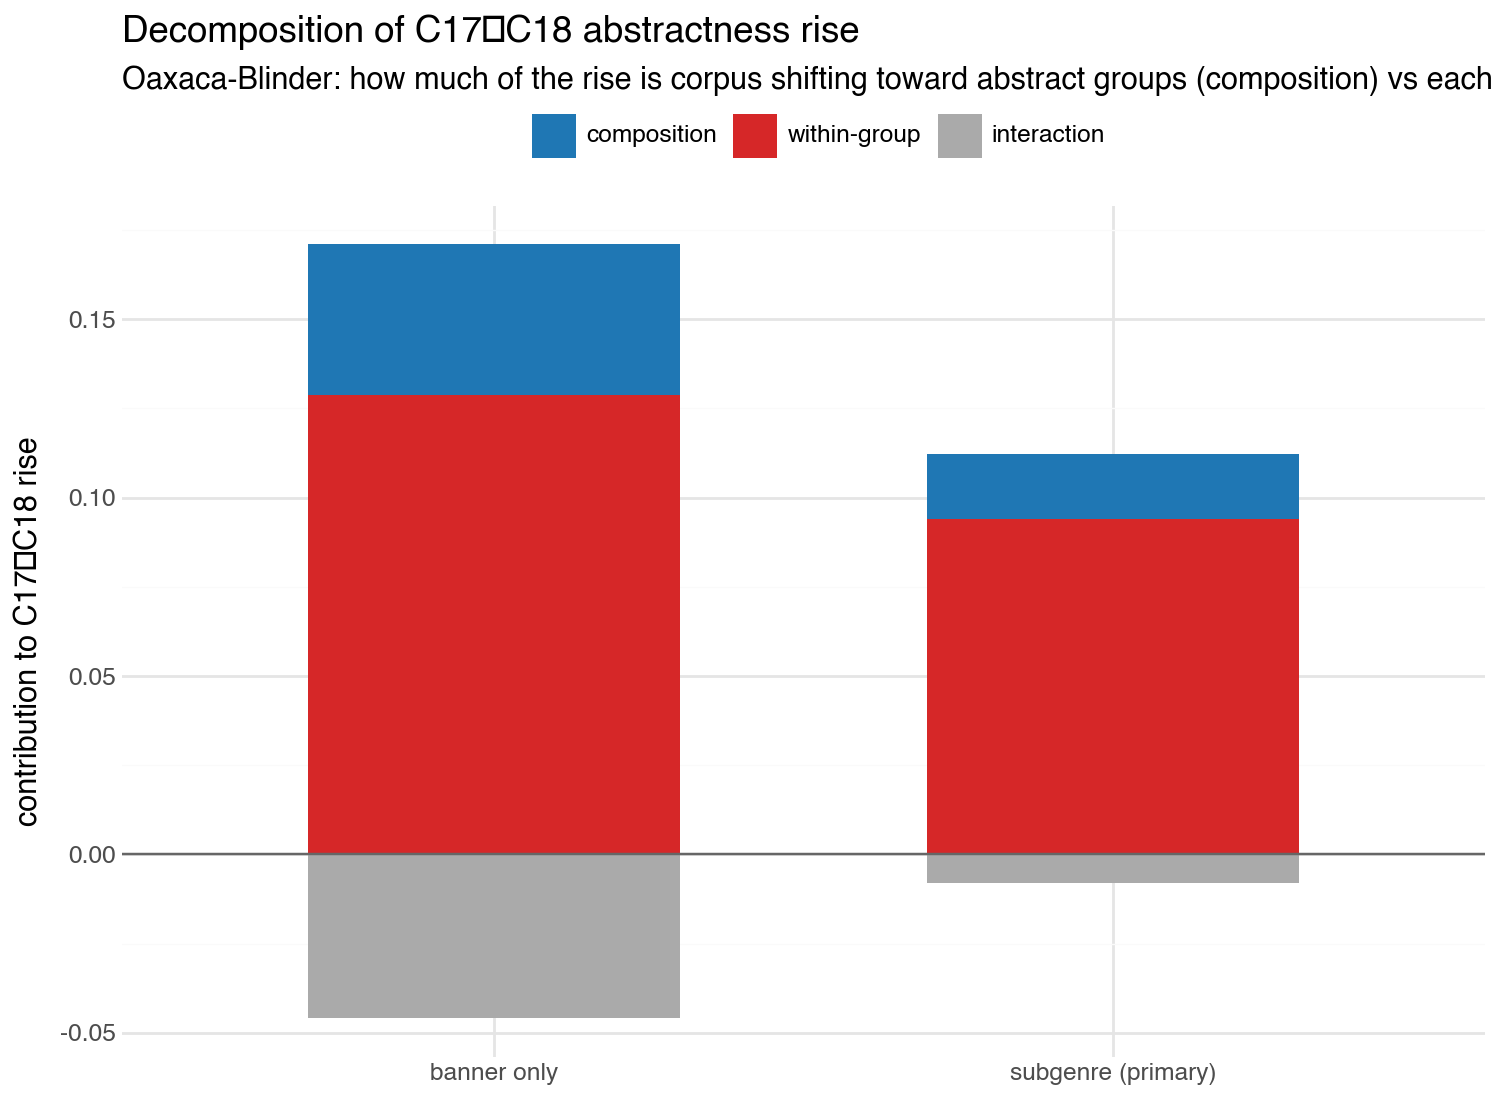

In [24]:
# Oaxaca-Blinder decomposition. Three groupings.
import numpy as np

def oaxaca(df, group_col, score_col):
    """Returns dict with comp / within / interaction / total components."""
    period_means = df.groupby(['__period', group_col])[score_col].agg(['mean', 'size']).reset_index()
    p0 = period_means[period_means['__period'] == 'C17'].set_index(group_col)
    p1 = period_means[period_means['__period'] == 'C18'].set_index(group_col)
    common_groups = sorted(set(p0.index) & set(p1.index))
    n0 = p0.loc[common_groups, 'size'].sum()
    n1 = p1.loc[common_groups, 'size'].sum()
    w0 = p0.loc[common_groups, 'size'] / n0
    w1 = p1.loc[common_groups, 'size'] / n1
    mu0 = p0.loc[common_groups, 'mean']
    mu1 = p1.loc[common_groups, 'mean']
    comp = ((w1 - w0) * mu0).sum()
    within = (w0 * (mu1 - mu0)).sum()
    inter = ((w1 - w0) * (mu1 - mu0)).sum()
    total = (w1 * mu1).sum() - (w0 * mu0).sum()
    return {
        'comp': comp, 'within': within, 'inter': inter, 'total': total,
        'n0': int(n0), 'n1': int(n1), 'k_groups': len(common_groups),
        'pct_comp': comp/total*100 if total else 0,
        'pct_within': within/total*100 if total else 0,
        'pct_inter': inter/total*100 if total else 0,
    }

# Priority order for banner: rarer-first wins for multi-banner texts
BANNER_PRIORITY = ['memoirs', 'romance', 'tale', 'novel', 'adventures', 'life', 'history']
def primary_banner(row):
    for b in BANNER_PRIORITY:
        if row.get(f'pt_{b}', 0) == 1:
            return b
    return 'no_banner'

# 1) BANNER-ONLY on full arc
arc_c1718 = arc[arc['century'].isin([1600, 1700])].copy()
arc_c1718['__period'] = arc_c1718['century'].map({1600: 'C17', 1700: 'C18'})
arc_c1718['banner'] = arc_c1718.apply(primary_banner, axis=1)
ob_banner = oaxaca(arc_c1718, 'banner', 'abs_score')

# 2) SUBGENRE-ONLY on joint (primary subgenre = rarest tag)
joint_c1718 = joint[joint['century'].isin([1600, 1700])].copy()
joint_c1718['__period'] = joint_c1718['century'].map({1600: 'C17', 1700: 'C18'})
tag_freq = sg_counter  # from earlier
def primary_subgenre(tags):
    if not tags:
        return 'unknown'
    return min(tags, key=lambda t: tag_freq.get(t, 0))
joint_c1718['psg'] = joint_c1718['subgenres'].apply(primary_subgenre)
# Restrict to subgenres with n>=8 in each century
psg_counts = joint_c1718.groupby(['__period', 'psg']).size().unstack(fill_value=0)
viable_psg = psg_counts.columns[(psg_counts.loc['C17'] >= 5) & (psg_counts.loc['C18'] >= 5)].tolist()
joint_psg = joint_c1718[joint_c1718['psg'].isin(viable_psg)].copy()
ob_subgenre = oaxaca(joint_psg, 'psg', 'abs_score')

# 3) SUBGENRE × BANNER on joint
joint_c1718['banner'] = joint_c1718.apply(primary_banner, axis=1)
joint_c1718['psg_banner'] = joint_c1718['psg'] + ' × ' + joint_c1718['banner']
pb_counts = joint_c1718.groupby(['__period', 'psg_banner']).size().unstack(fill_value=0)
viable_pb = pb_counts.columns[(pb_counts.loc['C17'] >= 5) & (pb_counts.loc['C18'] >= 5)].tolist()
joint_pb = joint_c1718[joint_c1718['psg_banner'].isin(viable_pb)].copy()
ob_pair = oaxaca(joint_pb, 'psg_banner', 'abs_score')

results = pd.DataFrame([
    {'grouping': f'banner only (k={ob_banner["k_groups"]}, n={ob_banner["n0"]}+{ob_banner["n1"]})', **{k: ob_banner[k] for k in ['total', 'comp', 'within', 'inter', 'pct_comp', 'pct_within', 'pct_inter']}},
    {'grouping': f'subgenre (primary, k={ob_subgenre["k_groups"]}, n={ob_subgenre["n0"]}+{ob_subgenre["n1"]})', **{k: ob_subgenre[k] for k in ['total', 'comp', 'within', 'inter', 'pct_comp', 'pct_within', 'pct_inter']}},
    {'grouping': f'subgenre × banner (k={ob_pair["k_groups"]}, n={ob_pair["n0"]}+{ob_pair["n1"]})', **{k: ob_pair[k] for k in ['total', 'comp', 'within', 'inter', 'pct_comp', 'pct_within', 'pct_inter']}},
])
print('Oaxaca-Blinder decomposition of C17→C18 abstractness rise:\n')
print(results[['grouping','total','comp','within','inter']].to_string(index=False, float_format='%.4f'))
print()
print('As % of total rise:')
print(results[['grouping','pct_comp','pct_within','pct_inter']].to_string(index=False, float_format='%.1f'))

# Plot waterfall: stacked bars per grouping
rows = []
for r in [ob_banner, ob_subgenre, ob_pair]:
    pass
stack_rows = []
for grp_label, ob in [('banner only', ob_banner),
                       ('subgenre (primary)', ob_subgenre)]:
    for comp_label in ['comp', 'within', 'inter']:
        stack_rows.append({
            'grouping': grp_label, 'component': comp_label,
            'value': ob[comp_label],
        })
stack_df = pd.DataFrame(stack_rows)
stack_df['grouping'] = pd.Categorical(stack_df['grouping'],
                                      categories=['banner only', 'subgenre (primary)'],
                                      ordered=True)
stack_df['component'] = pd.Categorical(stack_df['component'],
                                       categories=['comp', 'within', 'inter'],
                                       ordered=True)

print('\nNote: subgenre × banner pairing was attempted but only k=2 cells '
      'survived n>=5 in both centuries (rarest-tag primary subgenre is too sparse '
      'when crossed with banner). Dropped from the figure.')
p_ob = (p9.ggplot(stack_df, p9.aes(x='grouping', y='value', fill='component'))
        + p9.geom_col(position='stack', width=0.6)
        + p9.geom_hline(yintercept=0, color='#666666', size=0.5)
        + p9.scale_fill_manual(values={'comp': '#1f77b4', 'within': '#d62728', 'inter': '#aaaaaa'},
                                labels={'comp': 'composition', 'within': 'within-group', 'inter': 'interaction'})
        + p9.labs(
            title='Decomposition of C17→C18 abstractness rise',
            subtitle='Oaxaca-Blinder: how much of the rise is corpus shifting toward abstract groups (composition) '
                     'vs each group becoming more abstract (within-group)',
            x='', y='contribution to C17→C18 rise', fill='',
        )
        + p9.theme_minimal()
        + p9.theme(figure_size=(7.5, 5.5), legend_position='top'))

out = os.path.join(DROPBOX_FIGS, 'subgenre_paratext_oaxaca_blinder.png')
p_ob.save(out, dpi=300, verbose=False)
print(f'\nSaved to {out}')
p_ob

## 11. Testing the language-change hypothesis: cross-genre C17→C18 shift

§10 found that ~2/3 of fiction's C17→C18 abstractness rise is *within-group* (each subgenre/banner becoming more abstract), not just compositional. Most plausible candidate explanation: language-level abstractness inflation — C18 English absorbed a flood of Latinate/sentiment vocabulary that would push *any* prose toward our abstractness metric, regardless of literary intent.

Test: does the same C17→C18 within-genre rise show up in *non-fiction*? If language change is the driver, sermons / treatises / biographies / letters / essays should all rise too. If it's specific to fiction, the rise is fiction's own trajectory, not a corpus-wide language shift.

C17 vs C18 mean abstractness by genre (English, n>=100 each century):

     genre     n_C17     n_C18  mean_abs_C17  mean_abs_C18  delta
   Almanac   138.000  1463.000         0.211        -0.205 -0.416
 Reference   400.000 12973.000         0.357         0.055 -0.302
     Legal  4994.000 11287.000         0.639         0.387 -0.252
  Treatise  1532.000  8463.000         0.638         0.395 -0.243
Nonfiction  6506.000 48799.000         0.555         0.334 -0.221
 Biography   832.000 14544.000         0.629         0.457 -0.172
     Drama  3911.000 13717.000         0.391         0.233 -0.159
     Essay   207.000  9683.000         0.689         0.537 -0.152
   Letters  3683.000 25973.000         0.656         0.579 -0.077
Periodical   186.000  2034.000         0.371         0.296 -0.076
    Speech   760.000  2062.000         0.768         0.693 -0.075
    Poetry 48860.000 61331.000         0.203         0.249  0.046
   Fiction   945.000 18345.000         0.398         0.447  0.049
    S


Saved to /Users/rj416/Dropbox/Prof/Books/AbsLitHist/book/figures/genre_abstractness_C17_C18.png


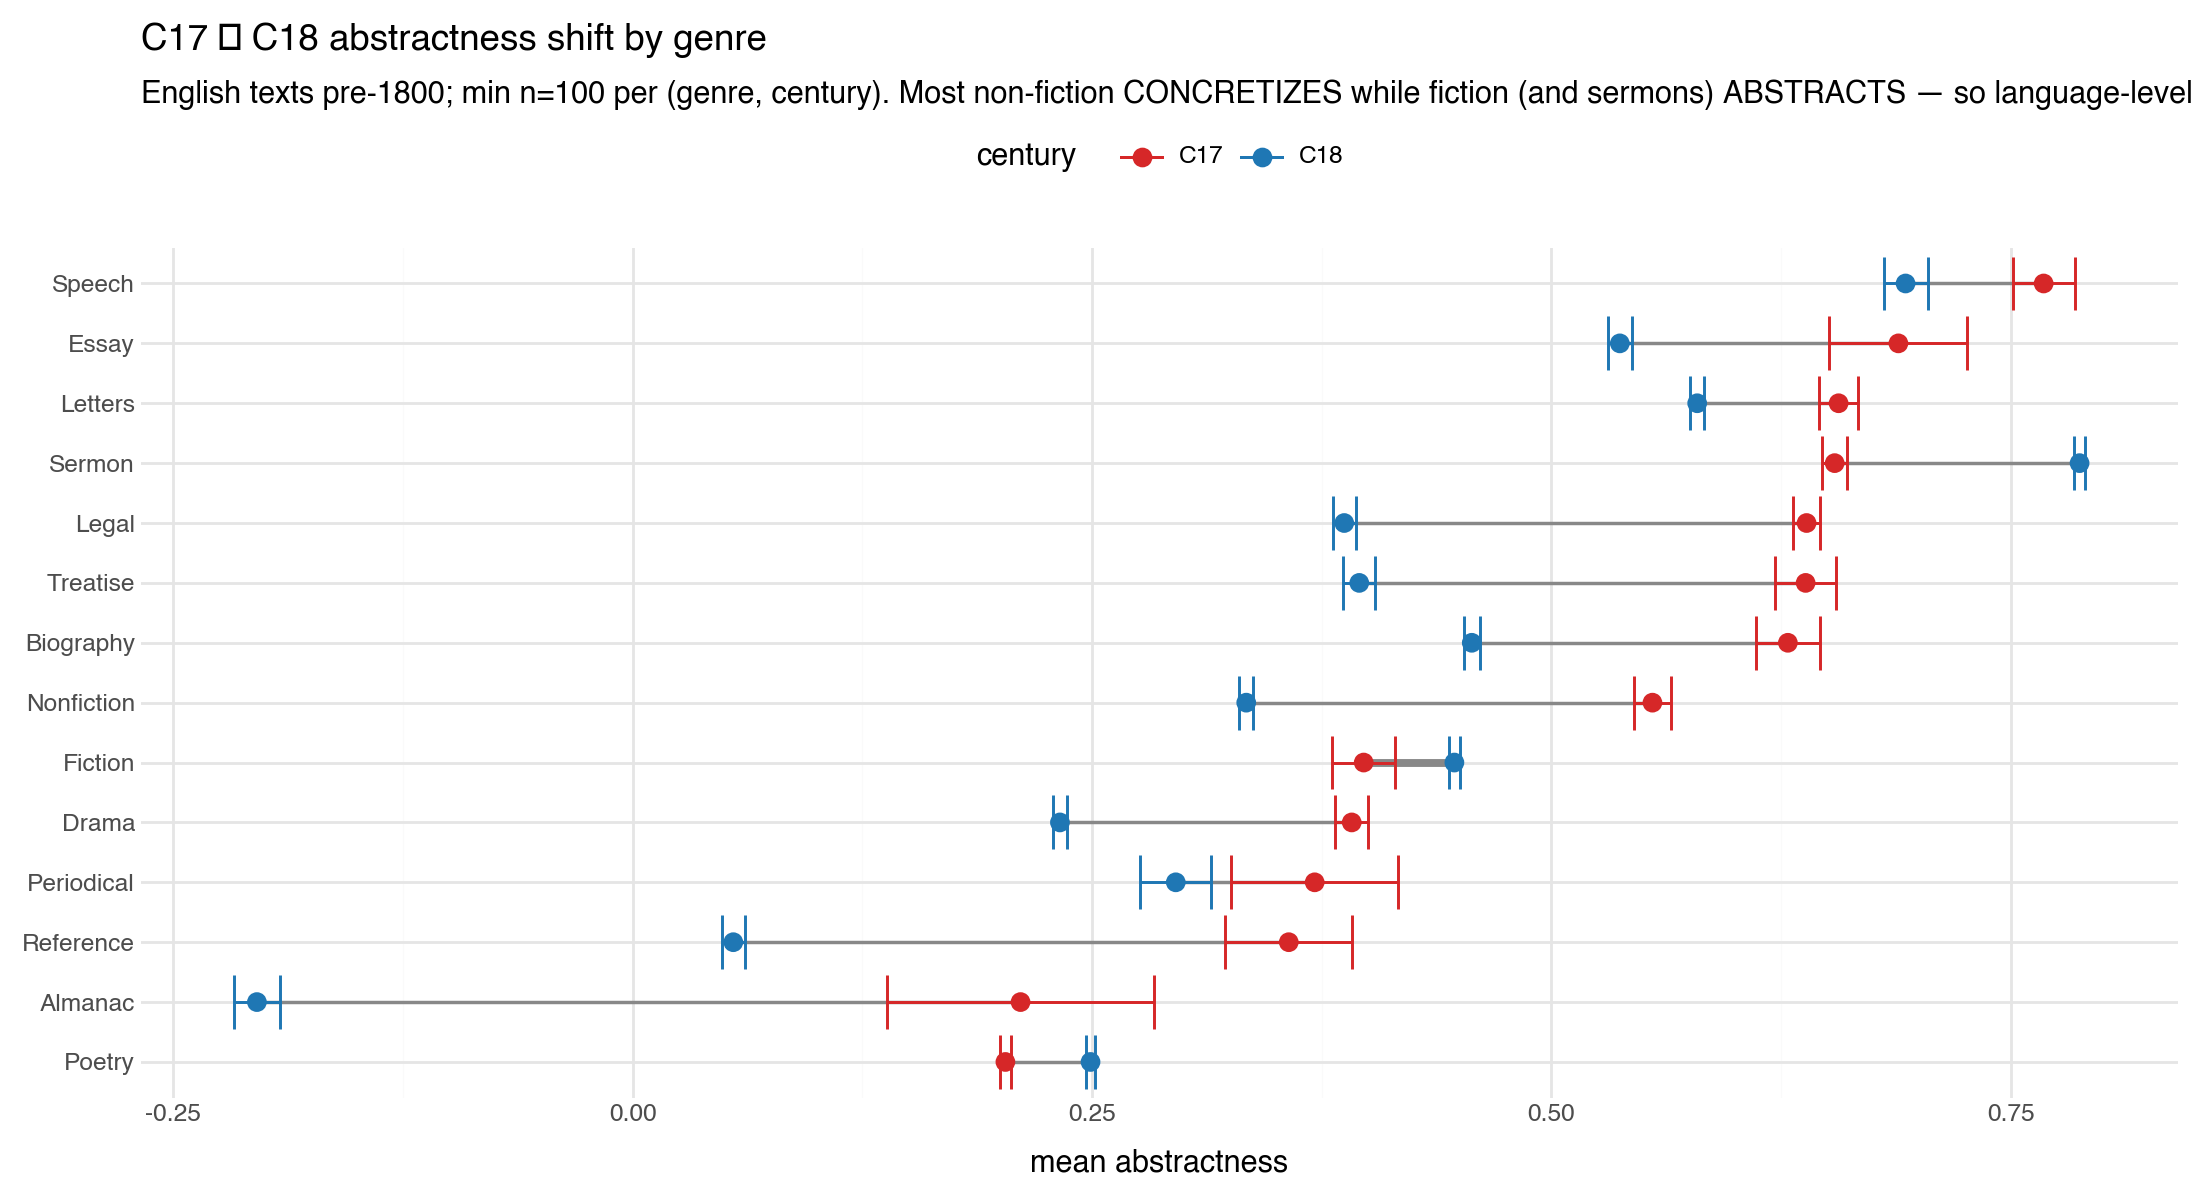

In [25]:
# Cross-genre C17 vs C18 mean abstractness, English texts pre-1800.
# Uses lltk.texts (not rep-aggregated) for n; scores from abstraction.scores_en.
import clickhouse_connect
ch = clickhouse_connect.get_client(host='localhost', port=8123, username='lltk', password='lltk')
q = '''
SELECT
  genre,
  CASE
    WHEN year >= 1600 AND year < 1700 THEN 'C17'
    WHEN year >= 1700 AND year < 1800 THEN 'C18'
  END AS century,
  count() AS n,
  avg(-s.`Abs-Conc.Median.median`) AS mean_abs,
  stddevSamp(-s.`Abs-Conc.Median.median`) / sqrt(count()) AS sem
FROM lltk.texts t
INNER JOIN abstraction.scores_en s ON s._id = t._id
WHERE year >= 1600 AND year < 1800 AND lang = 'en'
  AND s.`Abs-Conc.Median.median` IS NOT NULL
  AND genre != ''
GROUP BY genre, century ORDER BY genre, century
'''
gdf = ch.query_df(q)
ch.close()

# Pivot to wide; keep genres with n>=100 in each century
gpiv = gdf.pivot(index='genre', columns='century', values=['n','mean_abs','sem'])
gpiv.columns = ['_'.join(c) for c in gpiv.columns]
gpiv = gpiv.reset_index()
gpiv = gpiv[(gpiv['n_C17'] >= 100) & (gpiv['n_C18'] >= 100)].copy()
gpiv['delta'] = gpiv['mean_abs_C18'] - gpiv['mean_abs_C17']
gpiv['lo_C17'] = gpiv['mean_abs_C17'] - 1.96 * gpiv['sem_C17']
gpiv['hi_C17'] = gpiv['mean_abs_C17'] + 1.96 * gpiv['sem_C17']
gpiv['lo_C18'] = gpiv['mean_abs_C18'] - 1.96 * gpiv['sem_C18']
gpiv['hi_C18'] = gpiv['mean_abs_C18'] + 1.96 * gpiv['sem_C18']

print('C17 vs C18 mean abstractness by genre (English, n>=100 each century):\n')
print(gpiv[['genre','n_C17','n_C18','mean_abs_C17','mean_abs_C18','delta']]
      .sort_values('delta').to_string(index=False, float_format='%.3f'))
print()
print(f'Fiction Δ = {gpiv.loc[gpiv["genre"]=="Fiction","delta"].iloc[0]:+.3f}')
non_fic = gpiv[gpiv['genre']!='Fiction']
print(f'Median non-fiction Δ: {non_fic["delta"].median():+.3f}')
rise = non_fic[non_fic['delta'] > 0]
print(f'Genres rising  (Δ>0): {len(gpiv[gpiv["delta"]>0])} / {len(gpiv)}: ' + 
      ', '.join(gpiv[gpiv['delta']>0]['genre'].tolist()))
print(f'Genres falling (Δ<0): {len(gpiv[gpiv["delta"]<0])} / {len(gpiv)}: ' + 
      ', '.join(gpiv[gpiv['delta']<0]['genre'].tolist()))

# Long-format for plotting paired points
long_rows = []
for _, r in gpiv.iterrows():
    for cent in ('C17', 'C18'):
        long_rows.append({
            'genre': r['genre'], 'century': cent,
            'mean_abs': r[f'mean_abs_{cent}'],
            'lo': r[f'lo_{cent}'], 'hi': r[f'hi_{cent}'],
            'n': r[f'n_{cent}'],
        })
glong = pd.DataFrame(long_rows)

# Order by C17 mean (concrete -> abstract)
g_order = gpiv.sort_values('mean_abs_C17')['genre'].tolist()
glong['genre'] = pd.Categorical(glong['genre'], categories=g_order, ordered=True)
glong['century'] = pd.Categorical(glong['century'], categories=['C17','C18'], ordered=True)

# Highlight fiction
glong['is_fiction'] = glong['genre'] == 'Fiction'
wide_seg = gpiv[['genre','mean_abs_C17','mean_abs_C18']].copy()
wide_seg['genre'] = pd.Categorical(wide_seg['genre'], categories=g_order, ordered=True)
wide_seg['fiction'] = wide_seg['genre'] == 'Fiction'

p_lang = (p9.ggplot(glong, p9.aes(x='mean_abs', y='genre', color='century'))
          + p9.geom_segment(p9.aes(x='mean_abs_C17', xend='mean_abs_C18',
                                    y='genre', yend='genre',
                                    size='fiction'),
                            data=wide_seg, color='#888888', inherit_aes=False)
          + p9.geom_errorbarh(p9.aes(xmin='lo', xmax='hi'), height=0.0, size=0.6)
          + p9.geom_point(size=3.0)
          + p9.scale_color_manual(values={'C17': '#d62728', 'C18': '#1f77b4'})
          + p9.scale_size_manual(values={True: 1.6, False: 0.7}, guide=None)
          + p9.labs(
              title='C17 → C18 abstractness shift by genre',
              subtitle=f'English texts pre-1800; min n=100 per (genre, century). '
                       f'Most non-fiction CONCRETIZES while fiction (and sermons) ABSTRACTS — '
                       f'so language-level inflation is not driving fiction\'s rise.',
              x='mean abstractness', y='', color='century',
          )
          + p9.theme_minimal()
          + p9.theme(figure_size=(11, 6), legend_position='top'))

out = os.path.join(DROPBOX_FIGS, 'genre_abstractness_C17_C18.png')
p_lang.save(out, dpi=300, verbose=False)
print(f'\nSaved to {out}')
p_lang

## 12. Four-century arc: C17 → C18 → C19 → C20

Extend §11 to track the abstractness trajectory across four centuries. Question: does fiction continue to swim upstream, or does it concretize with the Victorian/realist turn?

Answer (preview): **fiction concretizes substantially after C18**. Mean abs: 0.40 (C17) → 0.45 (C18) → 0.24 (C19) → 0.09 (C20). The C18 peak is real and gives way to the long arc of realist concretization — exactly the U-shape Ch5 has been arguing for.

Genres with n>=100 in all four centuries: 13 / 20

     genre  mean_abs_C17  mean_abs_C18  mean_abs_C19  mean_abs_C20
    Sermon         0.654         0.788         0.784         0.680
    Speech         0.768         0.693         0.767         0.820
   Letters         0.656         0.579         0.536         0.469
     Essay         0.689         0.537         0.619         0.668
 Biography         0.629         0.457         0.533         0.493
   Fiction         0.398         0.447         0.244         0.087
  Treatise         0.638         0.395         0.378         0.336
     Legal         0.639         0.387         0.418         0.606
Nonfiction         0.555         0.334         0.311         0.468
Periodical         0.371         0.296         0.533         0.283
    Poetry         0.203         0.249         0.004        -0.190
     Drama         0.391         0.233         0.199         0.052
   Almanac         0.211        -0.205         0.202         0.192



Saved to /Users/rj416/Dropbox/Prof/Books/AbsLitHist/book/figures/genre_abstractness_C17_C20.png


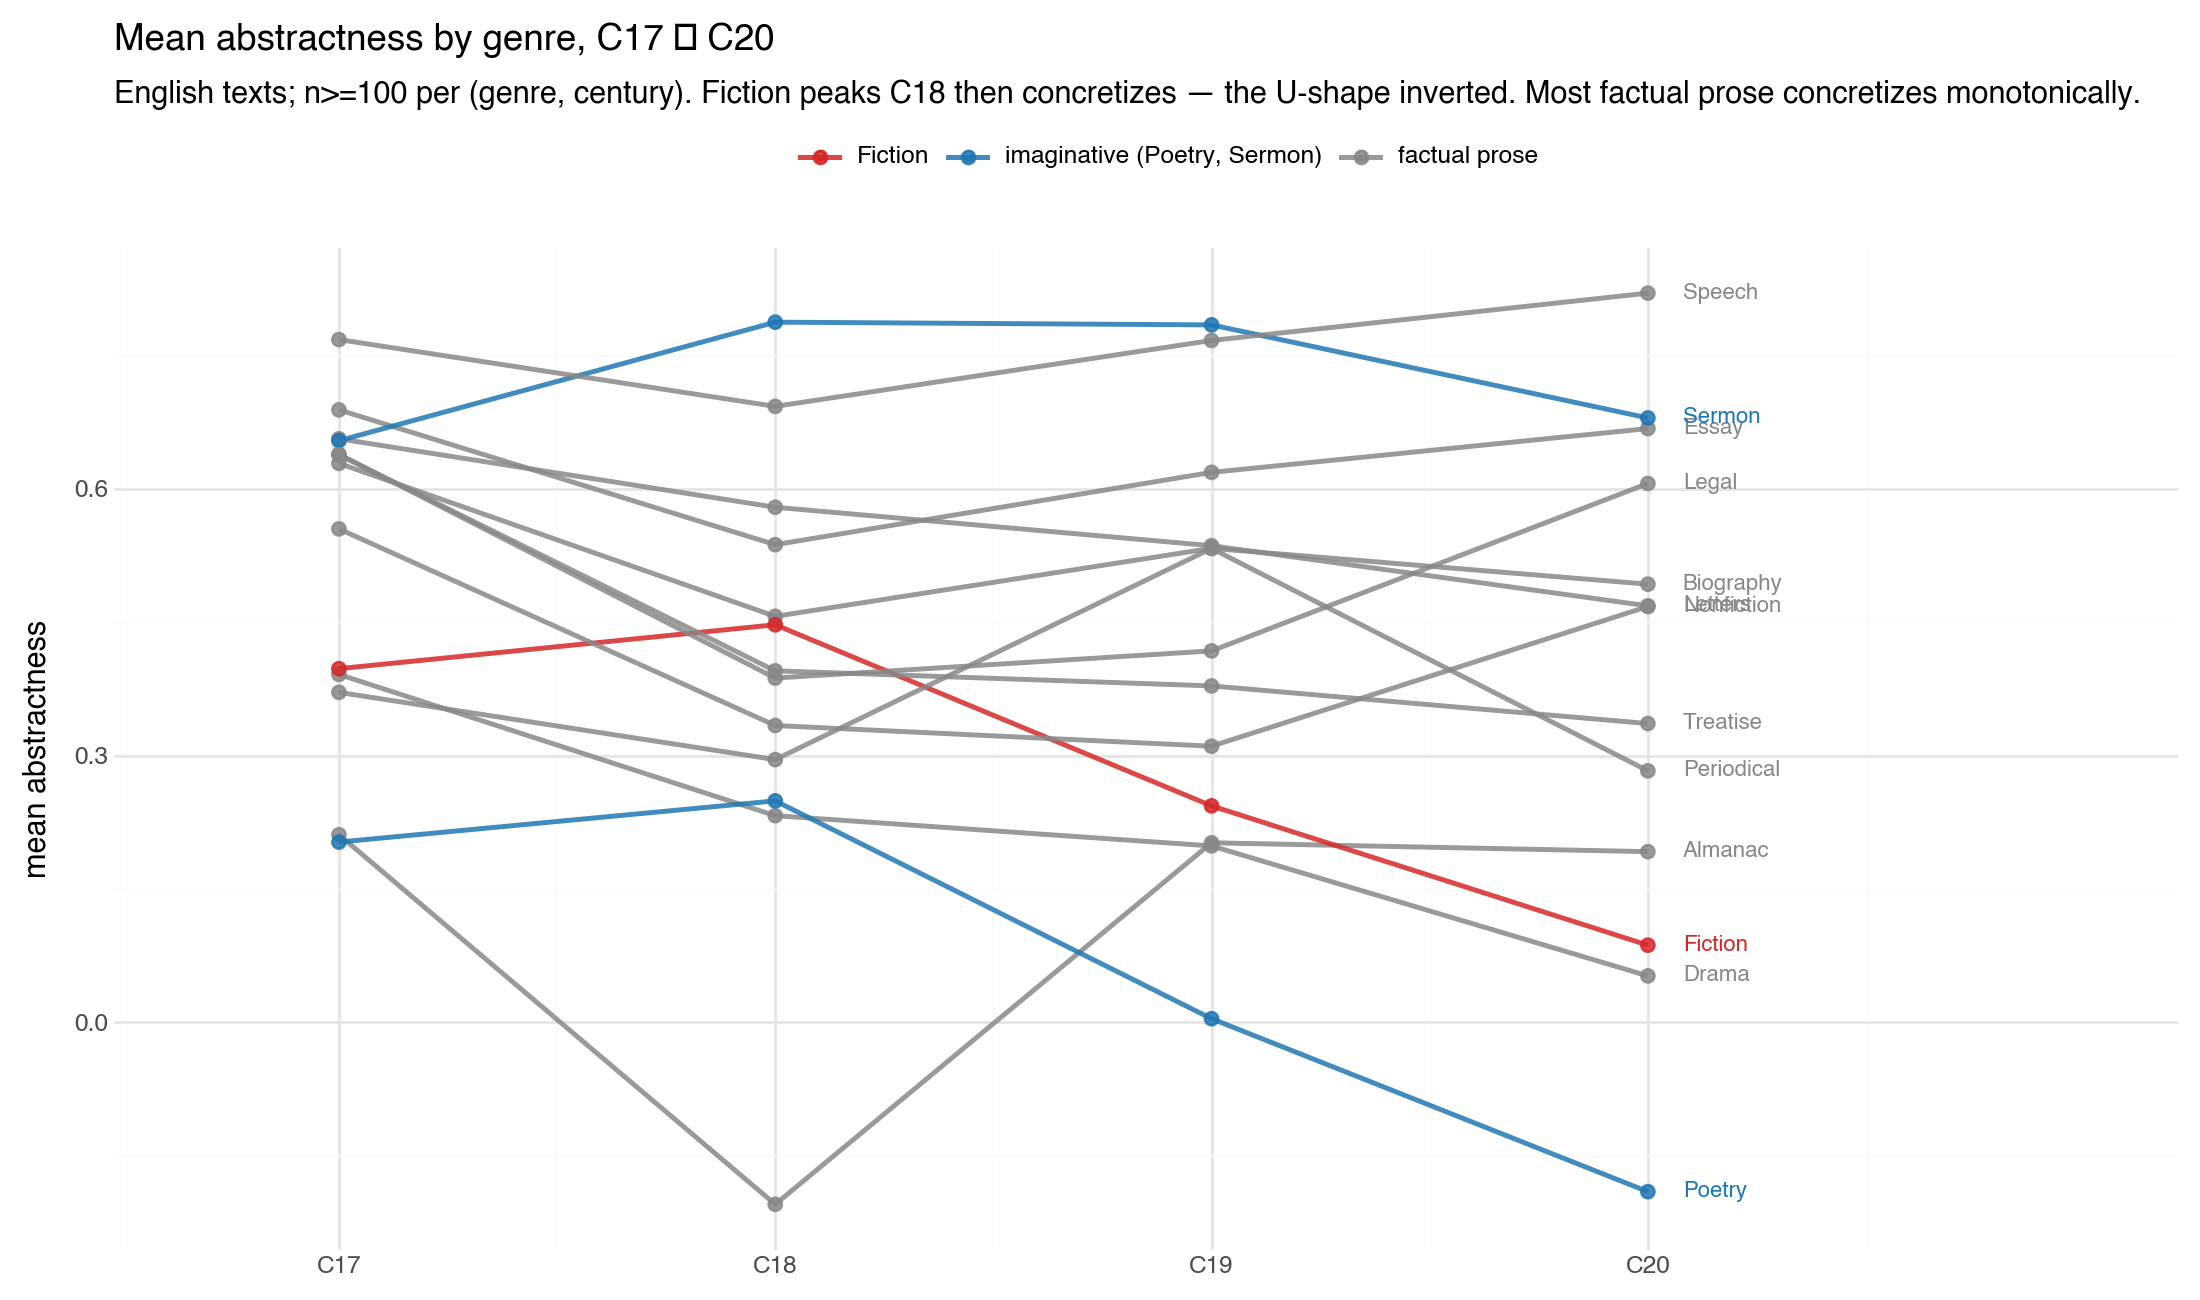

In [26]:
# Four-century mean abstractness by genre.
import clickhouse_connect
ch = clickhouse_connect.get_client(host='localhost', port=8123, username='lltk', password='lltk')
q = '''
SELECT
  genre,
  CASE
    WHEN year >= 1600 AND year < 1700 THEN 'C17'
    WHEN year >= 1700 AND year < 1800 THEN 'C18'
    WHEN year >= 1800 AND year < 1900 THEN 'C19'
    WHEN year >= 1900 AND year < 2000 THEN 'C20'
  END AS century,
  count() AS n,
  avg(-s.`Abs-Conc.Median.median`) AS mean_abs,
  stddevSamp(-s.`Abs-Conc.Median.median`) / sqrt(count()) AS sem
FROM lltk.texts t
INNER JOIN abstraction.scores_en s ON s._id = t._id
WHERE year >= 1600 AND year < 2000 AND lang = 'en'
  AND s.`Abs-Conc.Median.median` IS NOT NULL
  AND genre != ''
GROUP BY genre, century ORDER BY genre, century
'''
fc = ch.query_df(q)
ch.close()
fc_piv = fc.pivot(index='genre', columns='century', values=['n', 'mean_abs', 'sem'])
fc_piv.columns = ['_'.join(c) for c in fc_piv.columns]
fc_piv = fc_piv.reset_index()

# Keep genres with n>=100 in ALL four centuries
min_n = 100
ok = ((fc_piv['n_C17'] >= min_n) & (fc_piv['n_C18'] >= min_n) &
      (fc_piv['n_C19'] >= min_n) & (fc_piv['n_C20'] >= min_n))
fc_kept = fc_piv[ok].copy()
print(f'Genres with n>=100 in all four centuries: {len(fc_kept)} / {len(fc_piv)}')
print()
print(fc_kept[['genre','mean_abs_C17','mean_abs_C18','mean_abs_C19','mean_abs_C20']]
      .sort_values('mean_abs_C18', ascending=False).to_string(index=False, float_format='%.3f'))

# Long format for plotting
long_rows = []
for _, r in fc_kept.iterrows():
    for cent in ('C17', 'C18', 'C19', 'C20'):
        long_rows.append({
            'genre': r['genre'],
            'century_year': {'C17': 1650, 'C18': 1750, 'C19': 1850, 'C20': 1950}[cent],
            'century': cent,
            'mean_abs': r[f'mean_abs_{cent}'],
            'lo': r[f'mean_abs_{cent}'] - 1.96 * r[f'sem_{cent}'],
            'hi': r[f'mean_abs_{cent}'] + 1.96 * r[f'sem_{cent}'],
            'n': r[f'n_{cent}'],
        })
fc_long = pd.DataFrame(long_rows)

# Highlight Fiction (red); other imaginative-prose genres (poetry, sermon) blue;
# factual-prose genres grey
imag_genres = {'Fiction', 'Poetry', 'Sermon'}
fc_long['cluster'] = fc_long['genre'].apply(
    lambda g: 'Fiction' if g == 'Fiction' else
              'imaginative (Poetry, Sermon)' if g in imag_genres else
              'factual prose'
)
fc_long['cluster'] = pd.Categorical(
    fc_long['cluster'],
    categories=['Fiction', 'imaginative (Poetry, Sermon)', 'factual prose'], ordered=True)

# Labels at C20 for each line
labels = fc_long[fc_long['century_year'] == 1950].copy()

p_fc = (p9.ggplot(fc_long, p9.aes(x='century_year', y='mean_abs',
                                   group='genre', color='cluster'))
        + p9.geom_line(size=1.0, alpha=0.85)
        + p9.geom_point(size=2.2, alpha=0.85)
        + p9.geom_text(p9.aes(label='genre'),
                       data=labels, nudge_x=8, ha='left', size=8)
        + p9.scale_color_manual(values={
            'Fiction': '#d62728',
            'imaginative (Poetry, Sermon)': '#1f77b4',
            'factual prose': '#888888',
          })
        + p9.scale_x_continuous(breaks=[1650, 1750, 1850, 1950],
                                 labels=['C17','C18','C19','C20'],
                                 limits=(1620, 2050))
        + p9.labs(
            title='Mean abstractness by genre, C17 → C20',
            subtitle=f'English texts; n>=100 per (genre, century). '
                     f'Fiction peaks C18 then concretizes — the U-shape inverted. '
                     f'Most factual prose concretizes monotonically.',
            x='', y='mean abstractness', color='',
        )
        + p9.theme_minimal()
        + p9.theme(figure_size=(11, 6.5), legend_position='top'))

out = os.path.join(DROPBOX_FIGS, 'genre_abstractness_C17_C20.png')
p_fc.save(out, dpi=300, verbose=False)
print(f'\nSaved to {out}')
p_fc

## 13. Post-1800 subgenres: the abstract cluster doesn't survive C19

Sonnet's `subgenre` task now covers post-1800 fiction (n=539 C19+C20 fiction). Many tags span centuries (domestic_fiction, sentimental, gothic, historical_fiction, picaresque, allegory, epistolary), letting us extend §9's stability check across all four centuries.

Question: does the §9 'stable abstract cluster' (domestic, sentimental, epistolary, etc.) **maintain** its register through C19 and C20, or does the C18→C19 corpus concretization (−0.20 at the genre level) reach inside these subgenres too?

Answer: the within-subgenre concretization is **huge** in C19 and C20. Domestic_fiction drops from 0.60 (C18) to 0.34 (C19) to −0.01 (C20). So the C19 realist turn isn't compositional — it's the abstract-cluster subgenres *themselves* concretizing, plus new concrete subgenres (regional_novel, sensation_novel) emerging.

Total fiction texts with subgenre + score, year≥1500: 1,282



Saved to /Users/rj416/Dropbox/Prof/Books/AbsLitHist/book/figures/subgenre_abstractness_C16_C20.png


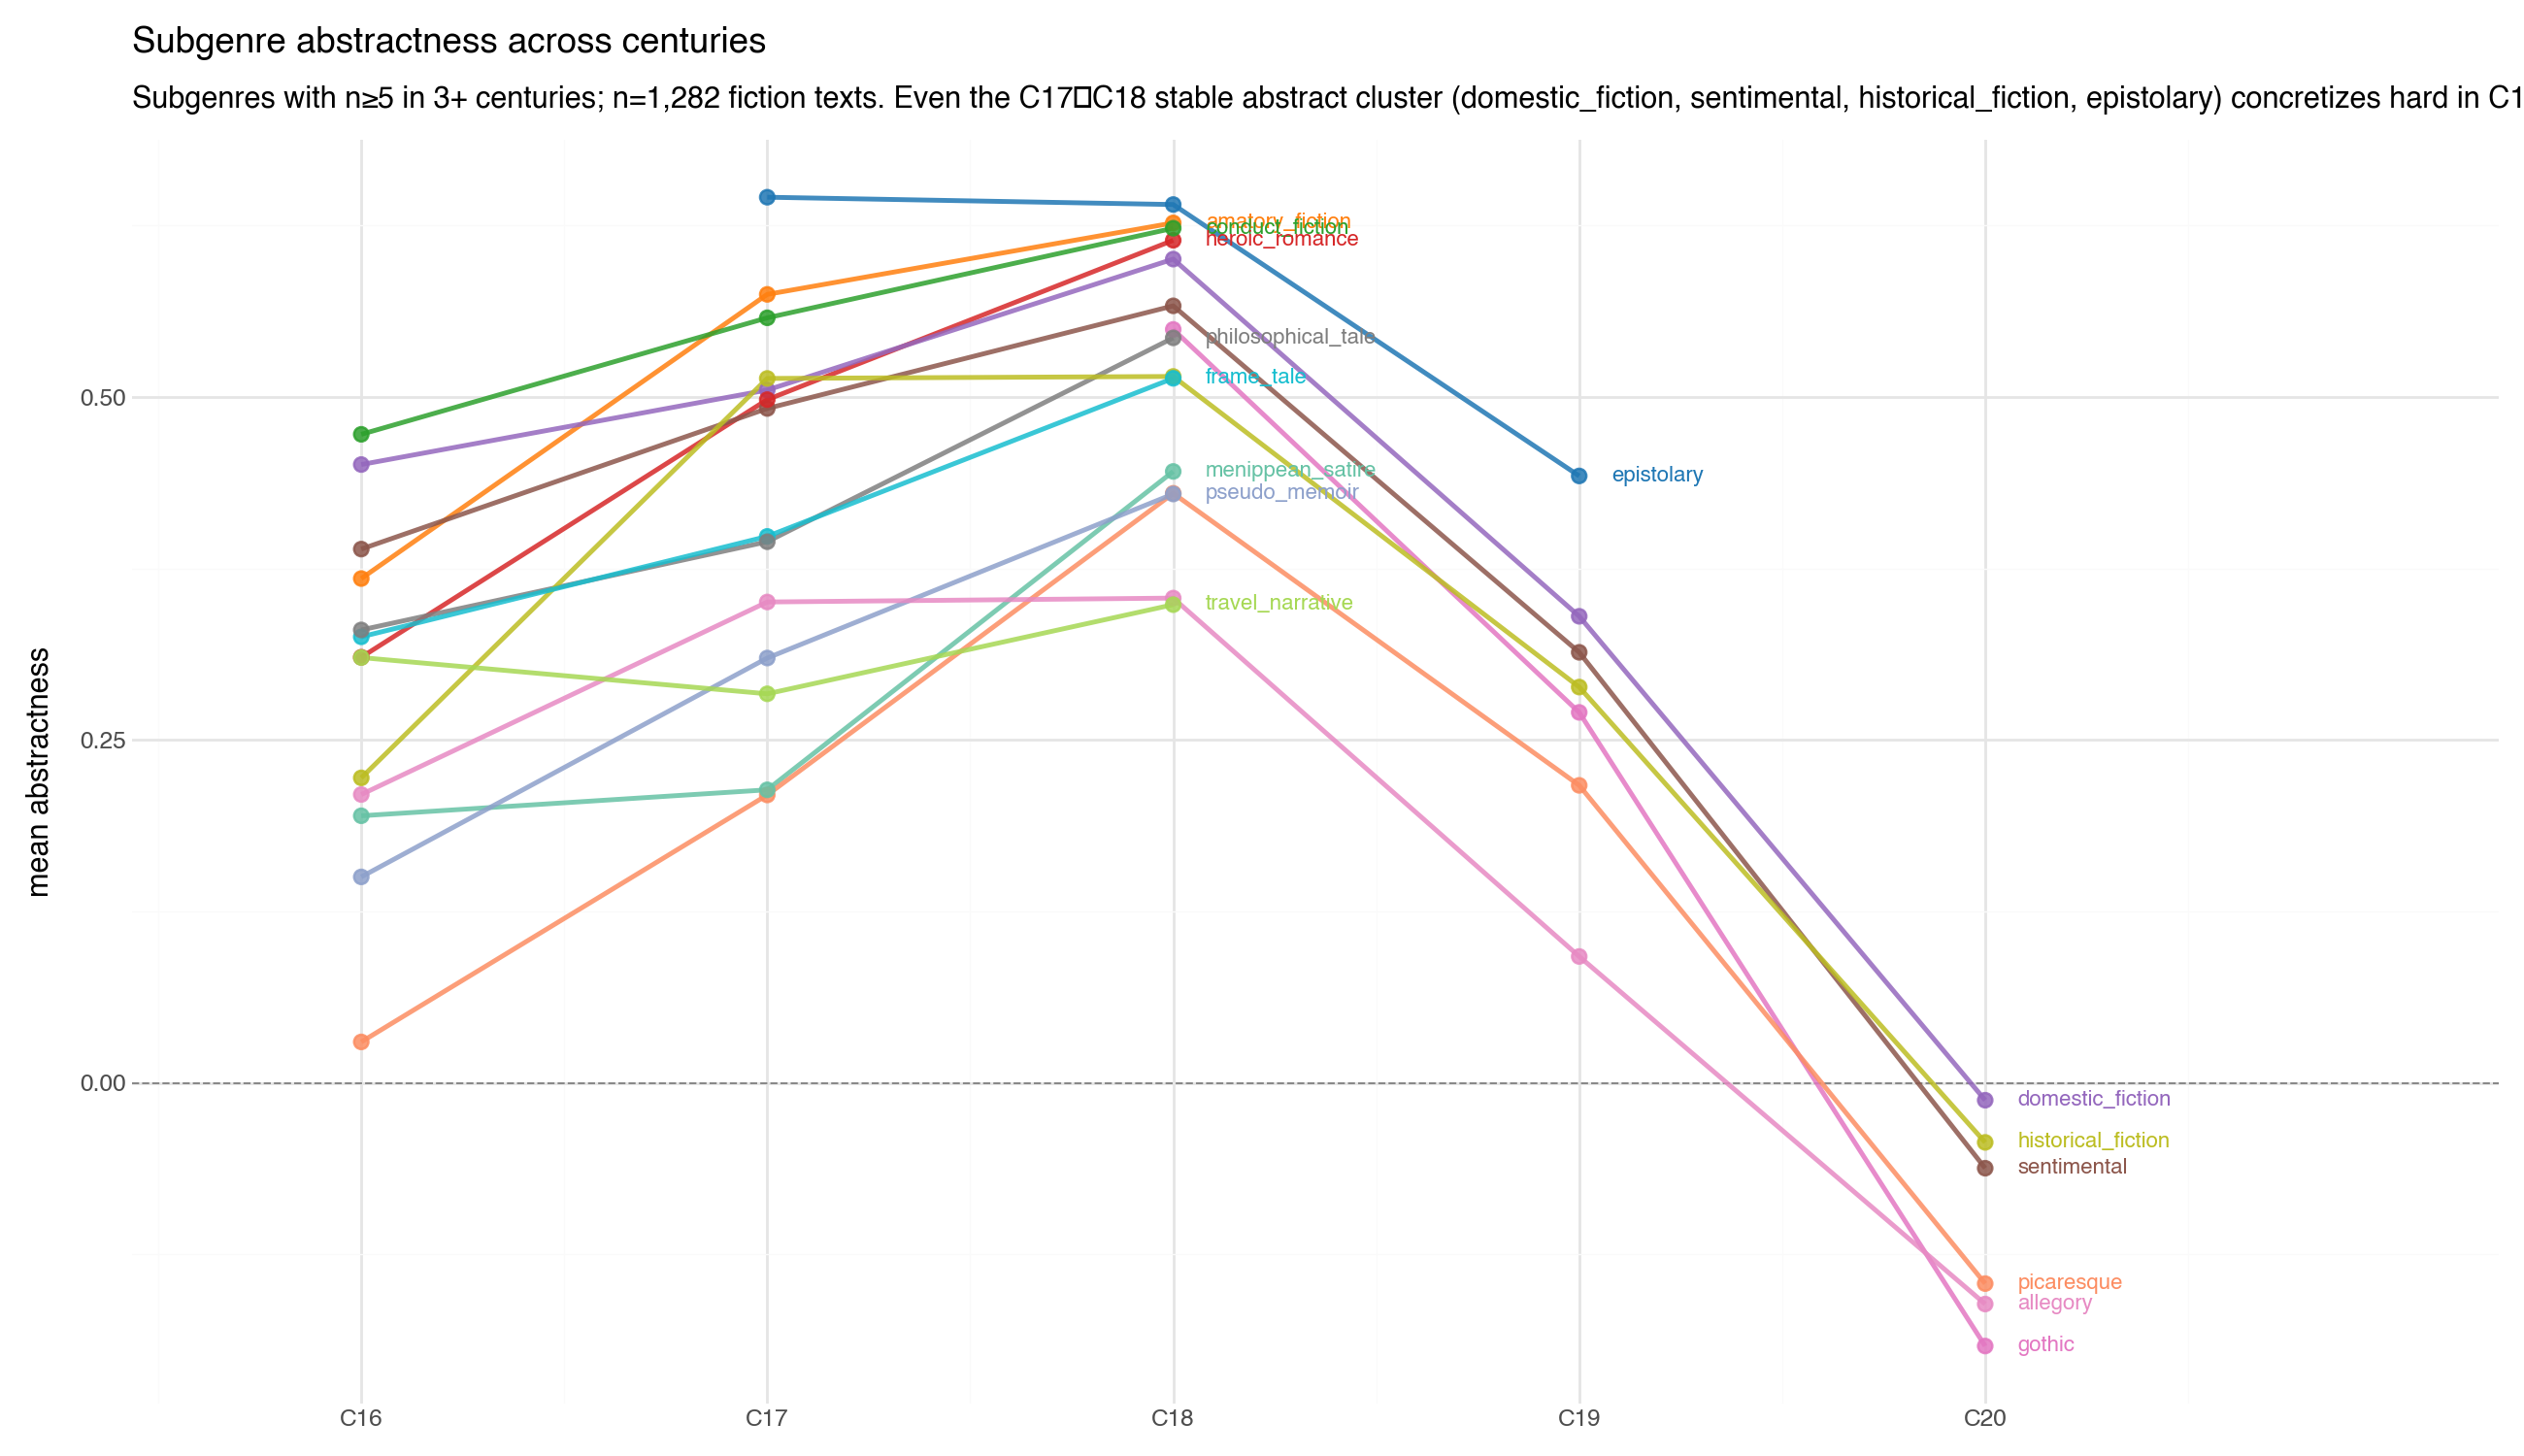

In [27]:
# Multi-century subgenre × century plot (C16-C20).
# Reload subgenre annotations including post-1800.
import clickhouse_connect
rows4 = []
for _id, d in iter_task_results('subgenre'):
    rows4.append({'source': _id, 'is_fiction': d.get('is_fiction'),
                  'subgenres': d.get('subgenres') or []})
sg4 = pd.DataFrame(rows4)
meta4 = lltk.db.fetch_metadata(sg4['source'].tolist(), columns=['year'])
sg4 = sg4.merge(meta4[['_id','year']], left_on='source', right_on='_id', how='left')

ch = clickhouse_connect.get_client(host='localhost', port=8123, username='lltk', password='lltk')
sc4 = ch.query_df(
    'SELECT _id, `Abs-Conc.Median.median` AS raw FROM abstraction.scores_en WHERE _id IN %(ids)s',
    parameters={'ids': sg4['source'].tolist()},
).drop_duplicates('_id')
sc4['abs_score'] = -sc4['raw']
ch.close()
work4 = sg4[(sg4['is_fiction']==True) & sg4['year'].notna()].merge(
    sc4[['_id','abs_score']], left_on='source', right_on='_id', how='inner')
work4 = work4[work4['year'] >= 1500].copy()
work4['century'] = (work4['year']//100*100).astype(int)
print(f'Total fiction texts with subgenre + score, year≥1500: {len(work4):,}')

# Per-cell counts and means
ctr4 = Counter()
for tags in work4['subgenres']:
    for t in tags: ctr4[t] += 1

cells = []
for tag, _ in ctr4.most_common():
    has = work4['subgenres'].apply(lambda L: tag in L)
    for cent in (1500, 1600, 1700, 1800, 1900):
        mask = has & (work4['century']==cent)
        if mask.sum() >= 5:
            cells.append({
                'subgenre': tag, 'century_year': cent + 50,
                'century': f'C{cent//100+1}',
                'n': int(mask.sum()),
                'mean_abs': work4.loc[mask,'abs_score'].mean(),
                'se': work4.loc[mask,'abs_score'].sem(),
            })
ddf = pd.DataFrame(cells)
n_cents_per_sg = ddf.groupby('subgenre')['century_year'].nunique()
multi = n_cents_per_sg[n_cents_per_sg >= 3].index.tolist()
ddf = ddf[ddf['subgenre'].isin(multi)].copy()
ddf['lo'] = ddf['mean_abs'] - 1.96*ddf['se']
ddf['hi'] = ddf['mean_abs'] + 1.96*ddf['se']

# Order by C18 mean (or earliest available) so abstract subgenres on top
anchor = (ddf[ddf['century']=='C18'].groupby('subgenre')['mean_abs'].first()
          .reindex(multi).fillna(
              ddf.groupby('subgenre')['mean_abs'].first()))
sg_order = anchor.sort_values(ascending=False).index.tolist()
ddf['subgenre'] = pd.Categorical(ddf['subgenre'], categories=sg_order, ordered=True)

# Spread for plotting
import matplotlib.colors as mcolors
import matplotlib.cm as mcm
tab10_4 = [mcolors.to_hex(c) for c in mcm.tab10.colors]
set2_4 = [mcolors.to_hex(c) for c in mcm.Set2.colors]
palette4 = dict(zip(sg_order, tab10_4 + set2_4 + ['#666666', '#AAAAAA']))

# Labels at last available century
labels = (ddf.sort_values('century_year').groupby('subgenre', as_index=False).last())

p_arc = (p9.ggplot(ddf, p9.aes(x='century_year', y='mean_abs',
                                group='subgenre', color='subgenre'))
         + p9.geom_hline(yintercept=0, color='#888888', size=0.4, linetype='dashed')
         + p9.geom_line(size=1.0, alpha=0.85)
         + p9.geom_point(size=2.5, alpha=0.85)
         + p9.geom_text(p9.aes(label='subgenre'), data=labels,
                        nudge_x=8, ha='left', size=8, fontweight='bold',
                        show_legend=False)
         + p9.scale_color_manual(values=palette4)
         + p9.scale_x_continuous(breaks=[1550,1650,1750,1850,1950],
                                 labels=['C16','C17','C18','C19','C20'],
                                 limits=(1520, 2050))
         + p9.labs(
             title='Subgenre abstractness across centuries',
             subtitle=f'Subgenres with n≥5 in 3+ centuries; n={len(work4):,} fiction texts. '
                      f'Even the C17→C18 stable abstract cluster (domestic_fiction, sentimental, '
                      f'historical_fiction, epistolary) concretizes hard in C19+C20.',
             x='', y='mean abstractness', color='',
         )
         + p9.theme_minimal()
         + p9.theme(figure_size=(13, 7.5), legend_position='none'))

out = os.path.join(DROPBOX_FIGS, 'subgenre_abstractness_C16_C20.png')
p_arc.save(out, dpi=300, verbose=False)
print(f'\nSaved to {out}')
p_arc